# Notebook 30 — Microstate observability audit under DC–AC excitation

## Goal

Audit whether low-frequency DC–AC excitation produces persistent equal-Q microstate differences beyond prescribed-current geometry.

## Scientific context

Previous PyBaMM DC–AC audits showed that, in prescribed-current CC windows, raw state-equivalent first-passage time differences Δt(Q) are largely explained by current-waveform geometry. The unresolved question is whether low-frequency DC–AC excitation still creates detectable microstate differences at equal net charge, even when Δt_resid(Q) is near zero.

This notebook therefore shifts the analysis from time-to-Q alone to microstate observability.

## Protocol / study design

Parameter sets:

- Chen2020
- Ecker2015
- ORegan2022

Model hierarchy:

- DFN
- SPMe
- SPM

Protocols:

- DC 0.3C
- DC 0.3C + AC 0.7C at 0.1τ
- DC 0.3C + AC 0.7C at 1τ
- DC 0.3C + AC 0.7C at 5τ
- DC 0.3C + AC 0.7C at 10τ
- DC 0.3C + AC 0.7C at f = 0.000412 Hz

Current convention:

- PyBaMM: +I = discharge, −I = charge
- Experiment-faithful charge-first waveform:
  I_py(t) = −I_DC − I_AC · sin(2π f t)

## Workflow

1. Define frequency normalization and protocol table.
2. Audit model and parameter-set availability.
3. Run Chen2020 / DFN smoke simulations.
4. Reconstruct strict-net Q(t) from signed current.
5. Define equal-Q first-passage comparison.
6. Audit available microstate variables.
7. Extend to DFN / SPMe / SPM and three parameter sets.
8. Extract equal-Q microstate differences.
9. Classify whether differences are geometry-only, reversible oscillatory, or persistent microstate shifts.

## Expected outputs

- `data/day30_protocol_frequency_table.csv`
- `data/day30_smoke_summary.csv`
- `data/day30_variable_availability_audit.csv`
- later: `data/day30_microstate_equalQ_long.csv`
- later: `data/day30_microstate_summary.csv`

## Interpretation boundary

This notebook does not prove that DC–AC accelerates lithium intercalation. It audits whether low-frequency DC–AC produces persistent equal-Q microstate differences that cannot be reduced to prescribed-current geometry. A periodic AC oscillation alone is not sufficient evidence for a non-geometric state-layer mechanism.

In [1]:
# Cell 1 — Imports and project paths（导入库与项目路径）

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pybamm

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_TABLE_DIR = REPO / "docs" / "tables"
DOCS_FIG_DIR = REPO / "docs" / "figures"

for p in [DATA_DIR, FIG_DIR, DOCS_TABLE_DIR, DOCS_FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] data dir:", DATA_DIR)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] data dir: /Users/louislu/pybamm-dcac-superimposed/data


In [2]:
# Cell 2 — Frequency table and normalization audit（频率表与归一化审计）

TAU_LABEL_S = 11.1
DC_C = 0.3
AC_C = 0.7

def f_from_tau_factor(tau_factor: float, tau_label_s: float = TAU_LABEL_S) -> float:
    """
    Frequency convention:
    1τ means f = 1 / (2π τ_label).
    0.1τ means f = 1 / (2π · 0.1τ_label).
    10τ means f = 1 / (2π · 10τ_label).
    """
    return 1.0 / (2.0 * np.pi * tau_factor * tau_label_s)

def tau_factor_from_f(f_hz: float, tau_label_s: float = TAU_LABEL_S) -> float:
    tau_equiv = 1.0 / (2.0 * np.pi * f_hz)
    return tau_equiv / tau_label_s

protocol_rows = [
    {
        "condition": "DC03",
        "dc_c": DC_C,
        "ac_c": 0.0,
        "frequency_label": "DC",
        "tau_factor": np.nan,
        "f_Hz": np.nan,
    },
    {
        "condition": "DC03_AC07_0p1tau",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": "0.1tau",
        "tau_factor": 0.1,
        "f_Hz": f_from_tau_factor(0.1),
    },
    {
        "condition": "DC03_AC07_1tau",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": "1tau",
        "tau_factor": 1.0,
        "f_Hz": f_from_tau_factor(1.0),
    },
    {
        "condition": "DC03_AC07_5tau",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": "5tau",
        "tau_factor": 5.0,
        "f_Hz": f_from_tau_factor(5.0),
    },
    {
        "condition": "DC03_AC07_10tau",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": "10tau",
        "tau_factor": 10.0,
        "f_Hz": f_from_tau_factor(10.0),
    },
    {
        "condition": "DC03_AC07_f000412",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": "f=0.000412Hz",
        "tau_factor": tau_factor_from_f(0.000412),
        "f_Hz": 0.000412,
    },
]

protocol_df = pd.DataFrame(protocol_rows)
protocol_df["kappa"] = protocol_df["ac_c"] / protocol_df["dc_c"]
protocol_df.loc[protocol_df["ac_c"] == 0, "kappa"] = 0.0
protocol_df["period_s"] = 1.0 / protocol_df["f_Hz"]
protocol_df.loc[protocol_df["condition"] == "DC03", "period_s"] = np.nan

out = DATA_DIR / "day30_protocol_frequency_table.csv"
protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_protocol_frequency_table.csv


,condition,dc_c,ac_c,frequency_label,tau_factor,f_Hz,kappa,period_s
0,DC03,0.3,0.0,DC,NaN,NaN,0.000000,NaN
1,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,0.143383,2.333333,6.974336
2,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,0.014338,2.333333,69.743357
3,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,0.002868,2.333333,348.716785
4,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,0.001434,2.333333,697.433569
5,DC03_AC07_f000412,0.3,0.7,f=0.000412Hz,34.801658,0.000412,2.333333,2427.184466


## Frequency-mode distinction

This notebook separates two frequency definitions.

1. `fixed_mj1_label`

   Frequencies are inherited from the experimental MJ1 protocol using  
   τ_label = 11.1 s.

   This mode tests whether the experimentally used MJ1 frequencies transfer to PyBaMM parameter sets.

2. `set_tau_ref_rebased`

   Frequencies are recalculated for each PyBaMM parameter set using its own relaxation descriptor τ_ref,set obtained from the Day 17 HPPC-style τ_ref audit.

   This mode tests whether microstate response is governed by normalized time-scale matching rather than by the absolute MJ1 frequency.

These two modes answer different scientific questions and must not be mixed in interpretation.

In [9]:
# Cell 2B — Load Day17 tau_ref audit（读取Day17时间常数审计结果）

tau_audit_path = DATA_DIR / "day17_step1_tau_ref_audit.csv"
tau_matrix_path = DATA_DIR / "day17_step1_tau_ref_descriptor_matrix.csv"

print("[CHECK] tau_audit_path exists:", tau_audit_path.exists(), tau_audit_path)
print("[CHECK] tau_matrix_path exists:", tau_matrix_path.exists(), tau_matrix_path)

tau_audit_df = pd.read_csv(tau_audit_path)
tau_matrix_df = pd.read_csv(tau_matrix_path)

print("\n[day17_step1_tau_ref_audit.csv columns]")
print(tau_audit_df.columns.tolist())
display(tau_audit_df.head(20))

print("\n[day17_step1_tau_ref_descriptor_matrix.csv columns]")
print(tau_matrix_df.columns.tolist())
display(tau_matrix_df.head(20))

[CHECK] tau_audit_path exists: True /Users/louislu/pybamm-dcac-superimposed/data/day17_step1_tau_ref_audit.csv
[CHECK] tau_matrix_path exists: True /Users/louislu/pybamm-dcac-superimposed/data/day17_step1_tau_ref_descriptor_matrix.csv

[day17_step1_tau_ref_audit.csv columns]
['param_set', 'chem_tag', 'Q_nom_Ah', 'V_max_spec', 'V_min_spec', 'I_precharge_A_pybamm', 'I_pulse_A_pybamm', 'deltaI_A', 'descriptor_primary_window_s', 'uinf_window_start_s', 'uinf_window_end_s', 'tail_fit_start_s', 'tail_fit_end_s', 'V_init_charge', 'V_after_precharge', 'V_after_prerest', 'V_pulse_start', 'V_pulse_max', 'V_pulse_end', 'pulse_dV_mV', 'V_relax_end', 'relax_dV_mV', 'pulse_hit_Vmax', 'ton_ms', 'toff_ms', 'C_ms', 'D_target_ms', 'E_ms', 'F_target_ms', 'Uc_V', 'Ud_V', 'Ue_V', 'Uf_V', 'D_target_error_ms', 'F_target_error_ms', 'I0_KL_DAS60_A', 'Ip_KL_DAS60_A', 'R0_CD_Ohm', 'R0_EF_Ohm', 'R0_avg_Ohm', 'Uinf_V', 'Uinf_window_start_V', 'Uinf_window_end_V', 'Uinf_window_dV_mV', 'Uinf_window_abs_dV_mV', 'Uinf_w

,param_set,chem_tag,Q_nom_Ah,V_max_spec,V_min_spec,I_precharge_A_pybamm,I_pulse_A_pybamm,deltaI_A,descriptor_primary_window_s,uinf_window_start_s,...,t95_s,t99_s,recovery_99_reached,G_ms,Ug_V,tau_tail,tail_R2,tail_fit_status,status,wall_time_s
0,Ai2020,Enertech LCO/graphite,2.280000,4.2,3.000,-0.456000,-2.280000,2.280000,600.0,500.0,...,110.98,244.98,True,1755000.0,3.641663,144.550508,0.998253,ok,ok,1.09
1,Chen2020,LG M50 NMC811-Si,5.000000,4.2,2.500,-1.000000,-5.000000,5.000000,600.0,500.0,...,116.98,316.98,True,1827000.0,3.300932,263.021179,0.999965,ok,ok,0.70
2,Ecker2015,Kokam-Ecker Co-rich Mn-free,0.156250,4.2,2.500,-0.031250,-0.156250,0.156250,600.0,500.0,...,48.98,91.98,True,1602000.0,3.455327,164.010514,0.999650,ok,ok,0.90
3,Marquis2019,Kokam-Marquis LCO/graphite,0.680616,4.1,3.105,-0.136123,-0.680616,0.680616,600.0,500.0,...,124.98,301.98,True,1812000.0,3.677603,188.676605,0.999976,ok,ok,1.03
4,Mohtat2020,graphite/NMC532,5.000000,4.2,2.800,-1.000000,-5.000000,5.000000,600.0,500.0,...,89.98,213.98,True,1724000.0,3.521468,97.626758,0.999921,ok,ok,0.96
5,NCA_Kim2011,graphite/NCA,0.430000,4.2,2.700,-0.086000,-0.430000,0.430000,600.0,500.0,...,107.98,205.98,True,1716000.0,3.243458,46.346447,0.998427,ok,ok,0.77
6,OKane2022,LG M50 NMC811-Si,5.000000,4.2,2.500,-1.000000,-5.000000,5.000000,600.0,500.0,...,119.98,354.98,True,1865000.0,3.315011,309.674096,0.999951,ok,ok,0.84
7,ORegan2022,LG M50 NMC811-Si,5.000000,4.4,2.500,-1.000000,-5.000000,5.000000,600.0,500.0,...,142.98,363.98,True,1874000.0,3.272852,236.453708,0.999919,ok,ok,1.05



[day17_step1_tau_ref_descriptor_matrix.csv columns]
['param_set', 'chem_tag', 'tau2_biexp', 'tau2_secondary_60s', 'tau_FG_eff', 't95_s', 't99_s', 'tau_tail']


,param_set,chem_tag,tau2_biexp,tau2_secondary_60s,tau_FG_eff,t95_s,t99_s,tau_tail
0,Ai2020,Enertech LCO/graphite,52.419262,5.099367,9.98,110.98,244.98,144.550508
1,Chen2020,LG M50 NMC811-Si,36.316532,7.720680,15.98,116.98,316.98,263.021179
2,Ecker2015,Kokam-Ecker Co-rich Mn-free,16.517654,13.191344,9.98,48.98,91.98,164.010514
3,Marquis2019,Kokam-Marquis LCO/graphite,43.446697,22.609470,20.98,124.98,301.98,188.676605
4,Mohtat2020,graphite/NMC532,43.932583,13.477271,10.98,89.98,213.98,97.626758
5,NCA_Kim2011,graphite/NCA,39.391957,16.865471,10.98,107.98,205.98,46.346447
6,OKane2022,LG M50 NMC811-Si,58.817756,36.280460,15.98,119.98,354.98,309.674096
7,ORegan2022,LG M50 NMC811-Si,53.575426,19.794923,18.98,142.98,363.98,236.453708


In [10]:
# Cell 2C — Build fixed and set-rebased frequency tables（构建固定MJ1频率与参数集归一化频率表）

# Notebook 30 target parameter sets.
# This is intentionally defined here because frequency rebasing depends on parameter-set identity.
PARAMETER_SETS = ["Chen2020", "Ecker2015", "ORegan2022"]

TAU_REBASE_DESCRIPTOR = "tau2_biexp"

# Use the clean descriptor matrix for rebasing.
tau_source_df = tau_matrix_df.copy()

required_cols = {"param_set", TAU_REBASE_DESCRIPTOR}
missing_cols = required_cols - set(tau_source_df.columns)
if missing_cols:
    raise KeyError(f"Missing required tau columns: {missing_cols}. Available={tau_source_df.columns.tolist()}")

tau_ref_df = (
    tau_source_df[["param_set", "chem_tag", TAU_REBASE_DESCRIPTOR]]
    .rename(columns={
        "param_set": "parameter_set",
        TAU_REBASE_DESCRIPTOR: "tau_ref_set_s",
    })
    .copy()
)

tau_ref_df = tau_ref_df[tau_ref_df["parameter_set"].isin(PARAMETER_SETS)].copy()
tau_ref_df["tau_ref_set_s"] = pd.to_numeric(tau_ref_df["tau_ref_set_s"], errors="coerce")

missing_sets = sorted(set(PARAMETER_SETS) - set(tau_ref_df["parameter_set"]))
if missing_sets:
    raise ValueError(f"Missing tau_ref_set_s for parameter sets: {missing_sets}")

if tau_ref_df["tau_ref_set_s"].isna().any():
    display(tau_ref_df)
    raise ValueError("Some tau_ref_set_s values are NaN")

print("[OK] tau_ref descriptor:", TAU_REBASE_DESCRIPTOR)
display(tau_ref_df)


# -------------------------------------------------------------------------
# A. Fixed-MJ1-label frequency table
# -------------------------------------------------------------------------
fixed_protocol_df = protocol_df.copy()
fixed_protocol_df.insert(0, "frequency_mode", "fixed_mj1_label")
fixed_protocol_df.insert(1, "parameter_set", "MJ1_label")
fixed_protocol_df["tau_ref_set_s"] = TAU_LABEL_S
fixed_protocol_df["base_condition"] = fixed_protocol_df["condition"]

fixed_out = DATA_DIR / "day30_fixed_mj1_protocol_frequency_table.csv"
fixed_protocol_df.to_csv(fixed_out, index=False)
print("[OK] saved fixed-MJ1 frequency table:", fixed_out)
display(fixed_protocol_df)


# -------------------------------------------------------------------------
# B. Set-tau-ref-rebased frequency table
# -------------------------------------------------------------------------
tau_factor_list = [
    ("0p1tau", 0.1),
    ("1tau", 1.0),
    ("5tau", 5.0),
    ("10tau", 10.0),
    ("34p8tau_equiv", tau_factor_from_f(0.000412)),
]

rebased_rows = []

for _, tr in tau_ref_df.iterrows():
    pset = tr["parameter_set"]
    chem_tag = tr["chem_tag"]
    tau_ref_s = float(tr["tau_ref_set_s"])
    
    # DC baseline
    rebased_rows.append({
        "frequency_mode": "set_tau_ref_rebased",
        "parameter_set": pset,
        "chem_tag": chem_tag,
        "condition": f"{pset}_DC03",
        "base_condition": "DC03",
        "dc_c": DC_C,
        "ac_c": 0.0,
        "frequency_label": "DC",
        "tau_factor": np.nan,
        "tau_ref_set_s": tau_ref_s,
        "f_Hz": np.nan,
        "kappa": 0.0,
        "period_s": np.nan,
    })
    
    for label, tau_factor in tau_factor_list:
        f_hz = 1.0 / (2.0 * np.pi * tau_factor * tau_ref_s)
        rebased_rows.append({
            "frequency_mode": "set_tau_ref_rebased",
            "parameter_set": pset,
            "chem_tag": chem_tag,
            "condition": f"{pset}_DC03_AC07_{label}",
            "base_condition": f"DC03_AC07_{label}",
            "dc_c": DC_C,
            "ac_c": AC_C,
            "frequency_label": label,
            "tau_factor": tau_factor,
            "tau_ref_set_s": tau_ref_s,
            "f_Hz": f_hz,
            "kappa": AC_C / DC_C,
            "period_s": 1.0 / f_hz,
        })

rebased_protocol_df = pd.DataFrame(rebased_rows)

rebased_out = DATA_DIR / "day30_set_rebased_protocol_frequency_table.csv"
rebased_protocol_df.to_csv(rebased_out, index=False)
print("[OK] saved set-rebased frequency table:", rebased_out)
display(rebased_protocol_df)


# -------------------------------------------------------------------------
# C. Combined frequency design table for audit traceability
# -------------------------------------------------------------------------
combined_frequency_df = pd.concat(
    [
        fixed_protocol_df.assign(chem_tag="MJ1 experimental label"),
        rebased_protocol_df,
    ],
    ignore_index=True,
    sort=False,
)

combined_out = DATA_DIR / "day30_frequency_design_combined.csv"
combined_frequency_df.to_csv(combined_out, index=False)

print("[OK] saved combined frequency design table:", combined_out)
display(combined_frequency_df)

[OK] tau_ref descriptor: tau2_biexp


,parameter_set,chem_tag,tau_ref_set_s
1,Chen2020,LG M50 NMC811-Si,36.316532
2,Ecker2015,Kokam-Ecker Co-rich Mn-free,16.517654
7,ORegan2022,LG M50 NMC811-Si,53.575426


[OK] saved fixed-MJ1 frequency table: /Users/louislu/pybamm-dcac-superimposed/data/day30_fixed_mj1_protocol_frequency_table.csv


,frequency_mode,parameter_set,condition,dc_c,ac_c,frequency_label,tau_factor,f_Hz,kappa,period_s,tau_ref_set_s,base_condition
0,fixed_mj1_label,MJ1_label,DC03,0.3,0.0,DC,NaN,NaN,0.000000,NaN,11.1,DC03
1,fixed_mj1_label,MJ1_label,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,0.143383,2.333333,6.974336,11.1,DC03_AC07_0p1tau
2,fixed_mj1_label,MJ1_label,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,0.014338,2.333333,69.743357,11.1,DC03_AC07_1tau
3,fixed_mj1_label,MJ1_label,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,0.002868,2.333333,348.716785,11.1,DC03_AC07_5tau
4,fixed_mj1_label,MJ1_label,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,0.001434,2.333333,697.433569,11.1,DC03_AC07_10tau
5,fixed_mj1_label,MJ1_label,DC03_AC07_f000412,0.3,0.7,f=0.000412Hz,34.801658,0.000412,2.333333,2427.184466,11.1,DC03_AC07_f000412


[OK] saved set-rebased frequency table: /Users/louislu/pybamm-dcac-superimposed/data/day30_set_rebased_protocol_frequency_table.csv


,frequency_mode,parameter_set,chem_tag,condition,base_condition,dc_c,ac_c,frequency_label,tau_factor,tau_ref_set_s,f_Hz,kappa,period_s
0,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03,DC03,0.3,0.0,DC,NaN,36.316532,NaN,0.000000,NaN
1,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0p1tau,0.100000,36.316532,0.043824,2.333333,22.818350
2,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,36.316532,0.004382,2.333333,228.183502
3,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,36.316532,0.000876,2.333333,1140.917509
4,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_10tau,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,36.316532,0.000438,2.333333,2281.835017
5,set_tau_ref_rebased,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_34p8tau_equiv,DC03_AC07_34p8tau_equiv,0.3,0.7,34p8tau_equiv,34.801658,36.316532,0.000126,2.333333,7941.164225
6,set_tau_ref_rebased,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03,DC03,0.3,0.0,DC,NaN,16.517654,NaN,0.000000,NaN
7,set_tau_ref_rebased,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0p1tau,0.100000,16.517654,0.096354,2.333333,10.378348
8,set_tau_ref_rebased,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,16.517654,0.009635,2.333333,103.783483
9,set_tau_ref_rebased,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,16.517654,0.001927,2.333333,518.917416


[OK] saved combined frequency design table: /Users/louislu/pybamm-dcac-superimposed/data/day30_frequency_design_combined.csv


,frequency_mode,parameter_set,condition,dc_c,ac_c,frequency_label,tau_factor,f_Hz,kappa,period_s,tau_ref_set_s,base_condition,chem_tag
0,fixed_mj1_label,MJ1_label,DC03,0.3,0.0,DC,NaN,NaN,0.000000,NaN,11.100000,DC03,MJ1 experimental label
1,fixed_mj1_label,MJ1_label,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,0.143383,2.333333,6.974336,11.100000,DC03_AC07_0p1tau,MJ1 experimental label
2,fixed_mj1_label,MJ1_label,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,0.014338,2.333333,69.743357,11.100000,DC03_AC07_1tau,MJ1 experimental label
3,fixed_mj1_label,MJ1_label,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,0.002868,2.333333,348.716785,11.100000,DC03_AC07_5tau,MJ1 experimental label
4,fixed_mj1_label,MJ1_label,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,0.001434,2.333333,697.433569,11.100000,DC03_AC07_10tau,MJ1 experimental label
5,fixed_mj1_label,MJ1_label,DC03_AC07_f000412,0.3,0.7,f=0.000412Hz,34.801658,0.000412,2.333333,2427.184466,11.100000,DC03_AC07_f000412,MJ1 experimental label
6,set_tau_ref_rebased,Chen2020,Chen2020_DC03,0.3,0.0,DC,NaN,NaN,0.000000,NaN,36.316532,DC03,LG M50 NMC811-Si
7,set_tau_ref_rebased,Chen2020,Chen2020_DC03_AC07_0p1tau,0.3,0.7,0p1tau,0.100000,0.043824,2.333333,22.818350,36.316532,DC03_AC07_0p1tau,LG M50 NMC811-Si
8,set_tau_ref_rebased,Chen2020,Chen2020_DC03_AC07_1tau,0.3,0.7,1tau,1.000000,0.004382,2.333333,228.183502,36.316532,DC03_AC07_1tau,LG M50 NMC811-Si
9,set_tau_ref_rebased,Chen2020,Chen2020_DC03_AC07_5tau,0.3,0.7,5tau,5.000000,0.000876,2.333333,1140.917509,36.316532,DC03_AC07_5tau,LG M50 NMC811-Si


In [11]:
# Cell 2D — Expand fixed-MJ1 frequency table to target parameter sets（将固定MJ1频率扩展到目标参数集）

fixed_expanded_rows = []

for _, tr in tau_ref_df.iterrows():
    pset = tr["parameter_set"]
    chem_tag = tr["chem_tag"]
    tau_ref_set_s = float(tr["tau_ref_set_s"])
    
    for _, pr in protocol_df.iterrows():
        fixed_expanded_rows.append({
            "frequency_mode": "fixed_mj1_label",
            "parameter_set": pset,
            "chem_tag": chem_tag,
            "condition": f"{pset}_{pr['condition']}",
            "base_condition": pr["condition"],
            "dc_c": float(pr["dc_c"]),
            "ac_c": float(pr["ac_c"]),
            "frequency_label": pr["frequency_label"],
            "tau_factor_mj1_label": pr["tau_factor"],
            "tau_ref_label_s": TAU_LABEL_S,
            "tau_ref_set_s": tau_ref_set_s,
            "f_Hz": pr["f_Hz"],
            "kappa": pr["kappa"],
            "period_s": pr["period_s"],
            # This tells us what the fixed MJ1 frequency means relative to each parameter set.
            "effective_tau_factor_set": (
                tau_factor_from_f(float(pr["f_Hz"]), tau_ref_set_s)
                if pd.notna(pr["f_Hz"])
                else np.nan
            ),
        })

fixed_expanded_protocol_df = pd.DataFrame(fixed_expanded_rows)

out = DATA_DIR / "day30_fixed_mj1_protocol_frequency_table_expanded.csv"
fixed_expanded_protocol_df.to_csv(out, index=False)

print("[OK] saved expanded fixed-MJ1 frequency table:", out)
display(fixed_expanded_protocol_df)


# Rebuild combined executable frequency design table
# Use:
# - fixed_expanded_protocol_df for fixed-MJ1 protocol-transfer simulations
# - rebased_protocol_df for set-normalized simulations
combined_executable_frequency_df = pd.concat(
    [
        fixed_expanded_protocol_df,
        rebased_protocol_df.assign(
            tau_factor_mj1_label=np.nan,
            tau_ref_label_s=np.nan,
            effective_tau_factor_set=rebased_protocol_df["tau_factor"],
        ),
    ],
    ignore_index=True,
    sort=False,
)

out = DATA_DIR / "day30_frequency_design_executable_combined.csv"
combined_executable_frequency_df.to_csv(out, index=False)

print("[OK] saved executable combined frequency design table:", out)
display(combined_executable_frequency_df)

[OK] saved expanded fixed-MJ1 frequency table: /Users/louislu/pybamm-dcac-superimposed/data/day30_fixed_mj1_protocol_frequency_table_expanded.csv


,frequency_mode,parameter_set,chem_tag,condition,base_condition,dc_c,ac_c,frequency_label,tau_factor_mj1_label,tau_ref_label_s,tau_ref_set_s,f_Hz,kappa,period_s,effective_tau_factor_set
0,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03,DC03,0.3,0.0,DC,NaN,11.1,36.316532,NaN,0.000000,NaN,NaN
1,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,11.1,36.316532,0.143383,2.333333,6.974336,0.030565
2,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,11.1,36.316532,0.014338,2.333333,69.743357,0.305646
3,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,11.1,36.316532,0.002868,2.333333,348.716785,1.528230
4,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_10tau,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,11.1,36.316532,0.001434,2.333333,697.433569,3.056459
5,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_f000412,DC03_AC07_f000412,0.3,0.7,f=0.000412Hz,34.801658,11.1,36.316532,0.000412,2.333333,2427.184466,10.636985
6,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03,DC03,0.3,0.0,DC,NaN,11.1,16.517654,NaN,0.000000,NaN,NaN
7,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,11.1,16.517654,0.143383,2.333333,6.974336,0.067201
8,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,11.1,16.517654,0.014338,2.333333,69.743357,0.672008
9,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,11.1,16.517654,0.002868,2.333333,348.716785,3.360041


[OK] saved executable combined frequency design table: /Users/louislu/pybamm-dcac-superimposed/data/day30_frequency_design_executable_combined.csv


,frequency_mode,parameter_set,chem_tag,condition,base_condition,dc_c,ac_c,frequency_label,tau_factor_mj1_label,tau_ref_label_s,tau_ref_set_s,f_Hz,kappa,period_s,effective_tau_factor_set,tau_factor
0,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03,DC03,0.3,0.0,DC,NaN,11.1,36.316532,NaN,0.000000,NaN,NaN,NaN
1,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,11.1,36.316532,0.143383,2.333333,6.974336,0.030565,NaN
2,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,11.1,36.316532,0.014338,2.333333,69.743357,0.305646,NaN
3,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,11.1,36.316532,0.002868,2.333333,348.716785,1.528230,NaN
4,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_10tau,DC03_AC07_10tau,0.3,0.7,10tau,10.000000,11.1,36.316532,0.001434,2.333333,697.433569,3.056459,NaN
5,fixed_mj1_label,Chen2020,LG M50 NMC811-Si,Chen2020_DC03_AC07_f000412,DC03_AC07_f000412,0.3,0.7,f=0.000412Hz,34.801658,11.1,36.316532,0.000412,2.333333,2427.184466,10.636985,NaN
6,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03,DC03,0.3,0.0,DC,NaN,11.1,16.517654,NaN,0.000000,NaN,NaN,NaN
7,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_0p1tau,DC03_AC07_0p1tau,0.3,0.7,0.1tau,0.100000,11.1,16.517654,0.143383,2.333333,6.974336,0.067201,NaN
8,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_1tau,DC03_AC07_1tau,0.3,0.7,1tau,1.000000,11.1,16.517654,0.014338,2.333333,69.743357,0.672008,NaN
9,fixed_mj1_label,Ecker2015,Kokam-Ecker Co-rich Mn-free,Ecker2015_DC03_AC07_5tau,DC03_AC07_5tau,0.3,0.7,5tau,5.000000,11.1,16.517654,0.002868,2.333333,348.716785,3.360041,NaN


## Frequency-design interpretation after expansion

The fixed-MJ1 frequency mode is now expanded to each target PyBaMM parameter set.  
This exposes the effective normalized frequency of the experimental MJ1 labels when applied to each model.

For example, the MJ1-label 10τ protocol corresponds to approximately:

- 3.06τ_set in Chen2020
- 6.72τ_set in Ecker2015
- 2.07τ_set in ORegan2022

Therefore, fixed experimental-frequency transfer and set-normalized time-scale matching are not equivalent.  
The subsequent microstate audit must report both frequency modes separately.

The 34.8τ-equivalent branch is retained as a very-low-frequency boundary case. Because its period can be comparable to the CC event time, it is potentially sensitive to initial phase and incomplete-cycle boundary effects.

In [3]:
# Cell 3 — Parameter-set and model availability audit（参数集与模型可运行性审计）

PARAMETER_SETS = ["Chen2020", "Ecker2015", "ORegan2022"]

MODEL_BUILDERS = {
    "DFN": lambda: pybamm.lithium_ion.DFN({"thermal": "isothermal"}),
    "SPMe": lambda: pybamm.lithium_ion.SPMe({"thermal": "isothermal"}),
    "SPM": lambda: pybamm.lithium_ion.SPM({"thermal": "isothermal"}),
}

availability_rows = []

for pset in PARAMETER_SETS:
    try:
        pv = pybamm.ParameterValues(pset)
        q_ah = float(pv["Nominal cell capacity [A.h]"])
        pset_status = "ok"
        pset_error = ""
    except Exception as e:
        pv = None
        q_ah = np.nan
        pset_status = "failed"
        pset_error = repr(e)
    
    for model_name in MODEL_BUILDERS:
        try:
            model = MODEL_BUILDERS[model_name]()
            status = "ok"
            error = ""
        except Exception as e:
            status = "failed"
            error = repr(e)
        
        availability_rows.append({
            "parameter_set": pset,
            "model_type": model_name,
            "parameter_status": pset_status,
            "model_status": status,
            "nominal_capacity_Ah": q_ah,
            "parameter_error": pset_error,
            "model_error": error,
        })

availability_df = pd.DataFrame(availability_rows)
out = DATA_DIR / "day30_model_parameter_availability_audit.csv"
availability_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(availability_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_model_parameter_availability_audit.csv


,parameter_set,model_type,parameter_status,model_status,nominal_capacity_Ah,parameter_error,model_error
0,Chen2020,DFN,ok,ok,5.00000,,
1,Chen2020,SPMe,ok,ok,5.00000,,
2,Chen2020,SPM,ok,ok,5.00000,,
3,Ecker2015,DFN,ok,ok,0.15625,,
4,Ecker2015,SPMe,ok,ok,0.15625,,
5,Ecker2015,SPM,ok,ok,0.15625,,
6,ORegan2022,DFN,ok,ok,5.00000,,
7,ORegan2022,SPMe,ok,ok,5.00000,,
8,ORegan2022,SPM,ok,ok,5.00000,,


In [4]:
# Cell 4 — Protocol builder with charge-first convention（实验一致相位协议构建）

def make_model(model_type: str):
    if model_type not in MODEL_BUILDERS:
        raise ValueError(f"Unknown model_type: {model_type}")
    return MODEL_BUILDERS[model_type]()

def make_parameter_values_with_current(
    parameter_set: str,
    dc_c: float,
    ac_c: float,
    f_hz: float | None,
):
    """
    PyBaMM convention:
    +I = discharge
    -I = charge

    Experiment-faithful charge-first DC–AC waveform:
    I_exp(t) = I_DC + I_AC sin(2π f t), charging-positive.

    Therefore:
    I_py(t) = -I_exp(t)
            = -I_DC - I_AC sin(2π f t).
    """
    pv = pybamm.ParameterValues(parameter_set)
    q_ah = float(pv["Nominal cell capacity [A.h]"])
    i_dc_abs = dc_c * q_ah
    i_ac_abs = ac_c * q_ah

    if ac_c == 0 or f_hz is None or (isinstance(f_hz, float) and np.isnan(f_hz)):
        def current_fun(t):
            return -i_dc_abs + 0 * t
    else:
        def current_fun(t):
            return -i_dc_abs - i_ac_abs * pybamm.sin(2 * np.pi * f_hz * t)

    pv.update({"Current function [A]": current_fun}, check_already_exists=False)
    
    meta = {
        "parameter_set": parameter_set,
        "nominal_capacity_Ah": q_ah,
        "dc_c": dc_c,
        "ac_c": ac_c,
        "i_dc_A": i_dc_abs,
        "i_ac_A": i_ac_abs,
        "f_Hz": f_hz,
        "phase_convention": "charge_first",
        "pybamm_current": "I_py = -I_DC - I_AC*sin(2*pi*f*t)",
    }
    return pv, meta

def run_simulation(
    parameter_set: str,
    model_type: str,
    protocol_row: dict,
    initial_soc: float = 0.05,
    max_time_s: float = 24000.0,
    n_eval: int = 5000,
):
    model = make_model(model_type)
    pv, current_meta = make_parameter_values_with_current(
        parameter_set=parameter_set,
        dc_c=float(protocol_row["dc_c"]),
        ac_c=float(protocol_row["ac_c"]),
        f_hz=None if pd.isna(protocol_row["f_Hz"]) else float(protocol_row["f_Hz"]),
    )
    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    
    return sim, sol, current_meta

print("[OK] protocol builder ready")

[OK] protocol builder ready


In [5]:
# Cell 5 — Strict-net Q and first-passage utilities（strict-net Q 与 first-passage 工具函数）

def cumulative_trapezoid_np(y, x):
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    if len(y) != len(x):
        raise ValueError("x and y length mismatch")
    if len(y) < 2:
        return np.zeros_like(y)
    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx
    return np.concatenate([[0.0], np.cumsum(area)])

def extract_solution_timeseries(sol):
    t = np.asarray(sol.t, dtype=float)
    I_py = np.asarray(sol["Current [A]"](t), dtype=float).reshape(-1)
    V = np.asarray(sol["Terminal voltage [V]"](t), dtype=float).reshape(-1)
    
    # Charge-positive strict-net current.
    # If AC trough becomes discharge-like, I_charge becomes negative and contributes negatively.
    I_charge = -I_py
    Q_Ah = cumulative_trapezoid_np(I_charge, t) / 3600.0
    
    return pd.DataFrame({
        "t_s": t,
        "I_py_A": I_py,
        "I_charge_A": I_charge,
        "V_terminal_V": V,
        "Q_net_Ah": Q_Ah,
    })

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)
    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan
    
    i = int(hit[0])
    if i == 0:
        return float(t_s[0])
    
    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]
    
    if q1 == q0:
        return float(t1)
    
    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))

def first_passage_value(t_s, y, target_t_s):
    t_s = np.asarray(t_s, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.isnan(target_t_s):
        return np.nan
    if target_t_s <= t_s[0]:
        return float(y[0])
    if target_t_s >= t_s[-1]:
        return float(y[-1])
    return float(np.interp(target_t_s, t_s, y))

print("[OK] strict-net Q utilities ready")

[OK] strict-net Q utilities ready


In [6]:
# Cell 6 — Chen2020 DFN smoke simulations（Chen2020 DFN 冒烟测试）

SMOKE_PARAMETER_SET = "Chen2020"
SMOKE_MODEL_TYPE = "DFN"
SMOKE_CONDITIONS = ["DC03", "DC03_AC07_0p1tau", "DC03_AC07_10tau", "DC03_AC07_f000412"]

smoke_solutions = {}
smoke_rows = []

for cond in SMOKE_CONDITIONS:
    row = protocol_df.loc[protocol_df["condition"] == cond].iloc[0].to_dict()
    print(f"\n[RUN] {SMOKE_PARAMETER_SET} / {SMOKE_MODEL_TYPE} / {cond}")
    
    try:
        sim, sol, meta = run_simulation(
            parameter_set=SMOKE_PARAMETER_SET,
            model_type=SMOKE_MODEL_TYPE,
            protocol_row=row,
            initial_soc=0.05,
            max_time_s=24000,
            n_eval=5000,
        )
        ts = extract_solution_timeseries(sol)
        smoke_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "meta": meta,
            "ts": ts,
        }
        
        smoke_rows.append({
            "parameter_set": SMOKE_PARAMETER_SET,
            "model_type": SMOKE_MODEL_TYPE,
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
        
    except Exception as e:
        smoke_rows.append({
            "parameter_set": SMOKE_PARAMETER_SET,
            "model_type": SMOKE_MODEL_TYPE,
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

smoke_df = pd.DataFrame(smoke_rows)
out = DATA_DIR / "day30_smoke_summary.csv"
smoke_df.to_csv(out, index=False)

print("\n[OK] saved:", out)
display(smoke_df)


[RUN] Chen2020 / DFN / DC03
[OK] DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / DC03_AC07_0p1tau
[OK] DC03_AC07_0p1tau | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / DC03_AC07_10tau
[OK] DC03_AC07_10tau | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / DC03_AC07_f000412
[OK] DC03_AC07_f000412 | termination: event: Maximum voltage [V]

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_smoke_summary.csv


,parameter_set,model_type,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,Chen2020,DFN,DC03,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.5,1.500000,
1,Chen2020,DFN,DC03_AC07_0p1tau,ok,event: Maximum voltage [V],9152.088201,152.534803,3.808143,4.2,-2.0,5.000000,
2,Chen2020,DFN,DC03_AC07_10tau,ok,event: Maximum voltage [V],8498.625306,141.643755,3.606503,4.2,-2.0,4.999999,
3,Chen2020,DFN,DC03_AC07_f000412,ok,event: Maximum voltage [V],7738.438578,128.973976,3.457801,4.2,-2.0,5.000000,


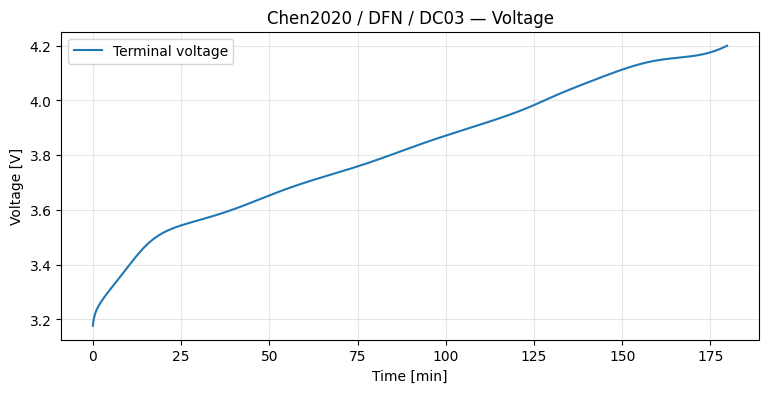

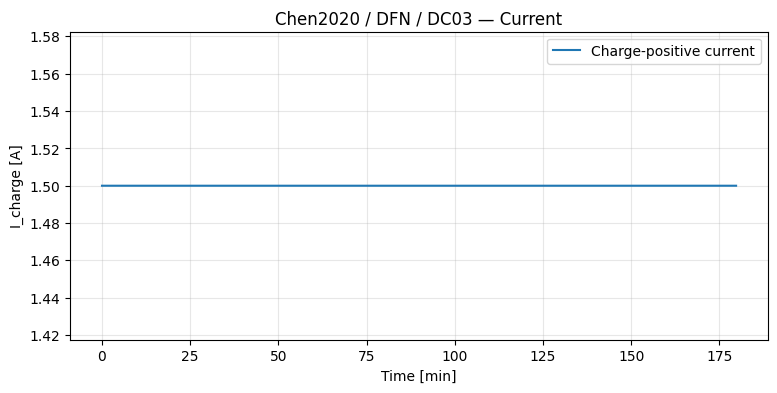

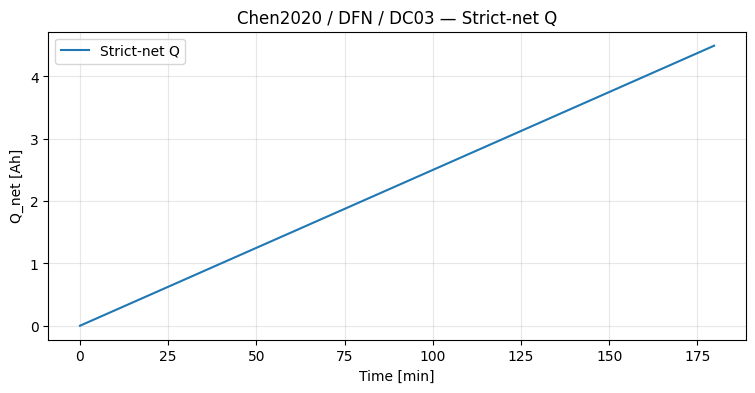

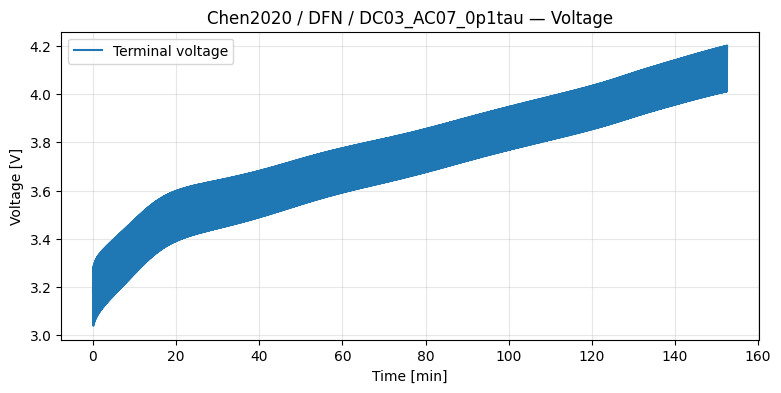

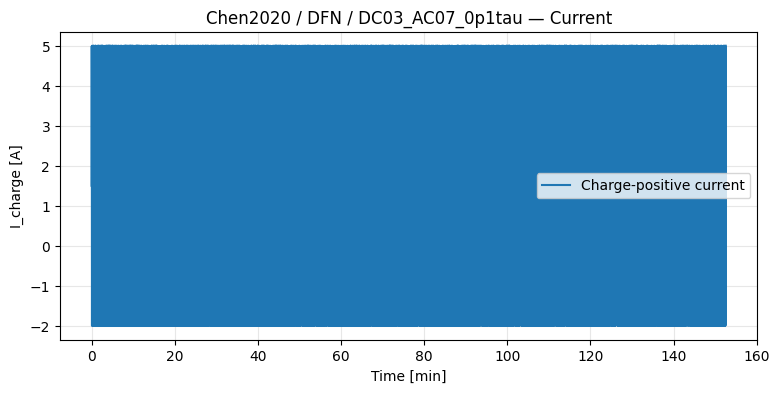

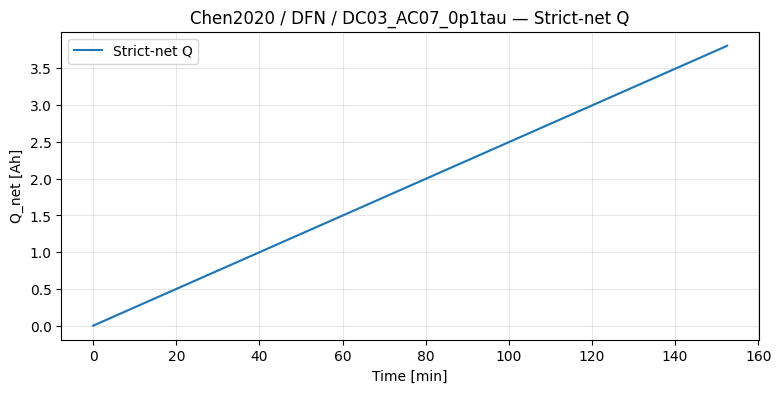

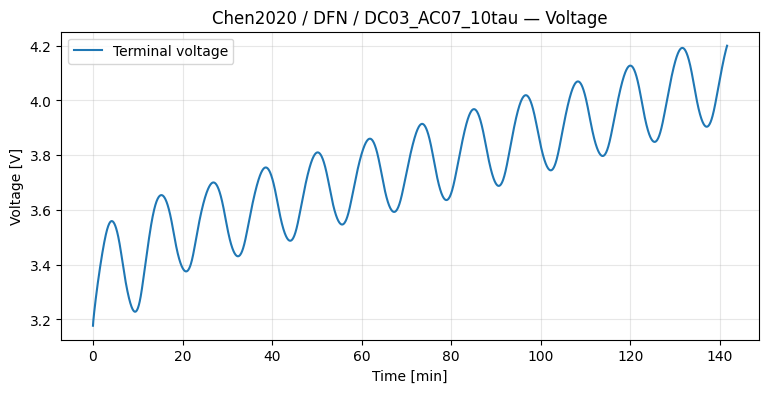

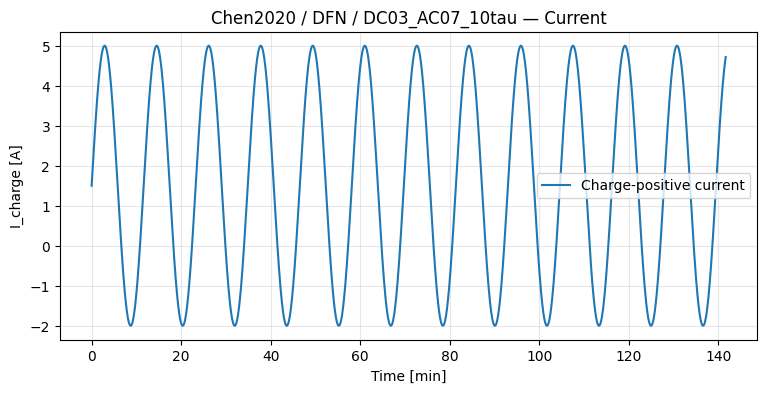

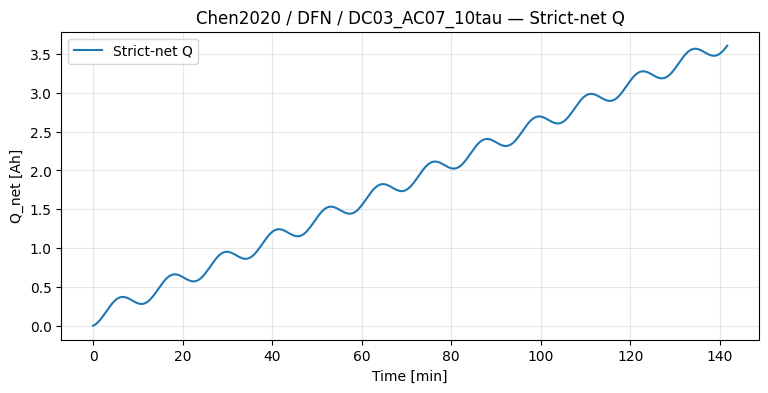

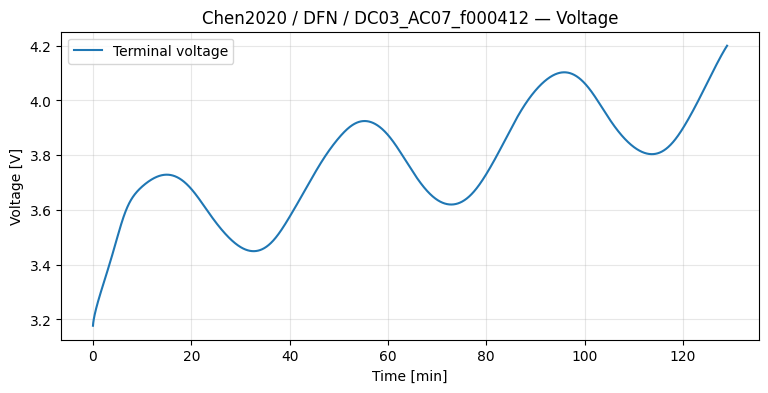

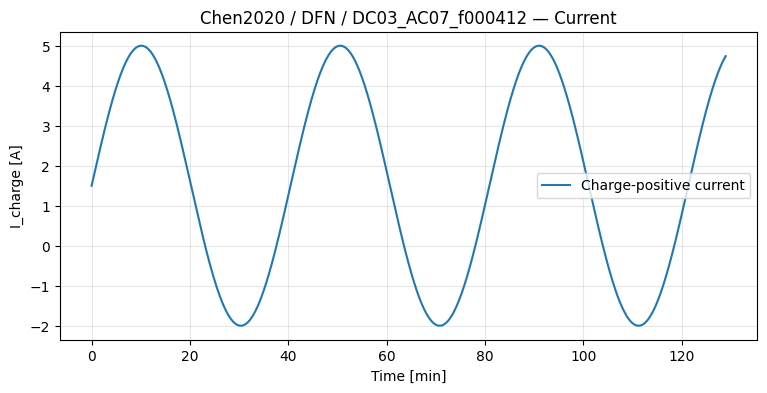

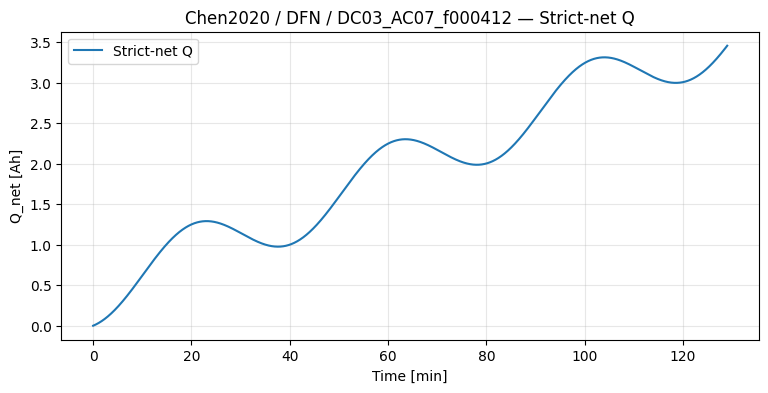

In [7]:
# Cell 7 — Smoke plots for voltage, current, and strict-net Q（冒烟测试曲线：电压、电流与strict-net Q）

for cond, obj in smoke_solutions.items():
    ts = obj["ts"]
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["t_s"] / 60, ts["V_terminal_V"], label="Terminal voltage")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Voltage [V]")
    ax.set_title(f"{SMOKE_PARAMETER_SET} / {SMOKE_MODEL_TYPE} / {cond} — Voltage")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["t_s"] / 60, ts["I_charge_A"], label="Charge-positive current")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("I_charge [A]")
    ax.set_title(f"{SMOKE_PARAMETER_SET} / {SMOKE_MODEL_TYPE} / {cond} — Current")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ts["t_s"] / 60, ts["Q_net_Ah"], label="Strict-net Q")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Q_net [Ah]")
    ax.set_title(f"{SMOKE_PARAMETER_SET} / {SMOKE_MODEL_TYPE} / {cond} — Strict-net Q")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


[ZOOM AUDIT] DC03_AC07_0p1tau
t_end = 9152.09 s
I_charge min/max = -2.000000 / 5.000000 A
Q_net end = 3.808143 Ah
Q_ac_component min/max = -0.006319079 / 0.002153638 Ah
Q_ac_component peak-to-peak = 0.008472718 Ah


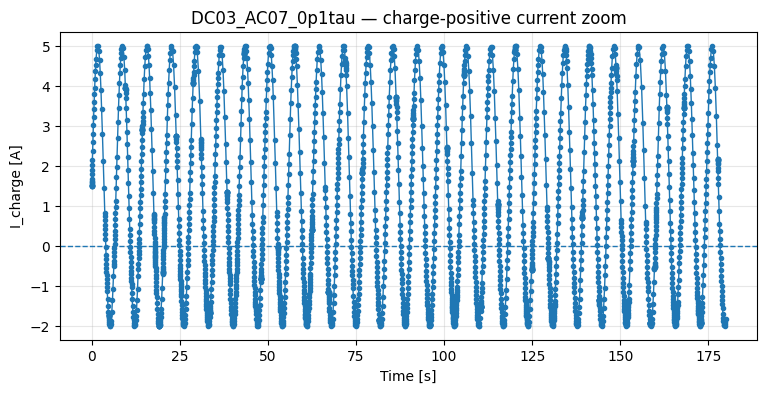

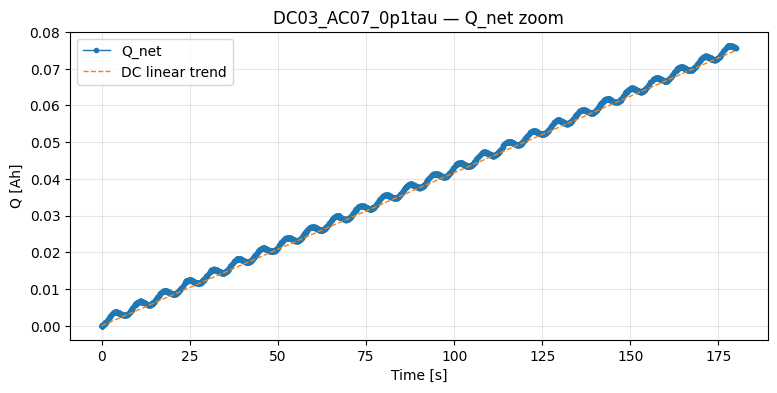

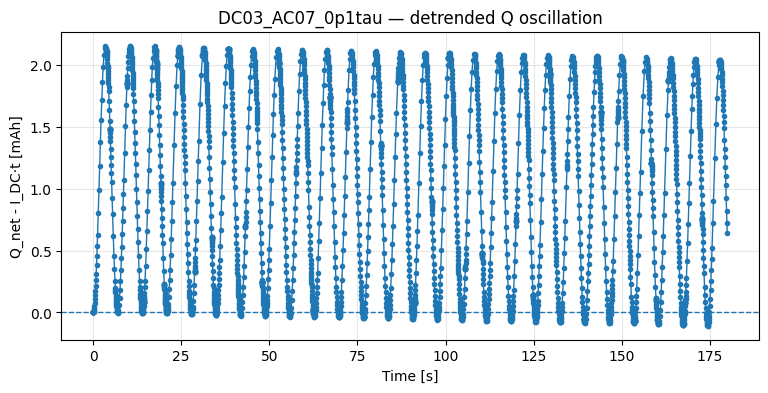


[ZOOM AUDIT] DC03_AC07_10tau
t_end = 8498.63 s
I_charge min/max = -2.000000 / 4.999999 A
Q_net end = 3.606503 Ah
Q_ac_component min/max = -0.000001907 / 0.215829102 Ah
Q_ac_component peak-to-peak = 0.215831009 Ah


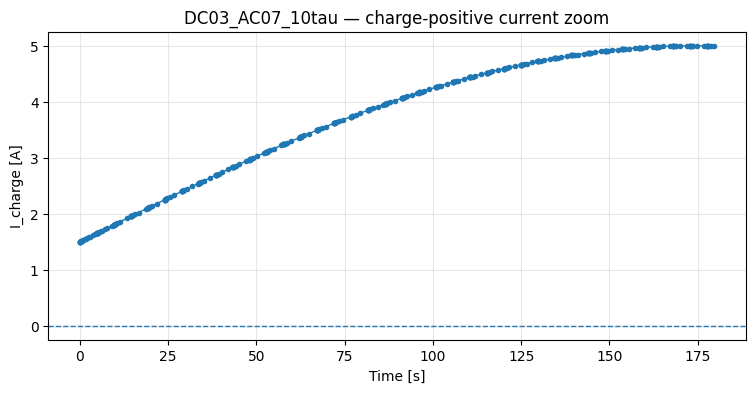

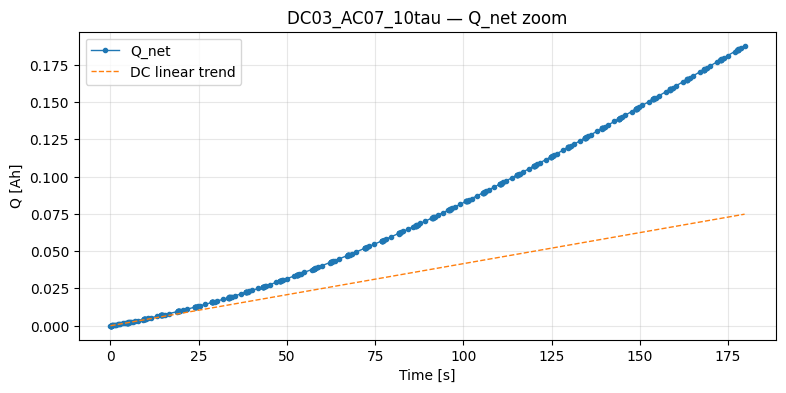

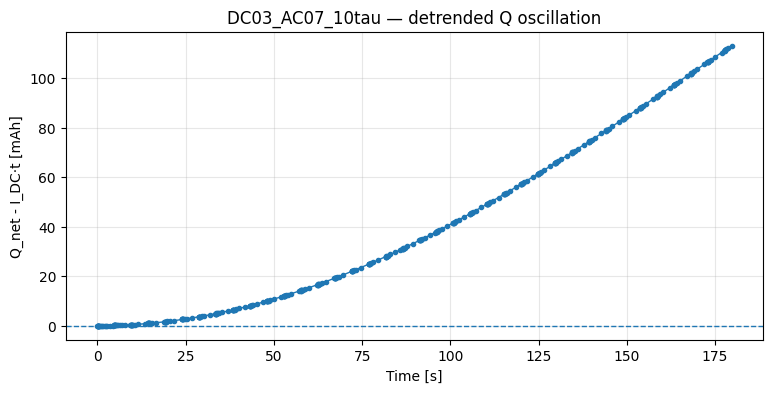


[ZOOM AUDIT] DC03_AC07_f000412
t_end = 7738.44 s
I_charge min/max = -2.000000 / 5.000000 A
Q_net end = 3.457801 Ah
Q_ac_component min/max = -0.000000200 / 0.751134753 Ah
Q_ac_component peak-to-peak = 0.751134952 Ah


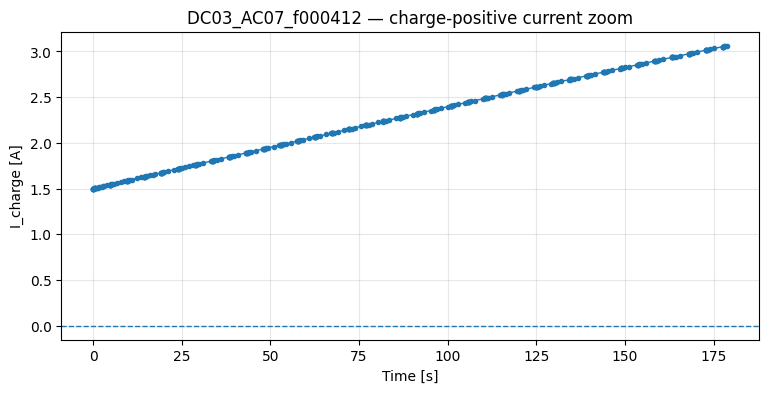

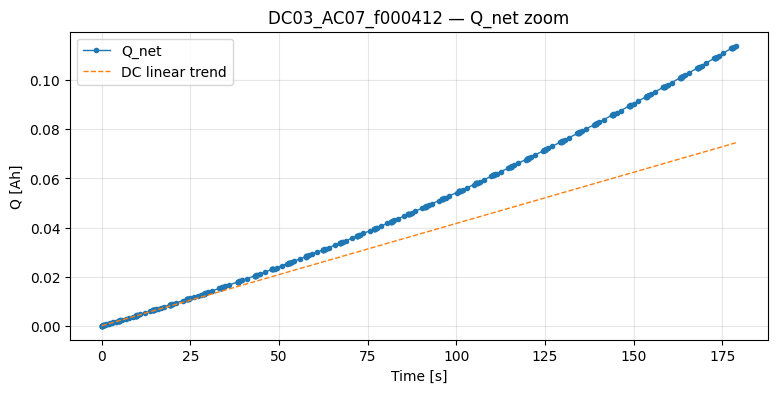

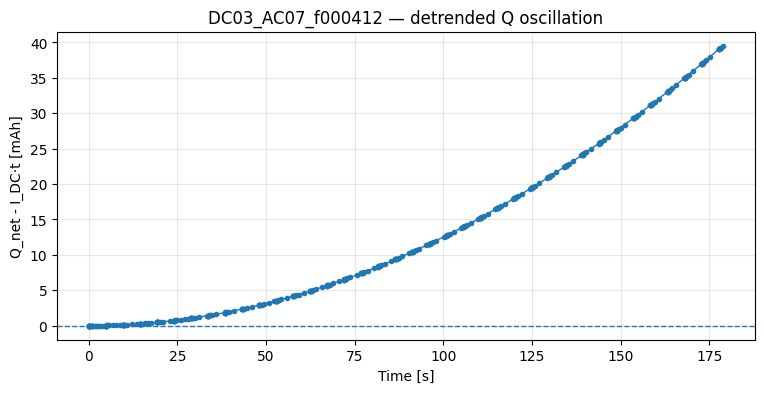

In [8]:
# Cell 7B — Zoom and detrended-Q audit for high-frequency current（高频电流局部放大与去趋势Q审计）

def plot_zoom_and_detrended_Q(cond, t_zoom_s=120):
    obj = smoke_solutions[cond]
    ts = obj["ts"].copy()
    meta = obj["meta"]
    
    dc_current_A = meta["i_dc_A"]
    
    # Detrend strict-net Q by removing the DC-only linear component
    ts["Q_dc_linear_Ah"] = dc_current_A * ts["t_s"] / 3600.0
    ts["Q_ac_component_Ah"] = ts["Q_net_Ah"] - ts["Q_dc_linear_Ah"]
    
    zoom = ts[ts["t_s"] <= t_zoom_s].copy()
    
    print(f"\n[ZOOM AUDIT] {cond}")
    print(f"t_end = {ts['t_s'].iloc[-1]:.2f} s")
    print(f"I_charge min/max = {ts['I_charge_A'].min():.6f} / {ts['I_charge_A'].max():.6f} A")
    print(f"Q_net end = {ts['Q_net_Ah'].iloc[-1]:.6f} Ah")
    print(f"Q_ac_component min/max = {ts['Q_ac_component_Ah'].min():.9f} / {ts['Q_ac_component_Ah'].max():.9f} Ah")
    print(f"Q_ac_component peak-to-peak = {ts['Q_ac_component_Ah'].max() - ts['Q_ac_component_Ah'].min():.9f} Ah")
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(zoom["t_s"], zoom["I_charge_A"], marker=".", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("I_charge [A]")
    ax.set_title(f"{cond} — charge-positive current zoom")
    ax.grid(True, alpha=0.3)
    plt.show()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(zoom["t_s"], zoom["Q_net_Ah"], marker=".", linewidth=1, label="Q_net")
    ax.plot(zoom["t_s"], zoom["Q_dc_linear_Ah"], linestyle="--", linewidth=1, label="DC linear trend")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Q [Ah]")
    ax.set_title(f"{cond} — Q_net zoom")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(zoom["t_s"], zoom["Q_ac_component_Ah"] * 1000, marker=".", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Q_net - I_DC·t [mAh]")
    ax.set_title(f"{cond} — detrended Q oscillation")
    ax.grid(True, alpha=0.3)
    plt.show()

for cond in ["DC03_AC07_0p1tau", "DC03_AC07_10tau", "DC03_AC07_f000412"]:
    plot_zoom_and_detrended_Q(cond, t_zoom_s=180)

In [13]:
# Cell 8 — Variable availability audit for microstate extraction（微观状态变量可用性审计）

MICROSTATE_KEYWORDS = [
    "stoichiometry",
    "particle concentration",
    "surface concentration",
    "electrolyte concentration",
    "overpotential",
    "interfacial current",
    "exchange current",
    "electrode potential",
    "temperature",
    "heat",
    "lithium plating",
]

def audit_variable_keys(sim, keywords):
    keys = sorted(list(sim.built_model.variables.keys()))
    rows = []
    for kw in keywords:
        matches = [k for k in keys if kw.lower() in k.lower()]
        for m in matches:
            rows.append({
                "keyword": kw,
                "variable_key": m,
            })
    return pd.DataFrame(rows)

all_var_audits = []

for cond, obj in smoke_solutions.items():
    sim = obj["sim"]
    audit_df = audit_variable_keys(sim, MICROSTATE_KEYWORDS)
    audit_df.insert(0, "condition", cond)
    audit_df.insert(0, "model_type", SMOKE_MODEL_TYPE)
    audit_df.insert(0, "parameter_set", SMOKE_PARAMETER_SET)
    all_var_audits.append(audit_df)

var_audit_df = pd.concat(all_var_audits, ignore_index=True) if all_var_audits else pd.DataFrame()
out = DATA_DIR / "day30_variable_availability_audit_smoke.csv"
var_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
print("[INFO] number of matched variable keys:", len(var_audit_df))
display(var_audit_df.head(120))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_variable_availability_audit_smoke.csv
[INFO] number of matched variable keys: 972


,parameter_set,model_type,condition,keyword,variable_key
0,Chen2020,DFN,DC03,stoichiometry,Average negative particle stoichiometry
1,Chen2020,DFN,DC03,stoichiometry,Average positive particle stoichiometry
2,Chen2020,DFN,DC03,stoichiometry,Maximum negative particle stoichiometry
3,Chen2020,DFN,DC03,stoichiometry,Maximum negative particle surface stoichiometry
4,Chen2020,DFN,DC03,stoichiometry,Maximum positive particle stoichiometry
...,...,...,...,...,...
115,Chen2020,DFN,DC03,interfacial current,Negative electrode SEI on cracks volumetric in...
116,Chen2020,DFN,DC03,interfacial current,Negative electrode SEI volumetric interfacial ...
117,Chen2020,DFN,DC03,interfacial current,Negative electrode interfacial current density...
118,Chen2020,DFN,DC03,interfacial current,Negative electrode lithium plating interfacial...


In [14]:
# Cell 9 — Microstate variable registry（微观状态变量注册表）

def get_model_variable_keys(sim):
    return sorted(list(sim.built_model.variables.keys()))

def resolve_variable_key(sim, candidates=None, contains_all=None, verbose=False):
    """
    Resolve a PyBaMM variable key from exact candidates first,
    then by case-insensitive token containment.
    """
    keys = get_model_variable_keys(sim)
    key_lower_map = {k.lower(): k for k in keys}
    
    candidates = candidates or []
    contains_all = contains_all or []
    
    # 1) exact match, case-insensitive
    for cand in candidates:
        if cand.lower() in key_lower_map:
            return key_lower_map[cand.lower()]
    
    # 2) token containment fallback
    if contains_all:
        tokens = [x.lower() for x in contains_all]
        matches = [
            k for k in keys
            if all(tok in k.lower() for tok in tokens)
        ]
        if matches:
            # Prefer X-averaged / average when possible for scalar stability
            preferred = [
                k for k in matches
                if ("x-averaged" in k.lower() or "average" in k.lower())
            ]
            if preferred:
                return sorted(preferred, key=len)[0]
            return sorted(matches, key=len)[0]
    
    if verbose:
        print("[UNRESOLVED]", candidates, contains_all)
    return None


# Representative smoke simulation for variable-key resolution
rep_sim = smoke_solutions["DC03"]["sim"]

MICROSTATE_REGISTRY_SPEC = [
    # Solid stoichiometry — negative electrode
    {
        "feature_id": "neg_avg_sto",
        "layer": "negative_solid",
        "reducer": "mean",
        "candidates": [
            "Average negative particle stoichiometry",
            "X-averaged negative particle stoichiometry",
        ],
        "contains_all": ["negative", "particle", "stoichiometry"],
        "interpretation": "Average negative solid lithiation state",
    },
    {
        "feature_id": "neg_avg_surface_sto",
        "layer": "negative_solid",
        "reducer": "mean",
        "candidates": [
            "Average negative particle surface stoichiometry",
            "X-averaged negative particle surface stoichiometry",
        ],
        "contains_all": ["negative", "surface", "stoichiometry"],
        "interpretation": "Average negative particle surface lithiation state",
    },
    {
        "feature_id": "neg_max_surface_sto",
        "layer": "negative_solid",
        "reducer": "mean",
        "candidates": [
            "Maximum negative particle surface stoichiometry",
        ],
        "contains_all": ["maximum", "negative", "surface", "stoichiometry"],
        "interpretation": "Maximum negative surface stoichiometry; saturation/plating-risk proxy",
    },
    {
        "feature_id": "neg_min_surface_sto",
        "layer": "negative_solid",
        "reducer": "mean",
        "candidates": [
            "Minimum negative particle surface stoichiometry",
        ],
        "contains_all": ["minimum", "negative", "surface", "stoichiometry"],
        "interpretation": "Minimum negative surface stoichiometry; spatial heterogeneity proxy",
    },

    # Solid stoichiometry — positive electrode
    {
        "feature_id": "pos_avg_sto",
        "layer": "positive_solid",
        "reducer": "mean",
        "candidates": [
            "Average positive particle stoichiometry",
            "X-averaged positive particle stoichiometry",
        ],
        "contains_all": ["positive", "particle", "stoichiometry"],
        "interpretation": "Average positive solid delithiation state",
    },
    {
        "feature_id": "pos_avg_surface_sto",
        "layer": "positive_solid",
        "reducer": "mean",
        "candidates": [
            "Average positive particle surface stoichiometry",
            "X-averaged positive particle surface stoichiometry",
        ],
        "contains_all": ["positive", "surface", "stoichiometry"],
        "interpretation": "Average positive particle surface stoichiometry",
    },

    # Electrolyte concentration
    {
        "feature_id": "elyte_c_mean",
        "layer": "electrolyte",
        "reducer": "mean",
        "candidates": [
            "X-averaged electrolyte concentration [mol.m-3]",
            "Electrolyte concentration [mol.m-3]",
        ],
        "contains_all": ["electrolyte concentration", "mol"],
        "interpretation": "Mean electrolyte concentration",
    },
    {
        "feature_id": "elyte_c_range",
        "layer": "electrolyte",
        "reducer": "range",
        "candidates": [
            "Electrolyte concentration [mol.m-3]",
        ],
        "contains_all": ["electrolyte concentration", "mol"],
        "interpretation": "Spatial electrolyte concentration gradient proxy",
    },

    # Reaction overpotential
    {
        "feature_id": "eta_n_mean",
        "layer": "kinetics",
        "reducer": "mean",
        "candidates": [
            "X-averaged negative electrode reaction overpotential [V]",
            "Negative electrode reaction overpotential [V]",
        ],
        "contains_all": ["negative electrode", "reaction overpotential"],
        "interpretation": "Negative electrode reaction overpotential",
    },
    {
        "feature_id": "eta_p_mean",
        "layer": "kinetics",
        "reducer": "mean",
        "candidates": [
            "X-averaged positive electrode reaction overpotential [V]",
            "Positive electrode reaction overpotential [V]",
        ],
        "contains_all": ["positive electrode", "reaction overpotential"],
        "interpretation": "Positive electrode reaction overpotential",
    },

    # Interfacial current density
    {
        "feature_id": "j_n_rms",
        "layer": "kinetics",
        "reducer": "rms_abs",
        "candidates": [
            "X-averaged negative electrode interfacial current density [A.m-2]",
            "Negative electrode interfacial current density [A.m-2]",
        ],
        "contains_all": ["negative electrode", "interfacial current density"],
        "interpretation": "Negative electrode interfacial current density RMS",
    },
    {
        "feature_id": "j_p_rms",
        "layer": "kinetics",
        "reducer": "rms_abs",
        "candidates": [
            "X-averaged positive electrode interfacial current density [A.m-2]",
            "Positive electrode interfacial current density [A.m-2]",
        ],
        "contains_all": ["positive electrode", "interfacial current density"],
        "interpretation": "Positive electrode interfacial current density RMS",
    },

    # Temperature / heating
    {
        "feature_id": "cell_temperature_K",
        "layer": "thermal",
        "reducer": "mean",
        "candidates": [
            "X-averaged cell temperature [K]",
            "Volume-averaged cell temperature [K]",
            "Cell temperature [K]",
        ],
        "contains_all": ["temperature", "K"],
        "interpretation": "Cell temperature; isothermal models should remain constant",
    },
    {
        "feature_id": "total_heating_mean",
        "layer": "thermal",
        "reducer": "mean",
        "candidates": [
            "Volume-averaged total heating [W.m-3]",
            "Total heating [W.m-3]",
        ],
        "contains_all": ["total heating"],
        "interpretation": "Total heat generation proxy",
    },
]

registry_rows = []

for spec in MICROSTATE_REGISTRY_SPEC:
    key = resolve_variable_key(
        rep_sim,
        candidates=spec.get("candidates", []),
        contains_all=spec.get("contains_all", []),
        verbose=True,
    )
    registry_rows.append({
        "feature_id": spec["feature_id"],
        "layer": spec["layer"],
        "reducer": spec["reducer"],
        "variable_key": key,
        "resolved": key is not None,
        "interpretation": spec["interpretation"],
    })

microstate_registry_df = pd.DataFrame(registry_rows)

out = DATA_DIR / "day30_microstate_registry_smoke.csv"
microstate_registry_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(microstate_registry_df)

if not microstate_registry_df["resolved"].all():
    print("[WARN] unresolved features:")
    display(microstate_registry_df[~microstate_registry_df["resolved"]])

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_microstate_registry_smoke.csv


,feature_id,layer,reducer,variable_key,resolved,interpretation
0,neg_avg_sto,negative_solid,mean,Average negative particle stoichiometry,True,Average negative solid lithiation state
1,neg_avg_surface_sto,negative_solid,mean,X-averaged negative particle surface stoichiom...,True,Average negative particle surface lithiation s...
2,neg_max_surface_sto,negative_solid,mean,Maximum negative particle surface stoichiometry,True,Maximum negative surface stoichiometry; satura...
3,neg_min_surface_sto,negative_solid,mean,Minimum negative particle surface stoichiometry,True,Minimum negative surface stoichiometry; spatia...
4,pos_avg_sto,positive_solid,mean,Average positive particle stoichiometry,True,Average positive solid delithiation state
5,pos_avg_surface_sto,positive_solid,mean,X-averaged positive particle surface stoichiom...,True,Average positive particle surface stoichiometry
6,elyte_c_mean,electrolyte,mean,X-averaged electrolyte concentration [mol.m-3],True,Mean electrolyte concentration
7,elyte_c_range,electrolyte,range,Electrolyte concentration [mol.m-3],True,Spatial electrolyte concentration gradient proxy
8,eta_n_mean,kinetics,mean,X-averaged negative electrode reaction overpot...,True,Negative electrode reaction overpotential
9,eta_p_mean,kinetics,mean,X-averaged positive electrode reaction overpot...,True,Positive electrode reaction overpotential


In [15]:
# Cell 10 — Generic PyBaMM variable extraction wrapper（通用PyBaMM变量提取封装）

def reduce_to_time_series(arr, t_s, reducer="mean"):
    """
    Convert PyBaMM processed-variable output to one scalar time series.
    
    PyBaMM variables may return:
    - scalar
    - shape (n_t,)
    - shape (n_space, n_t)
    - shape (n_t, n_space)
    - higher-dimensional arrays with time on first or last axis
    
    This function reduces all non-time dimensions.
    """
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)
    
    if arr.ndim == 0:
        return np.full(n_t, float(arr))
    
    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        # If not time-shaped, reduce to scalar and broadcast
        return np.full(n_t, np.nanmean(arr))
    
    # Time last: (..., n_t)
    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    
    # Time first: (n_t, ...)
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    
    else:
        raise ValueError(
            f"Cannot identify time axis for arr.shape={arr.shape}, n_t={n_t}"
        )
    
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)
    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "range":
        return np.nanmax(flat, axis=axis) - np.nanmin(flat, axis=axis)
    if reducer == "rms_abs":
        return np.sqrt(np.nanmean(flat**2, axis=axis))
    
    raise ValueError(f"Unknown reducer: {reducer}")


def extract_microstate_timeseries(sol, registry_df):
    """
    Extract registered microstate variables into scalar time series.
    """
    t_s = np.asarray(sol.t, dtype=float)
    
    base = extract_solution_timeseries(sol)
    out_df = base.copy()
    
    extraction_rows = []
    
    for _, row in registry_df.iterrows():
        feature_id = row["feature_id"]
        variable_key = row["variable_key"]
        reducer = row["reducer"]
        
        if pd.isna(variable_key) or variable_key is None:
            out_df[feature_id] = np.nan
            extraction_rows.append({
                "feature_id": feature_id,
                "variable_key": variable_key,
                "status": "unresolved",
                "shape": "",
                "error": "",
            })
            continue
        
        try:
            raw = sol[variable_key](t_s)
            raw_arr = np.asarray(raw)
            y = reduce_to_time_series(raw_arr, t_s, reducer=reducer)
            out_df[feature_id] = y
            
            extraction_rows.append({
                "feature_id": feature_id,
                "variable_key": variable_key,
                "status": "ok",
                "shape": str(raw_arr.shape),
                "error": "",
            })
        except Exception as e:
            out_df[feature_id] = np.nan
            extraction_rows.append({
                "feature_id": feature_id,
                "variable_key": variable_key,
                "status": "failed",
                "shape": "",
                "error": repr(e),
            })
    
    # Derived microstate features
    if {"neg_avg_surface_sto", "neg_avg_sto"}.issubset(out_df.columns):
        out_df["neg_surface_minus_avg_sto"] = (
            out_df["neg_avg_surface_sto"] - out_df["neg_avg_sto"]
        )
    
    if {"pos_avg_surface_sto", "pos_avg_sto"}.issubset(out_df.columns):
        out_df["pos_surface_minus_avg_sto"] = (
            out_df["pos_avg_surface_sto"] - out_df["pos_avg_sto"]
        )
    
    if {"neg_max_surface_sto", "neg_min_surface_sto"}.issubset(out_df.columns):
        out_df["neg_surface_sto_range"] = (
            out_df["neg_max_surface_sto"] - out_df["neg_min_surface_sto"]
        )
    
    return out_df, pd.DataFrame(extraction_rows)


# Smoke extraction test
micro_ts_by_condition = {}
extraction_audit_rows = []

for cond, obj in smoke_solutions.items():
    print(f"[EXTRACT] {cond}")
    micro_ts, audit = extract_microstate_timeseries(obj["sol"], microstate_registry_df)
    micro_ts_by_condition[cond] = micro_ts
    
    audit.insert(0, "condition", cond)
    extraction_audit_rows.append(audit)

extraction_audit_df = pd.concat(extraction_audit_rows, ignore_index=True)

out = DATA_DIR / "day30_microstate_extraction_audit_smoke.csv"
extraction_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(extraction_audit_df)

if (extraction_audit_df["status"] == "failed").any():
    print("[WARN] failed extractions:")
    display(extraction_audit_df[extraction_audit_df["status"] == "failed"])

[EXTRACT] DC03
[EXTRACT] DC03_AC07_0p1tau
[EXTRACT] DC03_AC07_10tau
[EXTRACT] DC03_AC07_f000412
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_microstate_extraction_audit_smoke.csv


,condition,feature_id,variable_key,status,shape,error
0,DC03,neg_avg_sto,Average negative particle stoichiometry,ok,"(12159,)",
1,DC03,neg_avg_surface_sto,X-averaged negative particle surface stoichiom...,ok,"(12159,)",
2,DC03,neg_max_surface_sto,Maximum negative particle surface stoichiometry,ok,"(12159,)",
3,DC03,neg_min_surface_sto,Minimum negative particle surface stoichiometry,ok,"(12159,)",
4,DC03,pos_avg_sto,Average positive particle stoichiometry,ok,"(12159,)",
5,DC03,pos_avg_surface_sto,X-averaged positive particle surface stoichiom...,ok,"(12159,)",
6,DC03,elyte_c_mean,X-averaged electrolyte concentration [mol.m-3],ok,"(12159,)",
7,DC03,elyte_c_range,Electrolyte concentration [mol.m-3],ok,"(62, 12159)",
8,DC03,eta_n_mean,X-averaged negative electrode reaction overpot...,ok,"(12159,)",
9,DC03,eta_p_mean,X-averaged positive electrode reaction overpot...,ok,"(12159,)",


In [16]:
# Cell 11 — Equal-Q first-passage microstate extraction（等Q first-passage微观状态提取）

def build_common_q_grid(micro_ts_by_condition, q_lo_Ah=0.2, q_hi_fraction=0.95, n_grid=80):
    q_end_by_cond = {
        cond: float(ts["Q_net_Ah"].max())
        for cond, ts in micro_ts_by_condition.items()
    }
    q_hi_raw = min(q_end_by_cond.values())
    q_hi = q_hi_raw * q_hi_fraction
    
    if q_hi <= q_lo_Ah:
        raise ValueError(f"Invalid Q grid: q_lo={q_lo_Ah}, q_hi={q_hi}")
    
    q_grid = np.linspace(q_lo_Ah, q_hi, n_grid)
    
    return q_grid, q_end_by_cond, q_hi_raw, q_hi


def extract_equal_q_features(ts, q_grid, feature_cols):
    records = []
    t_arr = ts["t_s"].to_numpy()
    q_arr = ts["Q_net_Ah"].to_numpy()
    
    for q_target in q_grid:
        t_q = first_passage_time(t_arr, q_arr, q_target)
        rec = {
            "Q_Ah": float(q_target),
            "t_q_s": float(t_q) if not np.isnan(t_q) else np.nan,
        }
        
        for col in feature_cols:
            if col not in ts.columns:
                rec[col] = np.nan
            else:
                rec[col] = first_passage_value(t_arr, ts[col].to_numpy(), t_q)
        
        records.append(rec)
    
    return pd.DataFrame(records)


feature_cols = [
    c for c in micro_ts_by_condition["DC03"].columns
    if c not in ["t_s", "I_py_A", "I_charge_A", "V_terminal_V", "Q_net_Ah"]
]

q_grid, q_end_by_cond, q_hi_raw, q_hi = build_common_q_grid(
    micro_ts_by_condition,
    q_lo_Ah=0.2,
    q_hi_fraction=0.95,
    n_grid=80,
)

print("[OK] Q_end_by_condition:")
for k, v in q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")

print(f"[OK] common Q grid: {q_grid[0]:.6f} → {q_grid[-1]:.6f} Ah, n={len(q_grid)}")
print(f"[INFO] raw common Q_hi={q_hi_raw:.6f} Ah, used Q_hi={q_hi:.6f} Ah")

equal_q_tables = {}

for cond, ts in micro_ts_by_condition.items():
    eq = extract_equal_q_features(ts, q_grid, feature_cols)
    eq.insert(0, "condition", cond)
    equal_q_tables[cond] = eq

equal_q_smoke_df = pd.concat(equal_q_tables.values(), ignore_index=True)

out = DATA_DIR / "day30_equalQ_microstate_smoke_wide.csv"
equal_q_smoke_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(equal_q_smoke_df.head())

[OK] Q_end_by_condition:
  DC03: 4.492879 Ah
  DC03_AC07_0p1tau: 3.808143 Ah
  DC03_AC07_10tau: 3.606503 Ah
  DC03_AC07_f000412: 3.457801 Ah
[OK] common Q grid: 0.200000 → 3.284911 Ah, n=80
[INFO] raw common Q_hi=3.457801 Ah, used Q_hi=3.284911 Ah
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_smoke_wide.csv


,condition,Q_Ah,t_q_s,neg_avg_sto,neg_avg_surface_sto,neg_max_surface_sto,neg_min_surface_sto,pos_avg_sto,pos_avg_surface_sto,elyte_c_mean,elyte_c_range,eta_n_mean,eta_p_mean,j_n_rms,j_p_rms,cell_temperature_K,total_heating_mean,neg_surface_minus_avg_sto,pos_surface_minus_avg_sto,neg_surface_sto_range
0,DC03,0.200000,480.000000,0.104879,0.109828,0.112828,0.108233,0.801565,0.782653,983.128507,351.368776,-0.049882,0.004378,-0.446474,0.505506,298.15,0.0,0.004949,-0.018912,0.004594
1,DC03,0.239050,573.718807,0.111580,0.116529,0.119602,0.114888,0.797093,0.777507,983.090528,352.313196,-0.048905,0.004341,-0.446474,0.505506,298.15,0.0,0.004950,-0.019586,0.004715
2,DC03,0.278099,667.437615,0.118280,0.123230,0.126388,0.121546,0.792621,0.772534,983.075376,352.744730,-0.047994,0.004307,-0.446474,0.505506,298.15,0.0,0.004950,-0.020087,0.004843
3,DC03,0.317149,761.156422,0.124981,0.129931,0.133249,0.128172,0.788149,0.767687,983.083216,352.665830,-0.047143,0.004275,-0.446474,0.505506,298.15,0.0,0.004950,-0.020462,0.005077
4,DC03,0.356198,854.875229,0.131682,0.136632,0.140235,0.134741,0.783677,0.762933,983.110225,352.163176,-0.046344,0.004245,-0.446474,0.505506,298.15,0.0,0.004950,-0.020745,0.005493


In [17]:
# Cell 12 — Equal-Q microstate difference relative to DC baseline（相对DC基线的等Q微观状态差异）

DC_CONDITION = "DC03"

dc_eq = equal_q_tables[DC_CONDITION].copy()
dc_eq = dc_eq.set_index("Q_Ah")

delta_records = []

for cond, eq in equal_q_tables.items():
    if cond == DC_CONDITION:
        continue
    
    ac_eq = eq.set_index("Q_Ah")
    
    for q in q_grid:
        q = float(q)
        
        t_dc = float(dc_eq.loc[q, "t_q_s"])
        t_ac = float(ac_eq.loc[q, "t_q_s"])
        delta_t_raw_s = t_dc - t_ac
        
        for feature in feature_cols:
            x_dc = float(dc_eq.loc[q, feature]) if feature in dc_eq.columns else np.nan
            x_ac = float(ac_eq.loc[q, feature]) if feature in ac_eq.columns else np.nan
            
            delta_records.append({
                "parameter_set": SMOKE_PARAMETER_SET,
                "model_type": SMOKE_MODEL_TYPE,
                "condition": cond,
                "reference_condition": DC_CONDITION,
                "Q_Ah": q,
                "feature_id": feature,
                "x_DC": x_dc,
                "x_DCAC": x_ac,
                "delta_x": x_ac - x_dc if np.isfinite(x_ac) and np.isfinite(x_dc) else np.nan,
                "t_DC_s": t_dc,
                "t_DCAC_s": t_ac,
                "delta_t_raw_s": delta_t_raw_s,
            })

delta_long_df = pd.DataFrame(delta_records)

out = DATA_DIR / "day30_equalQ_microstate_delta_smoke_long.csv"
delta_long_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(delta_long_df.head(20))


# Summary table
summary_df = (
    delta_long_df
    .groupby(["parameter_set", "model_type", "condition", "feature_id"], as_index=False)
    .agg(
        delta_x_mean=("delta_x", "mean"),
        delta_x_median=("delta_x", "median"),
        delta_x_abs_mean=("delta_x", lambda x: np.nanmean(np.abs(x))),
        delta_x_max_abs=("delta_x", lambda x: np.nanmax(np.abs(x))),
        delta_x_std=("delta_x", "std"),
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
    )
)

out = DATA_DIR / "day30_equalQ_microstate_delta_smoke_summary.csv"
summary_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(summary_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_delta_smoke_long.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,feature_id,x_DC,x_DCAC,delta_x,t_DC_s,t_DCAC_s,delta_t_raw_s
0,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_sto,0.104879,0.104886,0.000008,480.000000,476.675001,3.324999
1,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_surface_sto,0.109828,0.111038,0.001210,480.000000,476.675001,3.324999
2,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_max_surface_sto,0.112828,0.114718,0.001890,480.000000,476.675001,3.324999
3,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_min_surface_sto,0.108233,0.109076,0.000843,480.000000,476.675001,3.324999
4,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_sto,0.801565,0.801560,-0.000005,480.000000,476.675001,3.324999
5,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_surface_sto,0.782653,0.781928,-0.000725,480.000000,476.675001,3.324999
6,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_mean,983.128507,982.109514,-1.018993,480.000000,476.675001,3.324999
7,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_range,351.368776,366.238440,14.869664,480.000000,476.675001,3.324999
8,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_n_mean,-0.049882,-0.097374,-0.047492,480.000000,476.675001,3.324999
9,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_p_mean,0.004378,0.012481,0.008103,480.000000,476.675001,3.324999


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_delta_smoke_summary.csv


,parameter_set,model_type,condition,feature_id,delta_x_mean,delta_x_median,delta_x_abs_mean,delta_x_max_abs,delta_x_std,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s
0,Chen2020,DFN,DC03_AC07_0p1tau,cell_temperature_K,0.000000,0.000000,0.000000,0.000000,0.000000,-3.373375,-11.409728,3.732576
1,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_mean,-0.529432,-0.591226,0.804922,1.970045,0.791295,-3.373375,-11.409728,3.732576
2,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_range,7.240531,7.683650,12.591730,32.291350,13.082327,-3.373375,-11.409728,3.732576
3,Chen2020,DFN,DC03_AC07_0p1tau,eta_n_mean,-0.038849,-0.045234,0.039999,0.052501,0.015712,-3.373375,-11.409728,3.732576
4,Chen2020,DFN,DC03_AC07_0p1tau,eta_p_mean,0.006575,0.007698,0.006704,0.009493,0.002744,-3.373375,-11.409728,3.732576
5,Chen2020,DFN,DC03_AC07_0p1tau,j_n_rms,-0.783438,-0.921249,0.799138,1.040621,0.323953,-3.373375,-11.409728,3.732576
6,Chen2020,DFN,DC03_AC07_0p1tau,j_p_rms,0.886997,1.043014,0.904712,1.178211,0.366731,-3.373375,-11.409728,3.732576
7,Chen2020,DFN,DC03_AC07_0p1tau,neg_avg_sto,0.000246,0.000259,0.000246,0.000609,0.000175,-3.373375,-11.409728,3.732576
8,Chen2020,DFN,DC03_AC07_0p1tau,neg_avg_surface_sto,0.001035,0.001173,0.001051,0.001887,0.000573,-3.373375,-11.409728,3.732576
9,Chen2020,DFN,DC03_AC07_0p1tau,neg_max_surface_sto,0.007827,0.005117,0.007827,0.022471,0.006336,-3.373375,-11.409728,3.732576


In [18]:
# Cell 12B — Correct current-density naming and build mechanism smoke summary（修正界面电流命名并生成机制摘要）

# Current-density features extracted from X-averaged interfacial current density are signed means,
# not true RMS values. Rename for interpretation safety.
delta_long_corrected_df = delta_long_df.copy()
delta_long_corrected_df["feature_id"] = delta_long_corrected_df["feature_id"].replace({
    "j_n_rms": "j_n_mean_signed",
    "j_p_rms": "j_p_mean_signed",
})

summary_corrected_df = (
    delta_long_corrected_df
    .groupby(["parameter_set", "model_type", "condition", "feature_id"], as_index=False)
    .agg(
        delta_x_mean=("delta_x", "mean"),
        delta_x_median=("delta_x", "median"),
        delta_x_abs_mean=("delta_x", lambda x: np.nanmean(np.abs(x))),
        delta_x_max_abs=("delta_x", lambda x: np.nanmax(np.abs(x))),
        delta_x_std=("delta_x", "std"),
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
    )
)

out = DATA_DIR / "day30_equalQ_microstate_delta_smoke_summary_corrected.csv"
summary_corrected_df.to_csv(out, index=False)
print("[OK] saved:", out)

KEY_FEATURES = [
    "neg_avg_sto",
    "neg_avg_surface_sto",
    "neg_max_surface_sto",
    "neg_surface_minus_avg_sto",
    "neg_surface_sto_range",
    "pos_avg_surface_sto",
    "pos_surface_minus_avg_sto",
    "elyte_c_mean",
    "elyte_c_range",
    "eta_n_mean",
    "eta_p_mean",
    "j_n_mean_signed",
    "j_p_mean_signed",
]

key_summary_df = summary_corrected_df[
    summary_corrected_df["feature_id"].isin(KEY_FEATURES)
].copy()

display(key_summary_df.sort_values(["condition", "feature_id"]))


# Compact pivot for human audit
compact_pivot = key_summary_df.pivot_table(
    index=["condition"],
    columns="feature_id",
    values="delta_x_mean",
    aggfunc="first",
)

out = DATA_DIR / "day30_equalQ_microstate_delta_smoke_compact_pivot.csv"
compact_pivot.to_csv(out)

print("[OK] saved compact pivot:", out)
display(compact_pivot)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_delta_smoke_summary_corrected.csv


,parameter_set,model_type,condition,feature_id,delta_x_mean,delta_x_median,delta_x_abs_mean,delta_x_max_abs,delta_x_std,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s
1,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_mean,-0.529432,-0.591226,0.804922,1.970045,0.791295,-3.373375,-11.409728,3.732576
2,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_range,7.240531,7.683650,12.591730,32.291350,13.082327,-3.373375,-11.409728,3.732576
3,Chen2020,DFN,DC03_AC07_0p1tau,eta_n_mean,-0.038849,-0.045234,0.039999,0.052501,0.015712,-3.373375,-11.409728,3.732576
4,Chen2020,DFN,DC03_AC07_0p1tau,eta_p_mean,0.006575,0.007698,0.006704,0.009493,0.002744,-3.373375,-11.409728,3.732576
5,Chen2020,DFN,DC03_AC07_0p1tau,j_n_mean_signed,-0.783438,-0.921249,0.799138,1.040621,0.323953,-3.373375,-11.409728,3.732576
6,Chen2020,DFN,DC03_AC07_0p1tau,j_p_mean_signed,0.886997,1.043014,0.904712,1.178211,0.366731,-3.373375,-11.409728,3.732576
7,Chen2020,DFN,DC03_AC07_0p1tau,neg_avg_sto,0.000246,0.000259,0.000246,0.000609,0.000175,-3.373375,-11.409728,3.732576
8,Chen2020,DFN,DC03_AC07_0p1tau,neg_avg_surface_sto,0.001035,0.001173,0.001051,0.001887,0.000573,-3.373375,-11.409728,3.732576
9,Chen2020,DFN,DC03_AC07_0p1tau,neg_max_surface_sto,0.007827,0.005117,0.007827,0.022471,0.006336,-3.373375,-11.409728,3.732576
11,Chen2020,DFN,DC03_AC07_0p1tau,neg_surface_minus_avg_sto,0.000789,0.000955,0.000832,0.001415,0.000542,-3.373375,-11.409728,3.732576


[OK] saved compact pivot: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_delta_smoke_compact_pivot.csv


feature_id,elyte_c_mean,elyte_c_range,eta_n_mean,eta_p_mean,j_n_mean_signed,j_p_mean_signed,neg_avg_sto,neg_avg_surface_sto,neg_max_surface_sto,neg_surface_minus_avg_sto,neg_surface_sto_range,pos_avg_surface_sto,pos_surface_minus_avg_sto
condition,,,,,,,,,,,,,
DC03_AC07_0p1tau,-0.529432,7.240531,-0.038849,0.006575,-0.783438,0.886997,0.000246,0.001035,0.007827,0.000789,0.010539,-0.000549,-0.000384
DC03_AC07_10tau,-25.525453,587.903133,-0.045575,0.005824,-0.792605,0.897402,0.000007,0.008714,0.042017,0.008707,0.049053,-0.020700,-0.020695
DC03_AC07_f000412,-26.019139,604.326185,-0.046861,0.005895,-0.809130,0.916112,0.000021,0.009105,0.058323,0.009084,0.071339,-0.033722,-0.033708


In [19]:
# Cell 13 — Smoke-level microstate verdict classification（冒烟级微观状态判据分类）

def classify_smoke_condition(row):
    """
    Conservative smoke-level interpretation.
    This is not final evidence; it only classifies the Chen2020/DFN smoke result.
    """
    dt = row.get("delta_t_raw_mean_s", np.nan)
    neg_surf = row.get("neg_avg_surface_sto", np.nan)
    neg_avg = row.get("neg_avg_sto", np.nan)
    neg_range = row.get("neg_surface_sto_range", np.nan)
    elyte_range = row.get("elyte_c_range", np.nan)
    
    if abs(dt) < 30 and abs(neg_surf) < 0.003 and abs(elyte_range) < 50:
        return "near_zero_or_phase_oscillatory"
    
    if dt > 60 and neg_surf > 0.005 and elyte_range > 100 and neg_range > 0.02:
        return "persistent_gradient_polarization_shift_candidate"
    
    if dt > 60:
        return "time_gain_with_unclear_microstate_signature"
    
    return "mixed_or_unresolved"

verdict_rows = []

for cond in compact_pivot.index:
    row = compact_pivot.loc[cond].to_dict()
    
    # Attach timing from corrected summary
    dt_vals = summary_corrected_df[summary_corrected_df["condition"] == cond]
    row["delta_t_raw_mean_s"] = float(dt_vals["delta_t_raw_mean_s"].iloc[0])
    row["delta_t_raw_min_s"] = float(dt_vals["delta_t_raw_min_s"].iloc[0])
    row["delta_t_raw_max_s"] = float(dt_vals["delta_t_raw_max_s"].iloc[0])
    
    verdict_rows.append({
        "parameter_set": SMOKE_PARAMETER_SET,
        "model_type": SMOKE_MODEL_TYPE,
        "condition": cond,
        "delta_t_raw_mean_s": row["delta_t_raw_mean_s"],
        "delta_t_raw_min_s": row["delta_t_raw_min_s"],
        "delta_t_raw_max_s": row["delta_t_raw_max_s"],
        "neg_avg_sto_delta_mean": row.get("neg_avg_sto", np.nan),
        "neg_avg_surface_sto_delta_mean": row.get("neg_avg_surface_sto", np.nan),
        "neg_surface_sto_range_delta_mean": row.get("neg_surface_sto_range", np.nan),
        "elyte_c_range_delta_mean": row.get("elyte_c_range", np.nan),
        "eta_n_delta_mean_V": row.get("eta_n_mean", np.nan),
        "eta_p_delta_mean_V": row.get("eta_p_mean", np.nan),
        "smoke_microstate_class": classify_smoke_condition(row),
    })

smoke_verdict_df = pd.DataFrame(verdict_rows)

out = DATA_DIR / "day30_smoke_microstate_verdict.csv"
smoke_verdict_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(smoke_verdict_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_smoke_microstate_verdict.csv


,parameter_set,model_type,condition,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,neg_avg_sto_delta_mean,neg_avg_surface_sto_delta_mean,neg_surface_sto_range_delta_mean,elyte_c_range_delta_mean,eta_n_delta_mean_V,eta_p_delta_mean_V,smoke_microstate_class
0,Chen2020,DFN,DC03_AC07_0p1tau,-3.373375,-11.409728,3.732576,0.000246,0.001035,0.010539,7.240531,-0.038849,0.006575,near_zero_or_phase_oscillatory
1,Chen2020,DFN,DC03_AC07_10tau,331.532565,100.072124,517.980219,0.000007,0.008714,0.049053,587.903133,-0.045575,0.005824,persistent_gradient_polarization_shift_candidate
2,Chen2020,DFN,DC03_AC07_f000412,1098.365798,210.539181,1802.683483,0.000021,0.009105,0.071339,604.326185,-0.046861,0.005895,persistent_gradient_polarization_shift_candidate


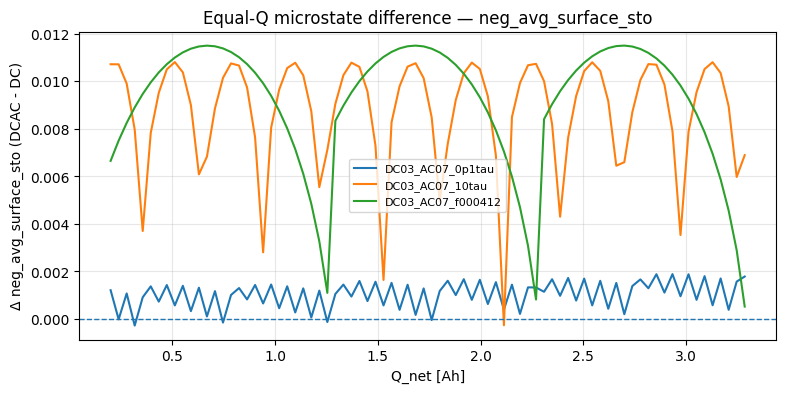

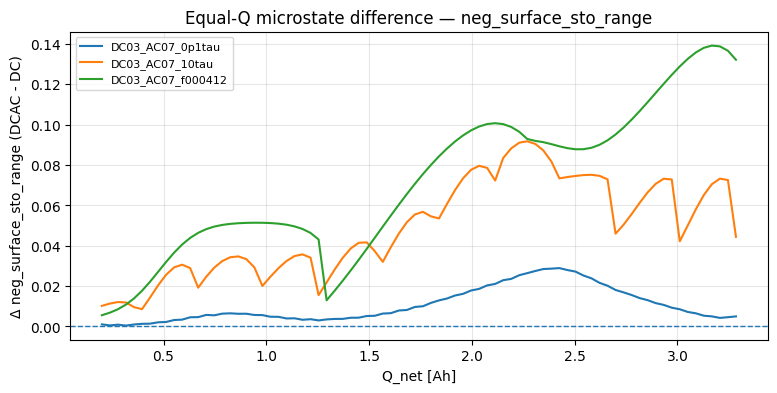

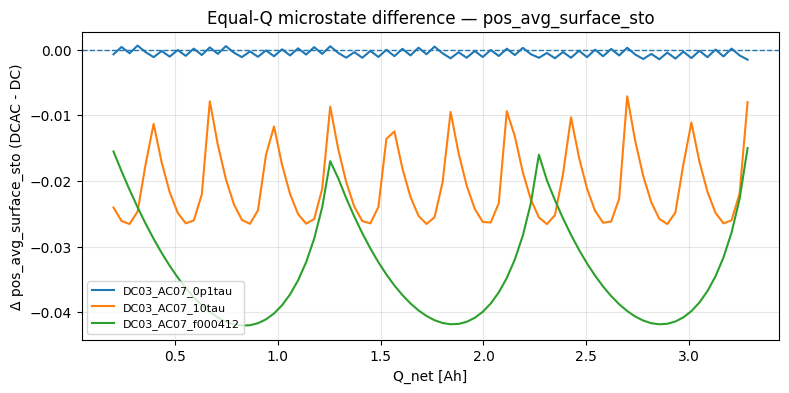

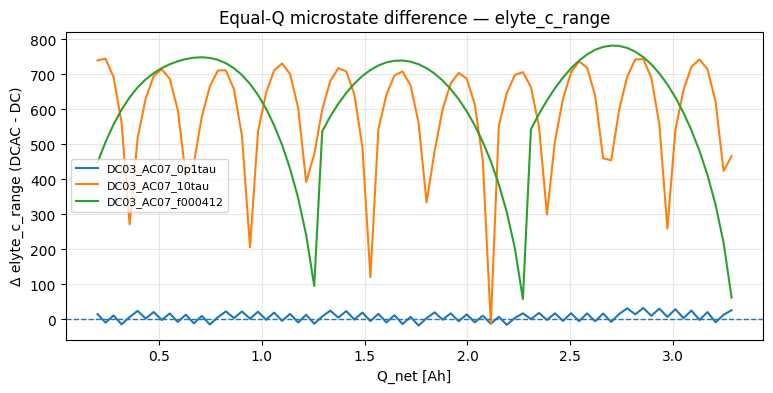

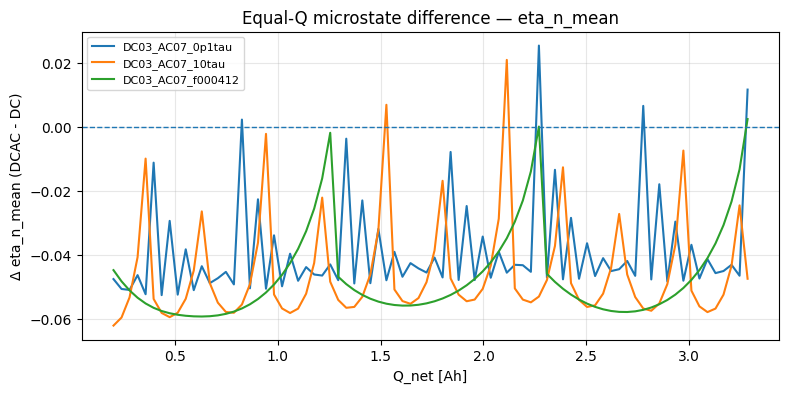

In [20]:
# Cell 14 — Plot equal-Q microstate differences（绘制等Q微观状态差异曲线）

PLOT_FEATURES = [
    "neg_avg_surface_sto",
    "neg_surface_sto_range",
    "pos_avg_surface_sto",
    "elyte_c_range",
    "eta_n_mean",
]

for feature in PLOT_FEATURES:
    plot_df = delta_long_corrected_df[
        delta_long_corrected_df["feature_id"] == feature
    ].copy()
    
    fig, ax = plt.subplots(figsize=(9, 4))
    for cond, g in plot_df.groupby("condition"):
        ax.plot(g["Q_Ah"], g["delta_x"], label=cond)
    
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel(f"Δ {feature} (DCAC - DC)")
    ax.set_title(f"Equal-Q microstate difference — {feature}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

In [21]:
# Cell 15 — Add AC phase metadata to equal-Q records（为等Q记录加入AC相位信息）

def get_smoke_condition_meta(cond):
    row = protocol_df.loc[protocol_df["condition"] == cond]
    if row.empty:
        raise KeyError(f"Condition not found in protocol_df: {cond}")
    r = row.iloc[0].to_dict()
    return {
        "condition": cond,
        "dc_c": float(r["dc_c"]),
        "ac_c": float(r["ac_c"]),
        "f_Hz": None if pd.isna(r["f_Hz"]) else float(r["f_Hz"]),
        "period_s": None if pd.isna(r["period_s"]) else float(r["period_s"]),
        "frequency_label": r["frequency_label"],
    }

def add_phase_columns(df):
    out = df.copy()
    phases = []
    cycles = []
    phase_norms = []
    periods = []
    
    for _, row in out.iterrows():
        cond = row["condition"]
        meta = get_smoke_condition_meta(cond)
        f_hz = meta["f_Hz"]
        period_s = meta["period_s"]
        t_ac = row["t_DCAC_s"]
        
        if f_hz is None or pd.isna(t_ac):
            phases.append(np.nan)
            cycles.append(np.nan)
            phase_norms.append(np.nan)
            periods.append(np.nan)
        else:
            phi = (2.0 * np.pi * f_hz * t_ac) % (2.0 * np.pi)
            phases.append(phi)
            phase_norms.append(phi / (2.0 * np.pi))
            cycles.append(f_hz * t_ac)
            periods.append(period_s)
    
    out["phase_rad_at_t_DCAC_Q"] = phases
    out["phase_norm_at_t_DCAC_Q"] = phase_norms
    out["cycle_count_at_t_DCAC_Q"] = cycles
    out["period_s"] = periods
    return out

delta_long_phase_df = add_phase_columns(delta_long_corrected_df)

out = DATA_DIR / "day30_equalQ_microstate_delta_smoke_long_with_phase.csv"
delta_long_phase_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(delta_long_phase_df.head(20))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_microstate_delta_smoke_long_with_phase.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,feature_id,x_DC,x_DCAC,delta_x,t_DC_s,t_DCAC_s,delta_t_raw_s,phase_rad_at_t_DCAC_Q,phase_norm_at_t_DCAC_Q,cycle_count_at_t_DCAC_Q,period_s
0,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_sto,0.104879,0.104886,0.000008,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
1,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_surface_sto,0.109828,0.111038,0.001210,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
2,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_max_surface_sto,0.112828,0.114718,0.001890,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
3,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_min_surface_sto,0.108233,0.109076,0.000843,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
4,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_sto,0.801565,0.801560,-0.000005,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
5,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_surface_sto,0.782653,0.781928,-0.000725,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
6,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_mean,983.128507,982.109514,-1.018993,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
7,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_range,351.368776,366.238440,14.869664,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
8,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_n_mean,-0.049882,-0.097374,-0.047492,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336
9,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_p_mean,0.004378,0.012481,0.008103,480.000000,476.675001,3.324999,2.180337,0.347011,68.347011,6.974336


In [22]:
# Cell 16 — Cycle-window mean extraction around equal-Q times（等Q附近周期窗口均值提取）

def time_window_average(t_s, y, center_s, half_width_s):
    t_s = np.asarray(t_s, dtype=float)
    y = np.asarray(y, dtype=float)
    
    lo = center_s - half_width_s
    hi = center_s + half_width_s
    
    mask = (t_s >= lo) & (t_s <= hi)
    if mask.sum() < 3:
        return {
            "mean": np.nan,
            "min": np.nan,
            "max": np.nan,
            "n_points": int(mask.sum()),
            "covered_s": 0.0,
            "valid": False,
        }
    
    tw = t_s[mask]
    yw = y[mask]
    covered_s = float(tw.max() - tw.min())
    
    return {
        "mean": float(np.nanmean(yw)),
        "min": float(np.nanmin(yw)),
        "max": float(np.nanmax(yw)),
        "n_points": int(mask.sum()),
        "covered_s": covered_s,
        "valid": True,
    }

def extract_cycle_window_delta(
    ac_condition,
    dc_condition="DC03",
    feature_cols=None,
    q_grid=None,
    half_period_fraction=0.5,
):
    if feature_cols is None:
        raise ValueError("feature_cols required")
    if q_grid is None:
        raise ValueError("q_grid required")
    
    meta = get_smoke_condition_meta(ac_condition)
    period_s = meta["period_s"]
    f_hz = meta["f_Hz"]
    
    if period_s is None:
        raise ValueError(f"AC condition has no period: {ac_condition}")
    
    half_width_s = half_period_fraction * period_s
    
    ts_ac = micro_ts_by_condition[ac_condition]
    ts_dc = micro_ts_by_condition[dc_condition]
    
    eq_ac = equal_q_tables[ac_condition].set_index("Q_Ah")
    eq_dc = equal_q_tables[dc_condition].set_index("Q_Ah")
    
    records = []
    
    for q in q_grid:
        q = float(q)
        t_ac = float(eq_ac.loc[q, "t_q_s"])
        t_dc = float(eq_dc.loc[q, "t_q_s"])
        
        phi = (2.0 * np.pi * f_hz * t_ac) % (2.0 * np.pi)
        
        for feat in feature_cols:
            if feat not in ts_ac.columns or feat not in ts_dc.columns:
                continue
            
            ac_win = time_window_average(
                ts_ac["t_s"].to_numpy(),
                ts_ac[feat].to_numpy(),
                t_ac,
                half_width_s,
            )
            dc_win = time_window_average(
                ts_dc["t_s"].to_numpy(),
                ts_dc[feat].to_numpy(),
                t_dc,
                half_width_s,
            )
            
            x_ac_inst = float(eq_ac.loc[q, feat])
            x_dc_inst = float(eq_dc.loc[q, feat])
            
            window_valid = (
                ac_win["valid"]
                and dc_win["valid"]
                and ac_win["covered_s"] >= 0.8 * period_s
                and dc_win["covered_s"] >= 0.8 * period_s
            )
            
            records.append({
                "condition": ac_condition,
                "reference_condition": dc_condition,
                "feature_id": feat,
                "Q_Ah": q,
                "t_DCAC_s": t_ac,
                "t_DC_s": t_dc,
                "period_s": period_s,
                "phase_rad": phi,
                "phase_norm": phi / (2.0 * np.pi),
                "cycle_count": f_hz * t_ac,
                "x_DCAC_inst": x_ac_inst,
                "x_DC_inst": x_dc_inst,
                "delta_x_inst": x_ac_inst - x_dc_inst,
                "x_DCAC_cycle_mean": ac_win["mean"],
                "x_DC_window_mean": dc_win["mean"],
                "delta_x_cycle_mean": ac_win["mean"] - dc_win["mean"],
                "x_DCAC_cycle_min": ac_win["min"],
                "x_DCAC_cycle_max": ac_win["max"],
                "x_DCAC_cycle_amp": ac_win["max"] - ac_win["min"],
                "ac_window_n_points": ac_win["n_points"],
                "dc_window_n_points": dc_win["n_points"],
                "ac_window_covered_s": ac_win["covered_s"],
                "dc_window_covered_s": dc_win["covered_s"],
                "window_valid": window_valid,
            })
    
    return pd.DataFrame(records)

cycle_window_dfs = []

for cond in ["DC03_AC07_0p1tau", "DC03_AC07_10tau", "DC03_AC07_f000412"]:
    print("[CYCLE WINDOW]", cond)
    cw = extract_cycle_window_delta(
        ac_condition=cond,
        dc_condition="DC03",
        feature_cols=feature_cols,
        q_grid=q_grid,
        half_period_fraction=0.5,
    )
    cycle_window_dfs.append(cw)

cycle_window_delta_df = pd.concat(cycle_window_dfs, ignore_index=True)

out = DATA_DIR / "day30_equalQ_cycle_window_delta_smoke_long.csv"
cycle_window_delta_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(cycle_window_delta_df.head(20))

[CYCLE WINDOW] DC03_AC07_0p1tau
[CYCLE WINDOW] DC03_AC07_10tau
[CYCLE WINDOW] DC03_AC07_f000412
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_cycle_window_delta_smoke_long.csv


,condition,reference_condition,feature_id,Q_Ah,t_DCAC_s,t_DC_s,period_s,phase_rad,phase_norm,cycle_count,...,x_DC_window_mean,delta_x_cycle_mean,x_DCAC_cycle_min,x_DCAC_cycle_max,x_DCAC_cycle_amp,ac_window_n_points,dc_window_n_points,ac_window_covered_s,dc_window_covered_s,window_valid
0,DC03_AC07_0p1tau,DC03,neg_avg_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.104893,-1.499350e-04,0.104407,0.105061,0.000654,76,9,6.889268,6.329497,True
1,DC03_AC07_0p1tau,DC03,neg_avg_surface_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.109843,-5.305778e-04,0.107943,0.111360,0.003418,76,9,6.889268,6.329497,True
2,DC03_AC07_0p1tau,DC03,neg_max_surface_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.112842,-1.985282e-04,0.111071,0.115066,0.003995,76,9,6.889268,6.329497,True
3,DC03_AC07_0p1tau,DC03,neg_min_surface_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.108247,-7.242963e-04,0.106254,0.109389,0.003135,76,9,6.889268,6.329497,True
4,DC03_AC07_0p1tau,DC03,pos_avg_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.801555,1.000609e-04,0.801443,0.801880,0.000437,76,9,6.889268,6.329497,True
5,DC03_AC07_0p1tau,DC03,pos_avg_surface_sto,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.782642,4.236582e-04,0.781401,0.784172,0.002770,76,9,6.889268,6.329497,True
6,DC03_AC07_0p1tau,DC03,elyte_c_mean,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,983.128406,4.100416e-01,981.539396,984.719900,3.180504,76,9,6.889268,6.329497,True
7,DC03_AC07_0p1tau,DC03,elyte_c_range,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,351.371246,-6.308320e+00,326.244092,376.439947,50.195855,76,9,6.889268,6.329497,True
8,DC03_AC07_0p1tau,DC03,eta_n_mean,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,-0.049880,2.630559e-02,-0.104487,0.061247,0.165733,76,9,6.889268,6.329497,True
9,DC03_AC07_0p1tau,DC03,eta_p_mean,0.20000,476.675001,480.000000,6.974336,2.180337,0.347011,68.347011,...,0.004378,-1.014169e-03,-0.005829,0.014408,0.020237,76,9,6.889268,6.329497,True


In [23]:
# Cell 17 — Instantaneous versus cycle-mean microstate summary（瞬时差异与周期均值差异对比）

cycle_summary_df = (
    cycle_window_delta_df
    .groupby(["condition", "feature_id"], as_index=False)
    .agg(
        n_Q=("Q_Ah", "count"),
        window_valid_fraction=("window_valid", "mean"),
        delta_x_inst_mean=("delta_x_inst", "mean"),
        delta_x_inst_abs_mean=("delta_x_inst", lambda x: np.nanmean(np.abs(x))),
        delta_x_cycle_mean=("delta_x_cycle_mean", "mean"),
        delta_x_cycle_abs_mean=("delta_x_cycle_mean", lambda x: np.nanmean(np.abs(x))),
        cycle_amp_mean=("x_DCAC_cycle_amp", "mean"),
        cycle_amp_max=("x_DCAC_cycle_amp", "max"),
        phase_min=("phase_norm", "min"),
        phase_max=("phase_norm", "max"),
        cycle_count_min=("cycle_count", "min"),
        cycle_count_max=("cycle_count", "max"),
    )
)

out = DATA_DIR / "day30_equalQ_cycle_window_delta_smoke_summary.csv"
cycle_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

KEY_FEATURES_FOR_CYCLE = [
    "neg_avg_surface_sto",
    "neg_surface_sto_range",
    "pos_avg_surface_sto",
    "elyte_c_range",
    "eta_n_mean",
]

display(
    cycle_summary_df[
        cycle_summary_df["feature_id"].isin(KEY_FEATURES_FOR_CYCLE)
    ].sort_values(["condition", "feature_id"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_equalQ_cycle_window_delta_smoke_summary.csv


,condition,feature_id,n_Q,window_valid_fraction,delta_x_inst_mean,delta_x_inst_abs_mean,delta_x_cycle_mean,delta_x_cycle_abs_mean,cycle_amp_mean,cycle_amp_max,phase_min,phase_max,cycle_count_min,cycle_count_max
2,DC03_AC07_0p1tau,elyte_c_range,80,0.6625,7.240531,12.591730,-1.553879,4.327034,49.740408,52.463005,0.146116,0.553333,68.347011,1131.524193
3,DC03_AC07_0p1tau,eta_n_mean,80,0.6625,-0.038849,0.039999,0.016255,0.016255,0.132896,0.165733,0.146116,0.553333,68.347011,1131.524193
8,DC03_AC07_0p1tau,neg_avg_surface_sto,80,0.6625,0.001035,0.001051,0.000078,0.000238,0.003388,0.003434,0.146116,0.553333,68.347011,1131.524193
12,DC03_AC07_0p1tau,neg_surface_sto_range,80,0.6625,0.010539,0.010539,0.010224,0.010224,0.001079,0.001536,0.146116,0.553333,68.347011,1131.524193
14,DC03_AC07_0p1tau,pos_avg_surface_sto,80,0.6625,-0.000549,0.000670,-0.000058,0.000178,0.002733,0.002770,0.146116,0.553333,68.347011,1131.524193
19,DC03_AC07_10tau,elyte_c_range,80,0.9875,587.903133,588.227058,172.332973,172.332973,1068.870398,1110.445571,0.144859,0.544282,0.270102,11.150317
20,DC03_AC07_10tau,eta_n_mean,80,0.9875,-0.045575,0.046272,0.005181,0.005263,0.136422,0.166286,0.144859,0.544282,0.270102,11.150317
25,DC03_AC07_10tau,neg_avg_surface_sto,80,0.9875,0.008714,0.008721,-0.004862,0.009416,0.073861,0.074982,0.144859,0.544282,0.270102,11.150317
29,DC03_AC07_10tau,neg_surface_sto_range,80,0.9875,0.049053,0.049053,0.039520,0.039520,0.039694,0.064565,0.144859,0.544282,0.270102,11.150317
31,DC03_AC07_10tau,pos_avg_surface_sto,80,0.9875,-0.020700,0.020700,0.002957,0.006334,0.086688,0.088603,0.144859,0.544282,0.270102,11.150317


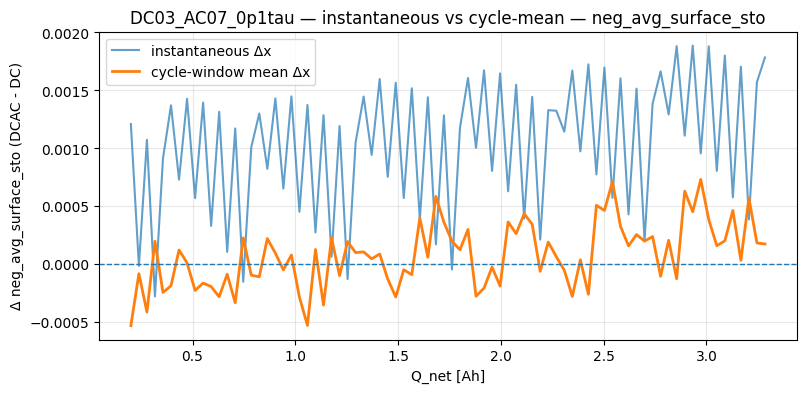

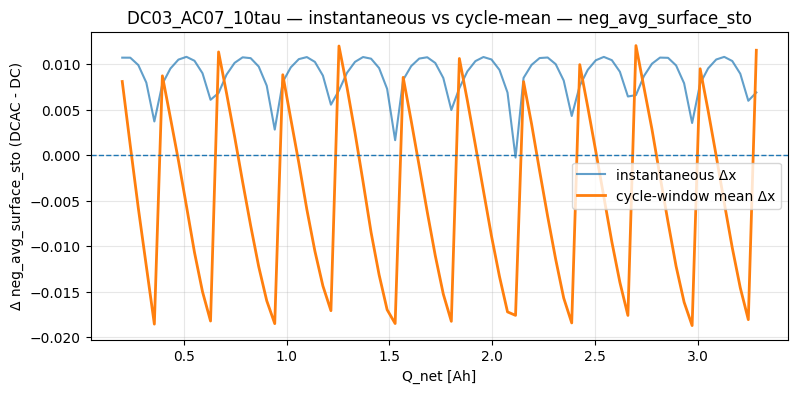

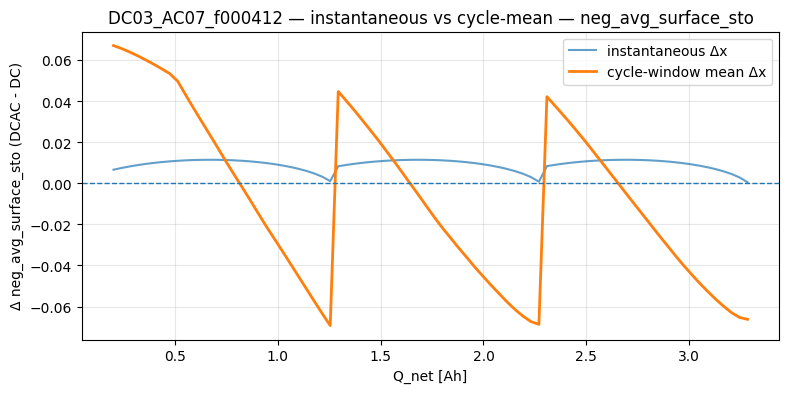

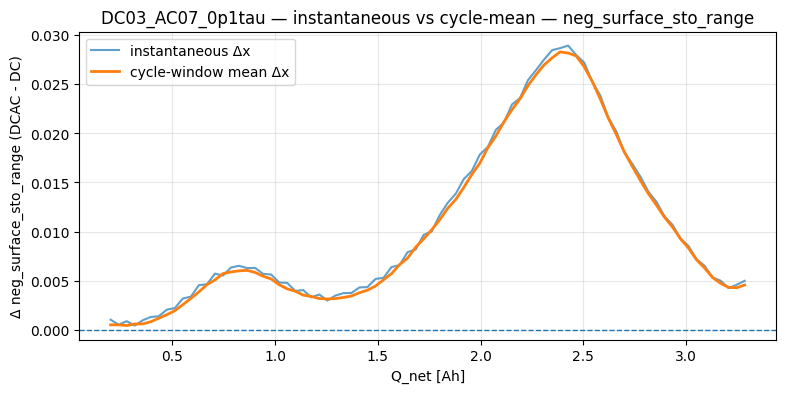

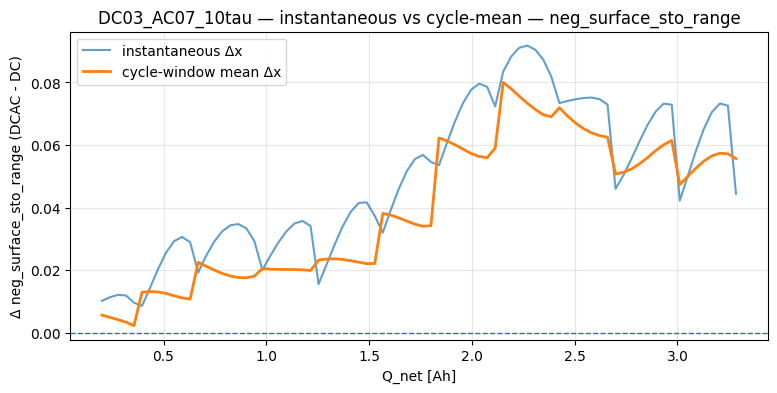

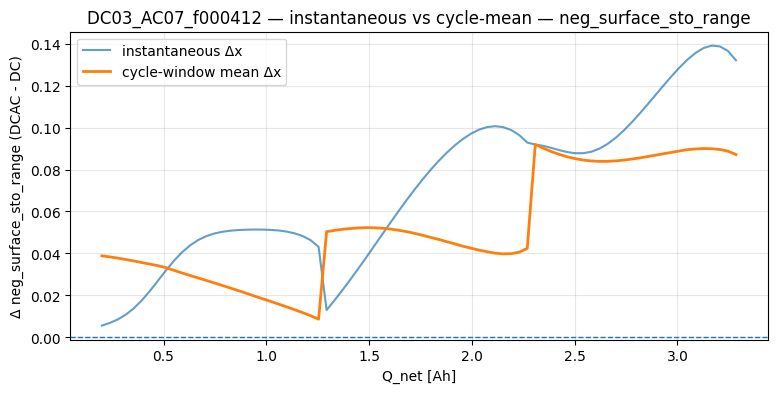

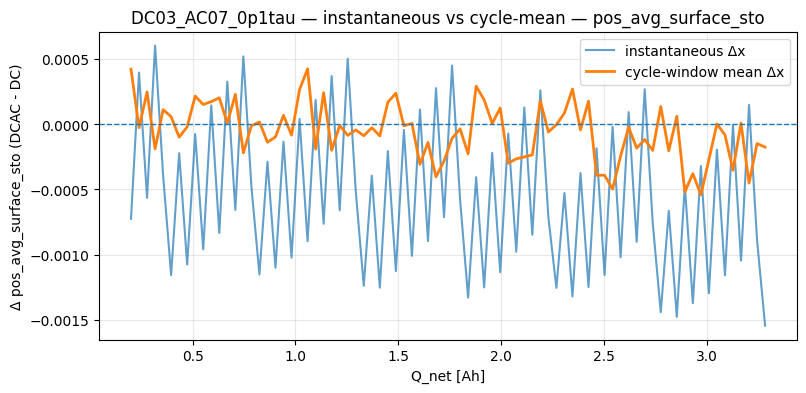

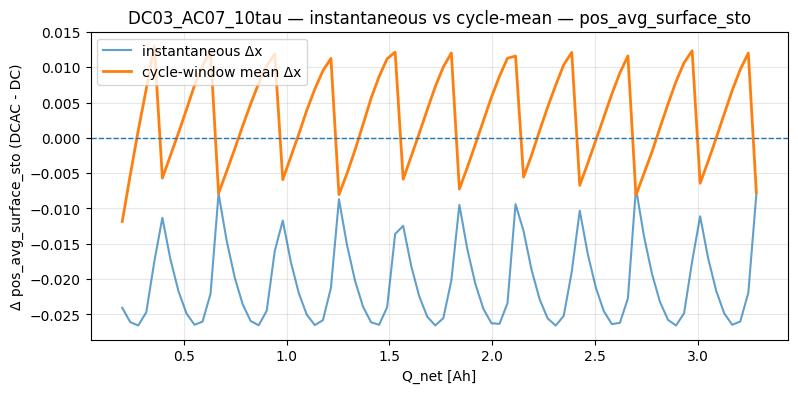

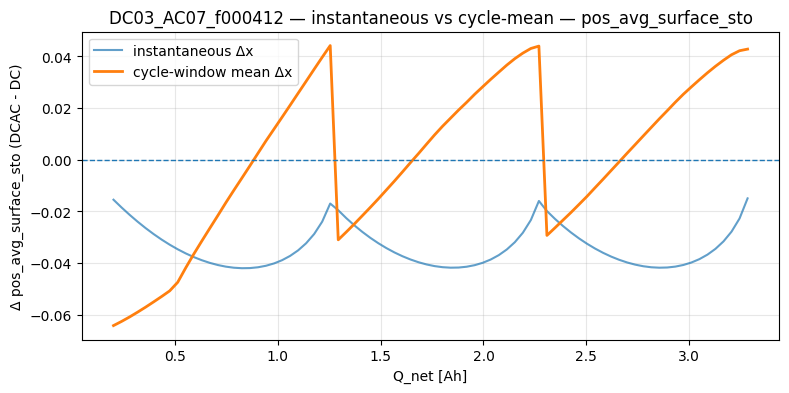

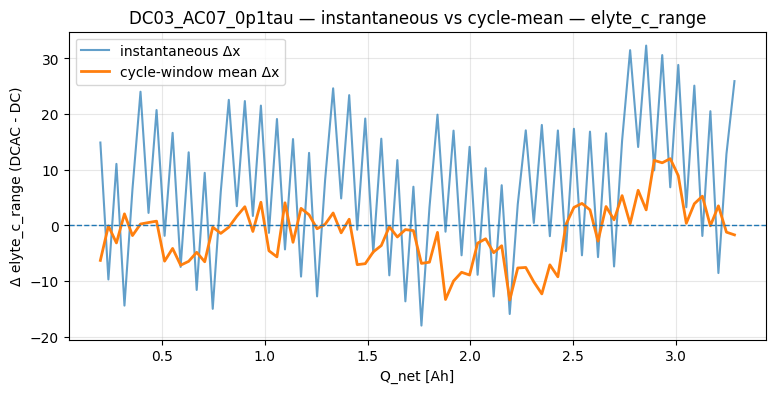

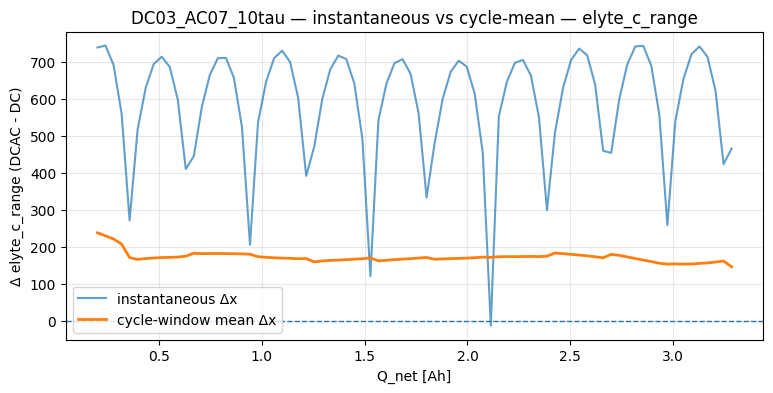

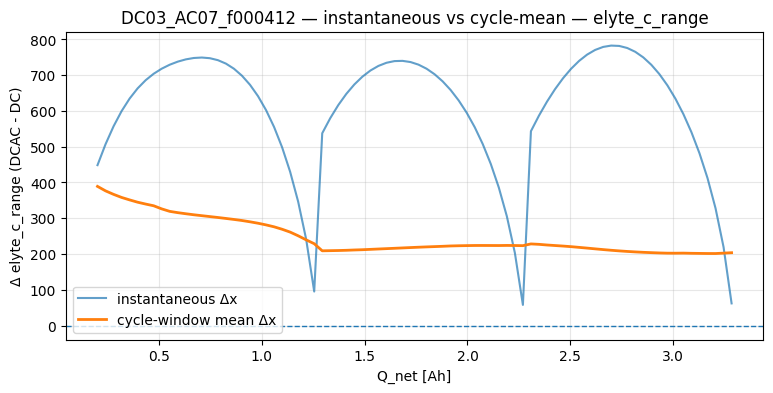

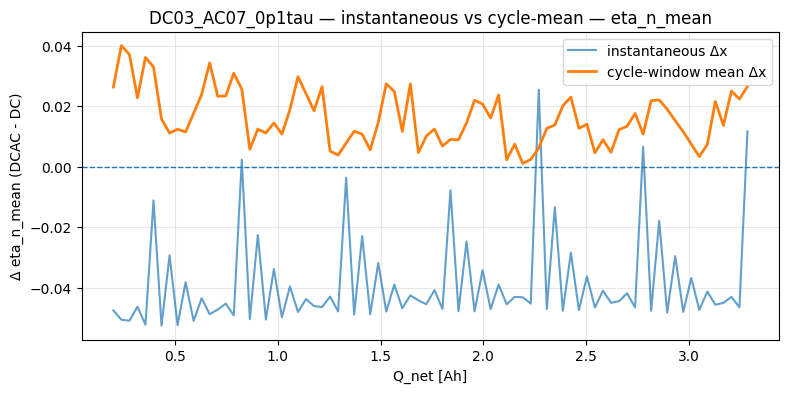

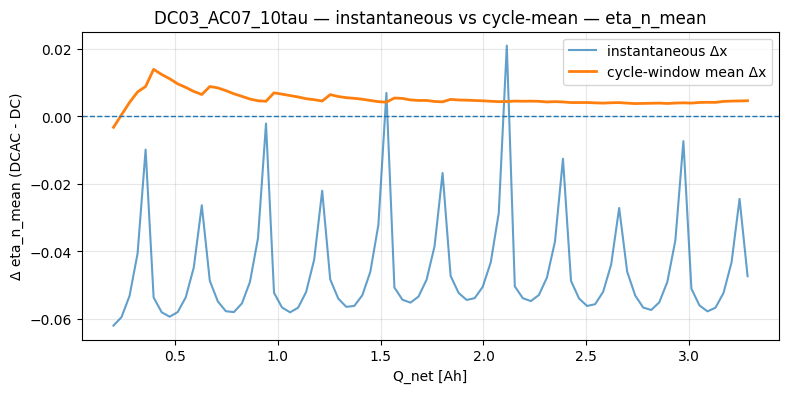

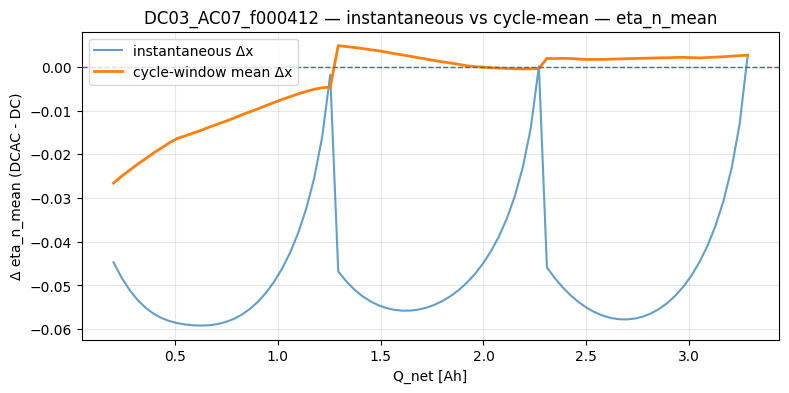

In [24]:
# Cell 18 — Plot instantaneous and cycle-mean equal-Q microstate differences（绘制瞬时与周期均值微观差异）

for feature in KEY_FEATURES_FOR_CYCLE:
    plot_df = cycle_window_delta_df[
        cycle_window_delta_df["feature_id"] == feature
    ].copy()
    
    for cond, g in plot_df.groupby("condition"):
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(g["Q_Ah"], g["delta_x_inst"], label="instantaneous Δx", alpha=0.7)
        ax.plot(g["Q_Ah"], g["delta_x_cycle_mean"], label="cycle-window mean Δx", linewidth=2)
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_xlabel("Q_net [Ah]")
        ax.set_ylabel(f"Δ {feature} (DCAC - DC)")
        ax.set_title(f"{cond} — instantaneous vs cycle-mean — {feature}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

In [25]:
# Cell 19 — Frequency-window audit metrics（频率窗口审计指标）

def q_span_per_cycle_Ah(dc_current_A, period_s):
    return dc_current_A * period_s / 3600.0

frequency_window_rows = []

Q_GRID_SPAN_Ah = float(q_grid[-1] - q_grid[0])
Q_GRID_MID_Ah = float(0.5 * (q_grid[-1] + q_grid[0]))

for cond in ["DC03_AC07_0p1tau", "DC03_AC07_10tau", "DC03_AC07_f000412"]:
    meta = get_smoke_condition_meta(cond)
    period_s = meta["period_s"]
    f_hz = meta["f_Hz"]
    
    dc_A = SMOKE_PARAMETER_SET and smoke_solutions[cond]["meta"]["i_dc_A"]
    tau_factor_mj1 = tau_factor_from_f(f_hz, TAU_LABEL_S)
    
    # For Chen2020 set tau_ref from tau_ref_df
    tau_ref_set_s = float(
        tau_ref_df.loc[tau_ref_df["parameter_set"] == SMOKE_PARAMETER_SET, "tau_ref_set_s"].iloc[0]
    )
    effective_tau_factor_set = tau_factor_from_f(f_hz, tau_ref_set_s)
    omega_tau_set = 1.0 / effective_tau_factor_set
    
    # AC charge geometry amplitude
    i_ac_A = smoke_solutions[cond]["meta"]["i_ac_A"]
    q_ac_amp_Ah = i_ac_A / (2.0 * np.pi * f_hz * 3600.0)
    
    q_per_cycle_Ah = q_span_per_cycle_Ah(dc_A, period_s)
    
    # Cycle-count based on existing phase audit
    tmp = cycle_window_delta_df[cycle_window_delta_df["condition"] == cond]
    cycle_min = float(tmp["cycle_count"].min())
    cycle_max = float(tmp["cycle_count"].max())
    cycle_span = cycle_max - cycle_min
    
    frequency_window_rows.append({
        "parameter_set": SMOKE_PARAMETER_SET,
        "model_type": SMOKE_MODEL_TYPE,
        "condition": cond,
        "f_Hz": f_hz,
        "period_s": period_s,
        "tau_factor_mj1_label": tau_factor_mj1,
        "tau_ref_set_s": tau_ref_set_s,
        "effective_tau_factor_set": effective_tau_factor_set,
        "omega_tau_set": omega_tau_set,
        "q_ac_amp_Ah": q_ac_amp_Ah,
        "q_ac_amp_mAh": q_ac_amp_Ah * 1000,
        "q_ac_amp_over_Qgrid_span": q_ac_amp_Ah / Q_GRID_SPAN_Ah,
        "q_per_cycle_Ah_from_DC": q_per_cycle_Ah,
        "q_per_cycle_over_Qgrid_span": q_per_cycle_Ah / Q_GRID_SPAN_Ah,
        "cycle_count_min": cycle_min,
        "cycle_count_max": cycle_max,
        "cycle_count_span": cycle_span,
        "window_valid_fraction_mean": float(
            tmp.groupby("feature_id")["window_valid"].mean().mean()
        ),
    })

frequency_window_df = pd.DataFrame(frequency_window_rows)

out = DATA_DIR / "day30_frequency_window_smoke_audit.csv"
frequency_window_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(frequency_window_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_frequency_window_smoke_audit.csv


,parameter_set,model_type,condition,f_Hz,period_s,tau_factor_mj1_label,tau_ref_set_s,effective_tau_factor_set,omega_tau_set,q_ac_amp_Ah,q_ac_amp_mAh,q_ac_amp_over_Qgrid_span,q_per_cycle_Ah_from_DC,q_per_cycle_over_Qgrid_span,cycle_count_min,cycle_count_max,cycle_count_span,window_valid_fraction_mean
0,Chen2020,DFN,DC03_AC07_0p1tau,0.143383,6.974336,0.100000,36.316532,0.030565,32.717597,0.001079,1.079167,0.000350,0.002906,0.000942,68.347011,1131.524193,1063.177182,0.6625
1,Chen2020,DFN,DC03_AC07_10tau,0.001434,697.433569,10.000000,36.316532,3.056459,0.327176,0.107917,107.916667,0.034982,0.290597,0.094200,0.270102,11.150317,10.880215,0.9875
2,Chen2020,DFN,DC03_AC07_f000412,0.000412,2427.184466,34.801658,36.316532,10.636985,0.094012,0.375568,375.567894,0.121744,1.011327,0.327830,0.111018,2.505631,2.394613,0.8000


In [26]:
# Cell 20 — Preliminary frequency-window classification（频率窗口初步分类）

def classify_frequency_window(row):
    omega_tau = row["omega_tau_set"]
    cycle_span = row["cycle_count_span"]
    q_cycle_ratio = row["q_per_cycle_over_Qgrid_span"]
    
    if omega_tau > 3:
        return "too_fast_filtered"
    
    if cycle_span < 3:
        return "too_slow_incomplete_cycle"
    
    if q_cycle_ratio > 0.25:
        return "too_slow_nonlocal_cycle_average"
    
    if 0.05 <= omega_tau <= 1.0 and cycle_span >= 3:
        return "candidate_time_scale_window"
    
    return "mixed_or_boundary"

frequency_window_df["frequency_window_class"] = frequency_window_df.apply(
    classify_frequency_window,
    axis=1,
)

out = DATA_DIR / "day30_frequency_window_smoke_audit_classified.csv"
frequency_window_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(frequency_window_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_frequency_window_smoke_audit_classified.csv


,parameter_set,model_type,condition,f_Hz,period_s,tau_factor_mj1_label,tau_ref_set_s,effective_tau_factor_set,omega_tau_set,q_ac_amp_Ah,q_ac_amp_mAh,q_ac_amp_over_Qgrid_span,q_per_cycle_Ah_from_DC,q_per_cycle_over_Qgrid_span,cycle_count_min,cycle_count_max,cycle_count_span,window_valid_fraction_mean,frequency_window_class
0,Chen2020,DFN,DC03_AC07_0p1tau,0.143383,6.974336,0.100000,36.316532,0.030565,32.717597,0.001079,1.079167,0.000350,0.002906,0.000942,68.347011,1131.524193,1063.177182,0.6625,too_fast_filtered
1,Chen2020,DFN,DC03_AC07_10tau,0.001434,697.433569,10.000000,36.316532,3.056459,0.327176,0.107917,107.916667,0.034982,0.290597,0.094200,0.270102,11.150317,10.880215,0.9875,candidate_time_scale_window
2,Chen2020,DFN,DC03_AC07_f000412,0.000412,2427.184466,34.801658,36.316532,10.636985,0.094012,0.375568,375.567894,0.121744,1.011327,0.327830,0.111018,2.505631,2.394613,0.8000,too_slow_incomplete_cycle


In [27]:
# Cell 21 — Add Chen2020 DFN 1τ and 5τ bridge smoke simulations（补跑Chen2020 DFN 1τ与5τ桥接工况）

BRIDGE_CONDITIONS = ["DC03_AC07_1tau", "DC03_AC07_5tau"]

bridge_rows = []

for cond in BRIDGE_CONDITIONS:
    if cond in smoke_solutions:
        print(f"[SKIP] already exists: {cond}")
        continue
    
    row = protocol_df.loc[protocol_df["condition"] == cond].iloc[0].to_dict()
    print(f"\n[RUN] {SMOKE_PARAMETER_SET} / {SMOKE_MODEL_TYPE} / {cond}")
    
    try:
        sim, sol, meta = run_simulation(
            parameter_set=SMOKE_PARAMETER_SET,
            model_type=SMOKE_MODEL_TYPE,
            protocol_row=row,
            initial_soc=0.05,
            max_time_s=24000,
            n_eval=5000,
        )
        ts = extract_solution_timeseries(sol)
        smoke_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "meta": meta,
            "ts": ts,
        }
        
        bridge_rows.append({
            "parameter_set": SMOKE_PARAMETER_SET,
            "model_type": SMOKE_MODEL_TYPE,
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
        
    except Exception as e:
        bridge_rows.append({
            "parameter_set": SMOKE_PARAMETER_SET,
            "model_type": SMOKE_MODEL_TYPE,
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

bridge_smoke_df = pd.DataFrame(bridge_rows)

out = DATA_DIR / "day30_bridge_smoke_summary_1tau_5tau.csv"
bridge_smoke_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(bridge_smoke_df)


[RUN] Chen2020 / DFN / DC03_AC07_1tau
[OK] DC03_AC07_1tau | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / DC03_AC07_5tau
[OK] DC03_AC07_5tau | termination: event: Maximum voltage [V]
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_smoke_summary_1tau_5tau.csv


,parameter_set,model_type,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,Chen2020,DFN,DC03_AC07_1tau,ok,event: Maximum voltage [V],8947.487013,149.124784,3.740982,4.2,-2.0,5.0,
1,Chen2020,DFN,DC03_AC07_5tau,ok,event: Maximum voltage [V],8454.499383,140.908323,3.574820,4.2,-2.0,5.0,


In [28]:
# Cell 22 — Extract microstate timeseries for bridge smoke conditions（提取桥接工况微观状态时间序列）

bridge_extraction_rows = []

for cond in BRIDGE_CONDITIONS:
    if cond not in smoke_solutions:
        print(f"[WARN] missing solution: {cond}")
        continue
    
    print(f"[EXTRACT] {cond}")
    micro_ts, audit = extract_microstate_timeseries(
        smoke_solutions[cond]["sol"],
        microstate_registry_df,
    )
    micro_ts_by_condition[cond] = micro_ts
    
    audit.insert(0, "condition", cond)
    bridge_extraction_rows.append(audit)

bridge_extraction_audit_df = (
    pd.concat(bridge_extraction_rows, ignore_index=True)
    if bridge_extraction_rows
    else pd.DataFrame()
)

out = DATA_DIR / "day30_bridge_microstate_extraction_audit_1tau_5tau.csv"
bridge_extraction_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(bridge_extraction_audit_df)

if not bridge_extraction_audit_df.empty and (bridge_extraction_audit_df["status"] == "failed").any():
    print("[WARN] failed extractions:")
    display(bridge_extraction_audit_df[bridge_extraction_audit_df["status"] == "failed"])

[EXTRACT] DC03_AC07_1tau
[EXTRACT] DC03_AC07_5tau
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_microstate_extraction_audit_1tau_5tau.csv


,condition,feature_id,variable_key,status,shape,error
0,DC03_AC07_1tau,neg_avg_sto,Average negative particle stoichiometry,ok,"(21619,)",
1,DC03_AC07_1tau,neg_avg_surface_sto,X-averaged negative particle surface stoichiom...,ok,"(21619,)",
2,DC03_AC07_1tau,neg_max_surface_sto,Maximum negative particle surface stoichiometry,ok,"(21619,)",
3,DC03_AC07_1tau,neg_min_surface_sto,Minimum negative particle surface stoichiometry,ok,"(21619,)",
4,DC03_AC07_1tau,pos_avg_sto,Average positive particle stoichiometry,ok,"(21619,)",
5,DC03_AC07_1tau,pos_avg_surface_sto,X-averaged positive particle surface stoichiom...,ok,"(21619,)",
6,DC03_AC07_1tau,elyte_c_mean,X-averaged electrolyte concentration [mol.m-3],ok,"(21619,)",
7,DC03_AC07_1tau,elyte_c_range,Electrolyte concentration [mol.m-3],ok,"(62, 21619)",
8,DC03_AC07_1tau,eta_n_mean,X-averaged negative electrode reaction overpot...,ok,"(21619,)",
9,DC03_AC07_1tau,eta_p_mean,X-averaged positive electrode reaction overpot...,ok,"(21619,)",


In [29]:
# Cell 23 — Rebuild full frequency-bridge equal-Q microstate analysis（重建完整频率桥接等Q微观状态分析）

FREQUENCY_BRIDGE_CONDITIONS = [
    "DC03",
    "DC03_AC07_0p1tau",
    "DC03_AC07_1tau",
    "DC03_AC07_5tau",
    "DC03_AC07_10tau",
    "DC03_AC07_f000412",
]

missing = [c for c in FREQUENCY_BRIDGE_CONDITIONS if c not in micro_ts_by_condition]
if missing:
    raise ValueError(f"Missing microstate timeseries for: {missing}")

bridge_micro_ts_by_condition = {
    c: micro_ts_by_condition[c]
    for c in FREQUENCY_BRIDGE_CONDITIONS
}

bridge_q_grid, bridge_q_end_by_cond, bridge_q_hi_raw, bridge_q_hi = build_common_q_grid(
    bridge_micro_ts_by_condition,
    q_lo_Ah=0.2,
    q_hi_fraction=0.95,
    n_grid=80,
)

print("[OK] bridge Q_end_by_condition:")
for k, v in bridge_q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")

print(f"[OK] bridge common Q grid: {bridge_q_grid[0]:.6f} → {bridge_q_grid[-1]:.6f} Ah, n={len(bridge_q_grid)}")
print(f"[INFO] raw common Q_hi={bridge_q_hi_raw:.6f} Ah, used Q_hi={bridge_q_hi:.6f} Ah")

bridge_equal_q_tables = {}

for cond, ts in bridge_micro_ts_by_condition.items():
    eq = extract_equal_q_features(ts, bridge_q_grid, feature_cols)
    eq.insert(0, "condition", cond)
    bridge_equal_q_tables[cond] = eq

bridge_equal_q_wide_df = pd.concat(bridge_equal_q_tables.values(), ignore_index=True)

out = DATA_DIR / "day30_bridge_equalQ_microstate_wide.csv"
bridge_equal_q_wide_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(bridge_equal_q_wide_df.head())

[OK] bridge Q_end_by_condition:
  DC03: 4.492879 Ah
  DC03_AC07_0p1tau: 3.808143 Ah
  DC03_AC07_1tau: 3.740982 Ah
  DC03_AC07_5tau: 3.574820 Ah
  DC03_AC07_10tau: 3.606503 Ah
  DC03_AC07_f000412: 3.457801 Ah
[OK] bridge common Q grid: 0.200000 → 3.284911 Ah, n=80
[INFO] raw common Q_hi=3.457801 Ah, used Q_hi=3.284911 Ah
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_microstate_wide.csv


,condition,Q_Ah,t_q_s,neg_avg_sto,neg_avg_surface_sto,neg_max_surface_sto,neg_min_surface_sto,pos_avg_sto,pos_avg_surface_sto,elyte_c_mean,elyte_c_range,eta_n_mean,eta_p_mean,j_n_rms,j_p_rms,cell_temperature_K,total_heating_mean,neg_surface_minus_avg_sto,pos_surface_minus_avg_sto,neg_surface_sto_range
0,DC03,0.200000,480.000000,0.104879,0.109828,0.112828,0.108233,0.801565,0.782653,983.128507,351.368776,-0.049882,0.004378,-0.446474,0.505506,298.15,0.0,0.004949,-0.018912,0.004594
1,DC03,0.239050,573.718807,0.111580,0.116529,0.119602,0.114888,0.797093,0.777507,983.090528,352.313196,-0.048905,0.004341,-0.446474,0.505506,298.15,0.0,0.004950,-0.019586,0.004715
2,DC03,0.278099,667.437615,0.118280,0.123230,0.126388,0.121546,0.792621,0.772534,983.075376,352.744730,-0.047994,0.004307,-0.446474,0.505506,298.15,0.0,0.004950,-0.020087,0.004843
3,DC03,0.317149,761.156422,0.124981,0.129931,0.133249,0.128172,0.788149,0.767687,983.083216,352.665830,-0.047143,0.004275,-0.446474,0.505506,298.15,0.0,0.004950,-0.020462,0.005077
4,DC03,0.356198,854.875229,0.131682,0.136632,0.140235,0.134741,0.783677,0.762933,983.110225,352.163176,-0.046344,0.004245,-0.446474,0.505506,298.15,0.0,0.004950,-0.020745,0.005493


In [30]:
# Cell 24 — Frequency-bridge Δx(Q) summary and verdict（频率桥接Δx(Q)摘要与判据）

bridge_dc_eq = bridge_equal_q_tables["DC03"].copy().set_index("Q_Ah")

bridge_delta_records = []

for cond, eq in bridge_equal_q_tables.items():
    if cond == "DC03":
        continue
    
    ac_eq = eq.set_index("Q_Ah")
    
    for q in bridge_q_grid:
        q = float(q)
        t_dc = float(bridge_dc_eq.loc[q, "t_q_s"])
        t_ac = float(ac_eq.loc[q, "t_q_s"])
        delta_t_raw_s = t_dc - t_ac
        
        for feature in feature_cols:
            x_dc = float(bridge_dc_eq.loc[q, feature]) if feature in bridge_dc_eq.columns else np.nan
            x_ac = float(ac_eq.loc[q, feature]) if feature in ac_eq.columns else np.nan
            
            feature_out = {
                "j_n_rms": "j_n_mean_signed",
                "j_p_rms": "j_p_mean_signed",
            }.get(feature, feature)
            
            bridge_delta_records.append({
                "parameter_set": SMOKE_PARAMETER_SET,
                "model_type": SMOKE_MODEL_TYPE,
                "condition": cond,
                "reference_condition": "DC03",
                "Q_Ah": q,
                "feature_id": feature_out,
                "x_DC": x_dc,
                "x_DCAC": x_ac,
                "delta_x": x_ac - x_dc if np.isfinite(x_ac) and np.isfinite(x_dc) else np.nan,
                "t_DC_s": t_dc,
                "t_DCAC_s": t_ac,
                "delta_t_raw_s": delta_t_raw_s,
            })

bridge_delta_long_df = pd.DataFrame(bridge_delta_records)

out = DATA_DIR / "day30_bridge_equalQ_microstate_delta_long.csv"
bridge_delta_long_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(bridge_delta_long_df.head(20))

bridge_summary_df = (
    bridge_delta_long_df
    .groupby(["parameter_set", "model_type", "condition", "feature_id"], as_index=False)
    .agg(
        delta_x_mean=("delta_x", "mean"),
        delta_x_median=("delta_x", "median"),
        delta_x_abs_mean=("delta_x", lambda x: np.nanmean(np.abs(x))),
        delta_x_max_abs=("delta_x", lambda x: np.nanmax(np.abs(x))),
        delta_x_std=("delta_x", "std"),
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
    )
)

out = DATA_DIR / "day30_bridge_equalQ_microstate_delta_summary.csv"
bridge_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

bridge_key_summary_df = bridge_summary_df[
    bridge_summary_df["feature_id"].isin(KEY_FEATURES)
].copy()

display(bridge_key_summary_df.sort_values(["condition", "feature_id"]))

bridge_compact_pivot = bridge_key_summary_df.pivot_table(
    index="condition",
    columns="feature_id",
    values="delta_x_mean",
    aggfunc="first",
)

out = DATA_DIR / "day30_bridge_equalQ_microstate_delta_compact_pivot.csv"
bridge_compact_pivot.to_csv(out)

print("[OK] saved:", out)
display(bridge_compact_pivot)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_microstate_delta_long.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,feature_id,x_DC,x_DCAC,delta_x,t_DC_s,t_DCAC_s,delta_t_raw_s
0,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_sto,0.104879,0.104886,0.000008,480.000000,476.675001,3.324999
1,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_avg_surface_sto,0.109828,0.111038,0.001210,480.000000,476.675001,3.324999
2,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_max_surface_sto,0.112828,0.114718,0.001890,480.000000,476.675001,3.324999
3,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,neg_min_surface_sto,0.108233,0.109076,0.000843,480.000000,476.675001,3.324999
4,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_sto,0.801565,0.801560,-0.000005,480.000000,476.675001,3.324999
5,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,pos_avg_surface_sto,0.782653,0.781928,-0.000725,480.000000,476.675001,3.324999
6,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_mean,983.128507,982.109514,-1.018993,480.000000,476.675001,3.324999
7,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,elyte_c_range,351.368776,366.238440,14.869664,480.000000,476.675001,3.324999
8,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_n_mean,-0.049882,-0.097374,-0.047492,480.000000,476.675001,3.324999
9,Chen2020,DFN,DC03_AC07_0p1tau,DC03,0.20000,eta_p_mean,0.004378,0.012481,0.008103,480.000000,476.675001,3.324999


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_microstate_delta_summary.csv


,parameter_set,model_type,condition,feature_id,delta_x_mean,delta_x_median,delta_x_abs_mean,delta_x_max_abs,delta_x_std,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s
1,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_mean,-0.529432,-0.591226,0.804922,1.970045,0.791295,-3.373375,-11.409728,3.732576
2,Chen2020,DFN,DC03_AC07_0p1tau,elyte_c_range,7.240531,7.683650,12.591730,32.291350,13.082327,-3.373375,-11.409728,3.732576
3,Chen2020,DFN,DC03_AC07_0p1tau,eta_n_mean,-0.038849,-0.045234,0.039999,0.052501,0.015712,-3.373375,-11.409728,3.732576
4,Chen2020,DFN,DC03_AC07_0p1tau,eta_p_mean,0.006575,0.007698,0.006704,0.009493,0.002744,-3.373375,-11.409728,3.732576
5,Chen2020,DFN,DC03_AC07_0p1tau,j_n_mean_signed,-0.783438,-0.921249,0.799138,1.040621,0.323953,-3.373375,-11.409728,3.732576
...,...,...,...,...,...,...,...,...,...,...,...,...
77,Chen2020,DFN,DC03_AC07_f000412,neg_max_surface_sto,0.058323,0.065002,0.058323,0.100679,0.025137,1098.365798,210.539181,1802.683483
79,Chen2020,DFN,DC03_AC07_f000412,neg_surface_minus_avg_sto,0.009084,0.010006,0.009084,0.011477,0.002734,1098.365798,210.539181,1802.683483
80,Chen2020,DFN,DC03_AC07_f000412,neg_surface_sto_range,0.071339,0.073080,0.071339,0.139139,0.037215,1098.365798,210.539181,1802.683483
82,Chen2020,DFN,DC03_AC07_f000412,pos_avg_surface_sto,-0.033722,-0.036201,0.033722,0.042039,0.007822,1098.365798,210.539181,1802.683483


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_microstate_delta_compact_pivot.csv


feature_id,elyte_c_mean,elyte_c_range,eta_n_mean,eta_p_mean,j_n_mean_signed,j_p_mean_signed,neg_avg_sto,neg_avg_surface_sto,neg_max_surface_sto,neg_surface_minus_avg_sto,neg_surface_sto_range,pos_avg_surface_sto,pos_surface_minus_avg_sto
condition,,,,,,,,,,,,,
DC03_AC07_0p1tau,-0.529432,7.240531,-0.038849,0.006575,-0.783438,0.886997,0.000246,0.001035,0.007827,0.000789,0.010539,-0.000549,-0.000384
DC03_AC07_10tau,-25.525453,587.903133,-0.045575,0.005824,-0.792605,0.897402,0.000007,0.008714,0.042017,0.008707,0.049053,-0.020700,-0.020695
DC03_AC07_1tau,-7.007437,128.994827,-0.040749,0.006473,-0.796172,0.901435,-0.000146,0.003665,0.013968,0.003811,0.014405,-0.004950,-0.005048
DC03_AC07_5tau,-23.465488,527.678594,-0.044496,0.005900,-0.789312,0.893674,-0.000019,0.007538,0.035231,0.007556,0.040634,-0.014514,-0.014527
DC03_AC07_f000412,-26.019139,604.326185,-0.046861,0.005895,-0.809130,0.916112,0.000021,0.009105,0.058323,0.009084,0.071339,-0.033722,-0.033708


In [32]:
# Cell 25 — Frequency-bridge cycle-window summary, bridge-table safe version（频率桥接周期窗口摘要：桥接表安全版）

def extract_cycle_window_delta_from_tables(
    ac_condition,
    dc_condition,
    feature_cols,
    q_grid,
    micro_ts_map,
    equal_q_table_map,
    half_period_fraction=0.5,
):
    """
    Bridge-safe version.
    
    Unlike the earlier smoke helper, this function does not use global equal_q_tables.
    It explicitly receives:
    - micro_ts_map
    - equal_q_table_map
    """
    meta = get_smoke_condition_meta(ac_condition)
    period_s = meta["period_s"]
    f_hz = meta["f_Hz"]
    
    if period_s is None or f_hz is None:
        raise ValueError(f"AC condition has no valid period/frequency: {ac_condition}")
    
    half_width_s = half_period_fraction * period_s
    
    ts_ac = micro_ts_map[ac_condition]
    ts_dc = micro_ts_map[dc_condition]
    
    eq_ac = equal_q_table_map[ac_condition].set_index("Q_Ah")
    eq_dc = equal_q_table_map[dc_condition].set_index("Q_Ah")
    
    records = []
    
    for q in q_grid:
        q = float(q)
        t_ac = float(eq_ac.loc[q, "t_q_s"])
        t_dc = float(eq_dc.loc[q, "t_q_s"])
        
        phi = (2.0 * np.pi * f_hz * t_ac) % (2.0 * np.pi)
        
        for feat in feature_cols:
            if feat not in ts_ac.columns or feat not in ts_dc.columns:
                continue
            
            ac_win = time_window_average(
                ts_ac["t_s"].to_numpy(),
                ts_ac[feat].to_numpy(),
                t_ac,
                half_width_s,
            )
            dc_win = time_window_average(
                ts_dc["t_s"].to_numpy(),
                ts_dc[feat].to_numpy(),
                t_dc,
                half_width_s,
            )
            
            x_ac_inst = float(eq_ac.loc[q, feat])
            x_dc_inst = float(eq_dc.loc[q, feat])
            
            window_valid = (
                ac_win["valid"]
                and dc_win["valid"]
                and ac_win["covered_s"] >= 0.8 * period_s
                and dc_win["covered_s"] >= 0.8 * period_s
            )
            
            feature_out = {
                "j_n_rms": "j_n_mean_signed",
                "j_p_rms": "j_p_mean_signed",
            }.get(feat, feat)
            
            records.append({
                "condition": ac_condition,
                "reference_condition": dc_condition,
                "feature_id": feature_out,
                "Q_Ah": q,
                "t_DCAC_s": t_ac,
                "t_DC_s": t_dc,
                "period_s": period_s,
                "phase_rad": phi,
                "phase_norm": phi / (2.0 * np.pi),
                "cycle_count": f_hz * t_ac,
                "x_DCAC_inst": x_ac_inst,
                "x_DC_inst": x_dc_inst,
                "delta_x_inst": x_ac_inst - x_dc_inst,
                "x_DCAC_cycle_mean": ac_win["mean"],
                "x_DC_window_mean": dc_win["mean"],
                "delta_x_cycle_mean": ac_win["mean"] - dc_win["mean"],
                "x_DCAC_cycle_min": ac_win["min"],
                "x_DCAC_cycle_max": ac_win["max"],
                "x_DCAC_cycle_amp": ac_win["max"] - ac_win["min"],
                "ac_window_n_points": ac_win["n_points"],
                "dc_window_n_points": dc_win["n_points"],
                "ac_window_covered_s": ac_win["covered_s"],
                "dc_window_covered_s": dc_win["covered_s"],
                "window_valid": window_valid,
            })
    
    return pd.DataFrame(records)


bridge_cycle_window_dfs = []

for cond in FREQUENCY_BRIDGE_CONDITIONS:
    if cond == "DC03":
        continue
    
    print("[CYCLE WINDOW]", cond)
    
    cw = extract_cycle_window_delta_from_tables(
        ac_condition=cond,
        dc_condition="DC03",
        feature_cols=feature_cols,
        q_grid=bridge_q_grid,
        micro_ts_map=micro_ts_by_condition,
        equal_q_table_map=bridge_equal_q_tables,
        half_period_fraction=0.5,
    )
    bridge_cycle_window_dfs.append(cw)

bridge_cycle_window_delta_df = pd.concat(bridge_cycle_window_dfs, ignore_index=True)

out = DATA_DIR / "day30_bridge_equalQ_cycle_window_delta_long.csv"
bridge_cycle_window_delta_df.to_csv(out, index=False)

print("[OK] saved:", out)

bridge_cycle_summary_df = (
    bridge_cycle_window_delta_df
    .groupby(["condition", "feature_id"], as_index=False)
    .agg(
        n_Q=("Q_Ah", "count"),
        window_valid_fraction=("window_valid", "mean"),
        delta_x_inst_mean=("delta_x_inst", "mean"),
        delta_x_inst_abs_mean=("delta_x_inst", lambda x: np.nanmean(np.abs(x))),
        delta_x_cycle_mean=("delta_x_cycle_mean", "mean"),
        delta_x_cycle_abs_mean=("delta_x_cycle_mean", lambda x: np.nanmean(np.abs(x))),
        cycle_amp_mean=("x_DCAC_cycle_amp", "mean"),
        cycle_amp_max=("x_DCAC_cycle_amp", "max"),
        phase_min=("phase_norm", "min"),
        phase_max=("phase_norm", "max"),
        cycle_count_min=("cycle_count", "min"),
        cycle_count_max=("cycle_count", "max"),
    )
)

out = DATA_DIR / "day30_bridge_equalQ_cycle_window_delta_summary.csv"
bridge_cycle_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    bridge_cycle_summary_df[
        bridge_cycle_summary_df["feature_id"].isin(KEY_FEATURES_FOR_CYCLE)
    ].sort_values(["condition", "feature_id"])
)

[CYCLE WINDOW] DC03_AC07_0p1tau
[CYCLE WINDOW] DC03_AC07_1tau
[CYCLE WINDOW] DC03_AC07_5tau
[CYCLE WINDOW] DC03_AC07_10tau
[CYCLE WINDOW] DC03_AC07_f000412
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_cycle_window_delta_long.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_equalQ_cycle_window_delta_summary.csv


,condition,feature_id,n_Q,window_valid_fraction,delta_x_inst_mean,delta_x_inst_abs_mean,delta_x_cycle_mean,delta_x_cycle_abs_mean,cycle_amp_mean,cycle_amp_max,phase_min,phase_max,cycle_count_min,cycle_count_max
2,DC03_AC07_0p1tau,elyte_c_range,80,0.6625,7.240531,12.591730,-1.553879,4.327034,49.740408,52.463005,0.146116,0.553333,68.347011,1131.524193
3,DC03_AC07_0p1tau,eta_n_mean,80,0.6625,-0.038849,0.039999,0.016255,0.016255,0.132896,0.165733,0.146116,0.553333,68.347011,1131.524193
8,DC03_AC07_0p1tau,neg_avg_surface_sto,80,0.6625,0.001035,0.001051,0.000078,0.000238,0.003388,0.003434,0.146116,0.553333,68.347011,1131.524193
12,DC03_AC07_0p1tau,neg_surface_sto_range,80,0.6625,0.010539,0.010539,0.010224,0.010224,0.001079,0.001536,0.146116,0.553333,68.347011,1131.524193
14,DC03_AC07_0p1tau,pos_avg_surface_sto,80,0.6625,-0.000549,0.000670,-0.000058,0.000178,0.002733,0.002770,0.146116,0.553333,68.347011,1131.524193
19,DC03_AC07_10tau,elyte_c_range,80,0.9875,587.903133,588.227058,172.332973,172.332973,1068.870398,1110.445571,0.144859,0.544282,0.270102,11.150317
20,DC03_AC07_10tau,eta_n_mean,80,0.9875,-0.045575,0.046272,0.005181,0.005263,0.136422,0.166286,0.144859,0.544282,0.270102,11.150317
25,DC03_AC07_10tau,neg_avg_surface_sto,80,0.9875,0.008714,0.008721,-0.004862,0.009416,0.073861,0.074982,0.144859,0.544282,0.270102,11.150317
29,DC03_AC07_10tau,neg_surface_sto_range,80,0.9875,0.049053,0.049053,0.039520,0.039520,0.039694,0.064565,0.144859,0.544282,0.270102,11.150317
31,DC03_AC07_10tau,pos_avg_surface_sto,80,0.9875,-0.020700,0.020700,0.002957,0.006334,0.086688,0.088603,0.144859,0.544282,0.270102,11.150317


In [33]:
# Cell 26 — Frequency-bridge window metrics and classification（频率桥接窗口指标与分类）

bridge_frequency_window_rows = []

BRIDGE_Q_GRID_SPAN_Ah = float(bridge_q_grid[-1] - bridge_q_grid[0])

for cond in FREQUENCY_BRIDGE_CONDITIONS:
    if cond == "DC03":
        continue
    
    meta = get_smoke_condition_meta(cond)
    period_s = meta["period_s"]
    f_hz = meta["f_Hz"]
    
    dc_A = smoke_solutions[cond]["meta"]["i_dc_A"]
    i_ac_A = smoke_solutions[cond]["meta"]["i_ac_A"]
    
    tau_ref_set_s = float(
        tau_ref_df.loc[tau_ref_df["parameter_set"] == SMOKE_PARAMETER_SET, "tau_ref_set_s"].iloc[0]
    )
    effective_tau_factor_set = tau_factor_from_f(f_hz, tau_ref_set_s)
    omega_tau_set = 1.0 / effective_tau_factor_set
    
    q_ac_amp_Ah = i_ac_A / (2.0 * np.pi * f_hz * 3600.0)
    q_per_cycle_Ah = q_span_per_cycle_Ah(dc_A, period_s)
    
    tmp = bridge_cycle_window_delta_df[bridge_cycle_window_delta_df["condition"] == cond]
    cycle_min = float(tmp["cycle_count"].min())
    cycle_max = float(tmp["cycle_count"].max())
    cycle_span = cycle_max - cycle_min
    
    bridge_frequency_window_rows.append({
        "parameter_set": SMOKE_PARAMETER_SET,
        "model_type": SMOKE_MODEL_TYPE,
        "condition": cond,
        "f_Hz": f_hz,
        "period_s": period_s,
        "tau_factor_mj1_label": tau_factor_from_f(f_hz, TAU_LABEL_S),
        "tau_ref_set_s": tau_ref_set_s,
        "effective_tau_factor_set": effective_tau_factor_set,
        "omega_tau_set": omega_tau_set,
        "q_ac_amp_Ah": q_ac_amp_Ah,
        "q_ac_amp_mAh": q_ac_amp_Ah * 1000,
        "q_ac_amp_over_Qgrid_span": q_ac_amp_Ah / BRIDGE_Q_GRID_SPAN_Ah,
        "q_per_cycle_Ah_from_DC": q_per_cycle_Ah,
        "q_per_cycle_over_Qgrid_span": q_per_cycle_Ah / BRIDGE_Q_GRID_SPAN_Ah,
        "cycle_count_min": cycle_min,
        "cycle_count_max": cycle_max,
        "cycle_count_span": cycle_span,
        "window_valid_fraction_mean": float(
            tmp.groupby("feature_id")["window_valid"].mean().mean()
        ),
    })

bridge_frequency_window_df = pd.DataFrame(bridge_frequency_window_rows)

bridge_frequency_window_df["frequency_window_class"] = bridge_frequency_window_df.apply(
    classify_frequency_window,
    axis=1,
)

out = DATA_DIR / "day30_bridge_frequency_window_audit_classified.csv"
bridge_frequency_window_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(bridge_frequency_window_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_frequency_window_audit_classified.csv


,parameter_set,model_type,condition,f_Hz,period_s,tau_factor_mj1_label,tau_ref_set_s,effective_tau_factor_set,omega_tau_set,q_ac_amp_Ah,q_ac_amp_mAh,q_ac_amp_over_Qgrid_span,q_per_cycle_Ah_from_DC,q_per_cycle_over_Qgrid_span,cycle_count_min,cycle_count_max,cycle_count_span,window_valid_fraction_mean,frequency_window_class
0,Chen2020,DFN,DC03_AC07_0p1tau,0.143383,6.974336,0.100000,36.316532,0.030565,32.717597,0.001079,1.079167,0.000350,0.002906,0.000942,68.347011,1131.524193,1063.177182,0.6625,too_fast_filtered
1,Chen2020,DFN,DC03_AC07_1tau,0.014338,69.743357,1.000000,36.316532,0.305646,3.271760,0.010792,10.791667,0.003498,0.029060,0.009420,6.331438,112.396327,106.064889,1.0000,too_fast_filtered
2,Chen2020,DFN,DC03_AC07_5tau,0.002868,348.716785,5.000000,36.316532,1.528230,0.654352,0.053958,53.958333,0.017491,0.145299,0.047100,1.174587,22.246023,21.071436,1.0000,candidate_time_scale_window
3,Chen2020,DFN,DC03_AC07_10tau,0.001434,697.433569,10.000000,36.316532,3.056459,0.327176,0.107917,107.916667,0.034982,0.290597,0.094200,0.270102,11.150317,10.880215,0.9875,candidate_time_scale_window
4,Chen2020,DFN,DC03_AC07_f000412,0.000412,2427.184466,34.801658,36.316532,10.636985,0.094012,0.375568,375.567894,0.121744,1.011327,0.327830,0.111018,2.505631,2.394613,0.8000,too_slow_incomplete_cycle


In [34]:
# Cell 27 — Frequency-bridge integrated verdict table（频率桥接综合判据表）

KEY_VERDICT_FEATURES = [
    "elyte_c_range",
    "neg_surface_sto_range",
    "neg_avg_surface_sto",
    "pos_avg_surface_sto",
    "eta_n_mean",
]

# Pivot cycle-window summary
cycle_verdict_pivot = (
    bridge_cycle_summary_df[
        bridge_cycle_summary_df["feature_id"].isin(KEY_VERDICT_FEATURES)
    ]
    .pivot_table(
        index="condition",
        columns="feature_id",
        values=[
            "delta_x_inst_mean",
            "delta_x_cycle_mean",
            "delta_x_cycle_abs_mean",
            "cycle_amp_mean",
            "window_valid_fraction",
        ],
        aggfunc="first",
    )
)

# Flatten columns
cycle_verdict_pivot.columns = [
    f"{metric}__{feature}"
    for metric, feature in cycle_verdict_pivot.columns
]
cycle_verdict_pivot = cycle_verdict_pivot.reset_index()

# Add raw timing from bridge summary
dt_bridge = (
    bridge_summary_df
    .groupby("condition", as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_mean_s", "first"),
        delta_t_raw_min_s=("delta_t_raw_min_s", "first"),
        delta_t_raw_max_s=("delta_t_raw_max_s", "first"),
    )
)

frequency_bridge_verdict_df = (
    bridge_frequency_window_df
    .merge(dt_bridge, on="condition", how="left")
    .merge(cycle_verdict_pivot, on="condition", how="left")
)

def classify_integrated_frequency_response(row):
    omega_tau = row["omega_tau_set"]
    cycle_span = row["cycle_count_span"]
    q_cycle_ratio = row["q_per_cycle_over_Qgrid_span"]
    
    elyte_cycle = row.get("delta_x_cycle_mean__elyte_c_range", np.nan)
    neg_range_cycle = row.get("delta_x_cycle_mean__neg_surface_sto_range", np.nan)
    neg_surf_cycle_abs = row.get("delta_x_cycle_abs_mean__neg_avg_surface_sto", np.nan)
    
    # Too fast: high omega_tau, weak cycle-mean electrolyte/gradient response
    if omega_tau > 3 and abs(elyte_cycle) < 20 and abs(neg_range_cycle) < 0.02:
        return "too_fast_filtered"
    
    # Too slow: insufficient cycles or nonlocal cycle average
    if cycle_span < 3 or q_cycle_ratio > 0.25:
        return "too_slow_or_nonlocal_boundary"
    
    # Main candidate: enough response, enough cycles, local enough
    if (
        0.2 <= omega_tau <= 1.0
        and cycle_span >= 5
        and q_cycle_ratio <= 0.12
        and elyte_cycle > 50
        and neg_range_cycle > 0.02
    ):
        return "candidate_microstate_response_window"
    
    # Transition: some response but not yet robust
    if (
        1.0 < omega_tau <= 5.0
        and cycle_span >= 10
        and neg_range_cycle > 0.005
    ):
        return "transition_filtered_to_response"
    
    return "mixed_or_unresolved"

frequency_bridge_verdict_df["integrated_frequency_response_class"] = (
    frequency_bridge_verdict_df.apply(classify_integrated_frequency_response, axis=1)
)

out = DATA_DIR / "day30_bridge_integrated_frequency_response_verdict.csv"
frequency_bridge_verdict_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols_to_show = [
    "condition",
    "effective_tau_factor_set",
    "omega_tau_set",
    "q_per_cycle_over_Qgrid_span",
    "cycle_count_span",
    "delta_t_raw_mean_s",
    "delta_x_cycle_mean__elyte_c_range",
    "delta_x_cycle_mean__neg_surface_sto_range",
    "delta_x_cycle_abs_mean__neg_avg_surface_sto",
    "frequency_window_class",
    "integrated_frequency_response_class",
]

display(frequency_bridge_verdict_df[cols_to_show])

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_bridge_integrated_frequency_response_verdict.csv


,condition,effective_tau_factor_set,omega_tau_set,q_per_cycle_over_Qgrid_span,cycle_count_span,delta_t_raw_mean_s,delta_x_cycle_mean__elyte_c_range,delta_x_cycle_mean__neg_surface_sto_range,delta_x_cycle_abs_mean__neg_avg_surface_sto,frequency_window_class,integrated_frequency_response_class
0,DC03_AC07_0p1tau,0.030565,32.717597,0.000942,1063.177182,-3.373375,-1.553879,0.010224,0.000238,too_fast_filtered,too_fast_filtered
1,DC03_AC07_1tau,0.305646,3.271760,0.009420,106.064889,31.810290,-7.706110,0.013107,0.001049,too_fast_filtered,too_fast_filtered
2,DC03_AC07_5tau,1.528230,0.654352,0.047100,21.071436,164.549386,123.872513,0.034567,0.004634,candidate_time_scale_window,candidate_microstate_response_window
3,DC03_AC07_10tau,3.056459,0.327176,0.094200,10.880215,331.532565,172.332973,0.039520,0.009416,candidate_time_scale_window,candidate_microstate_response_window
4,DC03_AC07_f000412,10.636985,0.094012,0.327830,2.394613,1098.365798,247.128765,0.052597,0.035914,too_slow_incomplete_cycle,too_slow_or_nonlocal_boundary


## Smoke-level interpretation after frequency bridge

The Chen2020 / DFN frequency-bridge audit shows that the relevant frequency window is not defined by the original MJ1 label alone. When the MJ1-derived frequencies are interpreted relative to the Chen2020 relaxation descriptor `tau2_biexp = 36.32 s`, the effective normalized frequency shifts substantially.

The 0.1τ_MJ1 condition corresponds to only 0.031τ_set and behaves as a too-fast filtered regime. Its instantaneous equal-Q microstate differences are small and mostly collapse under cycle-window averaging.

The 1τ_MJ1 condition corresponds to 0.306τ_set and remains close to the filtered-to-response transition. It shows moderate instantaneous electrolyte response but weak cycle-mean microstate persistence.

The 5τ_MJ1 condition corresponds to 1.53τ_set and enters the main candidate response window. It produces cycle-averaged electrolyte concentration-gradient and negative-surface-stoichiometry-range differences while retaining sufficient cycle count and acceptable Q-locality.

The 10τ_MJ1 condition corresponds to 3.06τ_set and produces stronger microstate gradients, but with larger Q-per-cycle displacement. It is therefore interpreted as a strong-response window rather than an automatically optimal condition.

The f=0.000412 Hz branch corresponds to 10.64τ_set in Chen2020. It is a very-low-frequency boundary case with too few cycles and nonlocal cycle averaging; it should not be used as primary evidence for a persistent mechanism.

Overall, the smoke audit suggests that the candidate microstate-response window for Chen2020 / DFN lies around 1.5–3τ_set, with 5τ_MJ1 and 10τ_MJ1 serving as the current primary response anchors.

## Section B — Fine scan of Chen2020 / DFN normalized frequency window

The bridge audit showed that the apparent MJ1-label frequency response should be reinterpreted relative to the Chen2020 relaxation descriptor. The strongest candidate region lies between approximately 1.5τ_set and 3τ_set, while lower values remain filtered and higher values become increasingly nonlocal or boundary-sensitive.

This section performs a fine set-rebased frequency scan using Chen2020 / DFN only. The goal is not to generalize across models yet, but to localize the candidate microstate-response window before expanding to parameter-set and model-hierarchy comparisons.

In [35]:
# Cell 28 — Define Chen2020 DFN fine normalized-frequency scan（定义Chen2020 DFN精细归一化频率扫描）

FINE_SCAN_PARAMETER_SET = "Chen2020"
FINE_SCAN_MODEL_TYPE = "DFN"
FINE_SCAN_TAU_REF_S = float(
    tau_ref_df.loc[
        tau_ref_df["parameter_set"] == FINE_SCAN_PARAMETER_SET,
        "tau_ref_set_s"
    ].iloc[0]
)

# Focus on the transition-to-response window.
# Include one fast-side anchor and one slow-side anchor.
FINE_TAU_FACTORS = [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0,
    4.0,
    5.0,
]

def label_from_tau_factor_set(tau_factor):
    s = str(tau_factor).replace(".", "p")
    return f"{s}tauSet"

fine_scan_rows = []

# DC baseline
fine_scan_rows.append({
    "frequency_mode": "chen2020_set_tau_ref_fine_scan",
    "parameter_set": FINE_SCAN_PARAMETER_SET,
    "model_type": FINE_SCAN_MODEL_TYPE,
    "condition": "Chen2020_DFN_fine_DC03",
    "base_condition": "DC03",
    "dc_c": DC_C,
    "ac_c": 0.0,
    "frequency_label": "DC",
    "tau_factor_set": np.nan,
    "tau_ref_set_s": FINE_SCAN_TAU_REF_S,
    "f_Hz": np.nan,
    "period_s": np.nan,
    "omega_tau_set": np.nan,
    "kappa": 0.0,
})

for tau_factor in FINE_TAU_FACTORS:
    f_hz = 1.0 / (2.0 * np.pi * tau_factor * FINE_SCAN_TAU_REF_S)
    period_s = 1.0 / f_hz
    label = label_from_tau_factor_set(tau_factor)
    
    fine_scan_rows.append({
        "frequency_mode": "chen2020_set_tau_ref_fine_scan",
        "parameter_set": FINE_SCAN_PARAMETER_SET,
        "model_type": FINE_SCAN_MODEL_TYPE,
        "condition": f"Chen2020_DFN_fine_DC03_AC07_{label}",
        "base_condition": f"DC03_AC07_{label}",
        "dc_c": DC_C,
        "ac_c": AC_C,
        "frequency_label": label,
        "tau_factor_set": tau_factor,
        "tau_ref_set_s": FINE_SCAN_TAU_REF_S,
        "f_Hz": f_hz,
        "period_s": period_s,
        "omega_tau_set": 1.0 / tau_factor,
        "kappa": AC_C / DC_C,
    })

fine_scan_protocol_df = pd.DataFrame(fine_scan_rows)

out = DATA_DIR / "day30_fine_scan_chen2020_dfn_protocol_table.csv"
fine_scan_protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_scan_protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_chen2020_dfn_protocol_table.csv


,frequency_mode,parameter_set,model_type,condition,base_condition,dc_c,ac_c,frequency_label,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03,DC03,0.3,0.0,DC,NaN,36.316532,NaN,NaN,NaN,0.000000
1,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,DC03_AC07_0p5tauSet,0.3,0.7,0p5tauSet,0.5,36.316532,0.008765,114.091751,2.000000,2.333333
2,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,DC03_AC07_1p0tauSet,0.3,0.7,1p0tauSet,1.0,36.316532,0.004382,228.183502,1.000000,2.333333
3,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,DC03_AC07_1p5tauSet,0.3,0.7,1p5tauSet,1.5,36.316532,0.002922,342.275253,0.666667,2.333333
4,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,DC03_AC07_2p0tauSet,0.3,0.7,2p0tauSet,2.0,36.316532,0.002191,456.367003,0.500000,2.333333
5,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,DC03_AC07_3p0tauSet,0.3,0.7,3p0tauSet,3.0,36.316532,0.001461,684.550505,0.333333,2.333333
6,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_4p0tauSet,DC03_AC07_4p0tauSet,0.3,0.7,4p0tauSet,4.0,36.316532,0.001096,912.734007,0.250000,2.333333
7,chen2020_set_tau_ref_fine_scan,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,DC03_AC07_5p0tauSet,0.3,0.7,5p0tauSet,5.0,36.316532,0.000876,1140.917509,0.200000,2.333333


In [36]:
# Cell 29 — Run Chen2020 DFN fine-scan simulations（运行Chen2020 DFN精细频率扫描）

fine_scan_solutions = {}
fine_scan_rows_out = []

for _, row in fine_scan_protocol_df.iterrows():
    cond = row["condition"]
    
    # Reuse existing DC03 baseline if possible, but keep a scan-local alias.
    if row["ac_c"] == 0:
        print(f"[REUSE] DC baseline for {cond}")
        fine_scan_solutions[cond] = {
            "sim": smoke_solutions["DC03"]["sim"],
            "sol": smoke_solutions["DC03"]["sol"],
            "meta": smoke_solutions["DC03"]["meta"],
            "ts": smoke_solutions["DC03"]["ts"],
        }
        ts = fine_scan_solutions[cond]["ts"]
        fine_scan_rows_out.append({
            "parameter_set": FINE_SCAN_PARAMETER_SET,
            "model_type": FINE_SCAN_MODEL_TYPE,
            "condition": cond,
            "status": "ok_reused",
            "termination": str(fine_scan_solutions[cond]["sol"].termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "error": "",
        })
        continue
    
    print(f"\n[RUN] {FINE_SCAN_PARAMETER_SET} / {FINE_SCAN_MODEL_TYPE} / {cond}")
    
    try:
        sim, sol, meta = run_simulation(
            parameter_set=FINE_SCAN_PARAMETER_SET,
            model_type=FINE_SCAN_MODEL_TYPE,
            protocol_row=row.to_dict(),
            initial_soc=0.05,
            max_time_s=24000,
            n_eval=5000,
        )
        ts = extract_solution_timeseries(sol)
        fine_scan_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "meta": meta,
            "ts": ts,
        }
        
        fine_scan_rows_out.append({
            "parameter_set": FINE_SCAN_PARAMETER_SET,
            "model_type": FINE_SCAN_MODEL_TYPE,
            "condition": cond,
            "status": "ok",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
        
    except Exception as e:
        fine_scan_rows_out.append({
            "parameter_set": FINE_SCAN_PARAMETER_SET,
            "model_type": FINE_SCAN_MODEL_TYPE,
            "condition": cond,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

fine_scan_smoke_df = pd.DataFrame(fine_scan_rows_out)

out = DATA_DIR / "day30_fine_scan_chen2020_dfn_smoke_summary.csv"
fine_scan_smoke_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_scan_smoke_df)

[REUSE] DC baseline for Chen2020_DFN_fine_DC03

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_0p5tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_1p0tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_1p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_1p5tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_2p0tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_2p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_3p0tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_3p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_4p0tauSet
[OK] Chen2020_DFN_fine_DC03_AC07_4p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / DFN / Chen2020_DFN_fine_DC03_AC07_5p0tauSet
[OK] Chen

,parameter_set,model_type,condition,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,tau_factor_set,f_Hz,period_s,error
0,Chen2020,DFN,Chen2020_DFN_fine_DC03,ok_reused,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.5,NaN,NaN,NaN,
1,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,ok,event: Maximum voltage [V],8816.441612,146.940694,3.693538,4.2,-2.000000,5.0,0.5,0.008765,114.091751,
2,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,ok,event: Maximum voltage [V],8721.164196,145.352737,3.662453,4.2,-2.000000,5.0,1.0,0.004382,228.183502,
3,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,ok,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000,5.0,1.5,0.002922,342.275253,
4,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,ok,event: Maximum voltage [V],8327.730500,138.795508,3.539555,4.2,-1.999999,5.0,2.0,0.002191,456.367003,
5,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,ok,event: Maximum voltage [V],8356.422363,139.273706,3.559599,4.2,-2.000000,5.0,3.0,0.001461,684.550505,
6,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_4p0tauSet,ok,event: Maximum voltage [V],8383.499638,139.724994,3.578299,4.2,-2.000000,5.0,4.0,0.001096,912.734007,
7,Chen2020,DFN,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,ok,event: Maximum voltage [V],8207.258608,136.787643,3.534928,4.2,-1.999999,5.0,5.0,0.000876,1140.917509,


In [37]:
# Cell 30 — Extract microstate timeseries for fine scan（提取精细扫描微观状态时间序列）

fine_micro_ts_by_condition = {}
fine_extraction_rows = []

for cond, obj in fine_scan_solutions.items():
    print(f"[EXTRACT] {cond}")
    micro_ts, audit = extract_microstate_timeseries(
        obj["sol"],
        microstate_registry_df,
    )
    fine_micro_ts_by_condition[cond] = micro_ts
    
    audit.insert(0, "condition", cond)
    fine_extraction_rows.append(audit)

fine_extraction_audit_df = pd.concat(fine_extraction_rows, ignore_index=True)

out = DATA_DIR / "day30_fine_scan_microstate_extraction_audit.csv"
fine_extraction_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(fine_extraction_audit_df)

if (fine_extraction_audit_df["status"] == "failed").any():
    print("[WARN] failed extractions:")
    display(fine_extraction_audit_df[fine_extraction_audit_df["status"] == "failed"])

[EXTRACT] Chen2020_DFN_fine_DC03
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_0p5tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_1p0tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_1p5tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_2p0tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_3p0tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_4p0tauSet
[EXTRACT] Chen2020_DFN_fine_DC03_AC07_5p0tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_microstate_extraction_audit.csv


,condition,feature_id,variable_key,status,shape,error
0,Chen2020_DFN_fine_DC03,neg_avg_sto,Average negative particle stoichiometry,ok,"(12159,)",
1,Chen2020_DFN_fine_DC03,neg_avg_surface_sto,X-averaged negative particle surface stoichiom...,ok,"(12159,)",
2,Chen2020_DFN_fine_DC03,neg_max_surface_sto,Maximum negative particle surface stoichiometry,ok,"(12159,)",
3,Chen2020_DFN_fine_DC03,neg_min_surface_sto,Minimum negative particle surface stoichiometry,ok,"(12159,)",
4,Chen2020_DFN_fine_DC03,pos_avg_sto,Average positive particle stoichiometry,ok,"(12159,)",
...,...,...,...,...,...,...
107,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,eta_p_mean,X-averaged positive electrode reaction overpot...,ok,"(11933,)",
108,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,j_n_rms,X-averaged negative electrode interfacial curr...,ok,"(11933,)",
109,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,j_p_rms,X-averaged positive electrode interfacial curr...,ok,"(11933,)",
110,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,cell_temperature_K,X-averaged cell temperature [K],ok,"(11933,)",


In [38]:
# Cell 31 — Fine-scan equal-Q microstate delta summary（精细扫描等Q微观状态差异摘要）

fine_q_grid, fine_q_end_by_cond, fine_q_hi_raw, fine_q_hi = build_common_q_grid(
    fine_micro_ts_by_condition,
    q_lo_Ah=0.2,
    q_hi_fraction=0.95,
    n_grid=80,
)

print("[OK] fine scan Q_end_by_condition:")
for k, v in fine_q_end_by_cond.items():
    print(f"  {k}: {v:.6f} Ah")

print(f"[OK] fine scan Q grid: {fine_q_grid[0]:.6f} → {fine_q_grid[-1]:.6f} Ah, n={len(fine_q_grid)}")

fine_equal_q_tables = {}

for cond, ts in fine_micro_ts_by_condition.items():
    eq = extract_equal_q_features(ts, fine_q_grid, feature_cols)
    eq.insert(0, "condition", cond)
    fine_equal_q_tables[cond] = eq

fine_equal_q_wide_df = pd.concat(fine_equal_q_tables.values(), ignore_index=True)

out = DATA_DIR / "day30_fine_scan_equalQ_microstate_wide.csv"
fine_equal_q_wide_df.to_csv(out, index=False)

print("[OK] saved:", out)

FINE_DC_CONDITION = "Chen2020_DFN_fine_DC03"
fine_dc_eq = fine_equal_q_tables[FINE_DC_CONDITION].set_index("Q_Ah")

fine_delta_records = []

for cond, eq in fine_equal_q_tables.items():
    if cond == FINE_DC_CONDITION:
        continue
    
    ac_eq = eq.set_index("Q_Ah")
    
    # Attach protocol metadata
    meta_row = fine_scan_protocol_df.loc[
        fine_scan_protocol_df["condition"] == cond
    ].iloc[0].to_dict()
    
    for q in fine_q_grid:
        q = float(q)
        t_dc = float(fine_dc_eq.loc[q, "t_q_s"])
        t_ac = float(ac_eq.loc[q, "t_q_s"])
        delta_t_raw_s = t_dc - t_ac
        
        for feature in feature_cols:
            x_dc = float(fine_dc_eq.loc[q, feature])
            x_ac = float(ac_eq.loc[q, feature])
            
            feature_out = {
                "j_n_rms": "j_n_mean_signed",
                "j_p_rms": "j_p_mean_signed",
            }.get(feature, feature)
            
            fine_delta_records.append({
                "parameter_set": FINE_SCAN_PARAMETER_SET,
                "model_type": FINE_SCAN_MODEL_TYPE,
                "condition": cond,
                "reference_condition": FINE_DC_CONDITION,
                "Q_Ah": q,
                "feature_id": feature_out,
                "x_DC": x_dc,
                "x_DCAC": x_ac,
                "delta_x": x_ac - x_dc,
                "t_DC_s": t_dc,
                "t_DCAC_s": t_ac,
                "delta_t_raw_s": delta_t_raw_s,
                "tau_factor_set": meta_row["tau_factor_set"],
                "omega_tau_set": meta_row["omega_tau_set"],
                "f_Hz": meta_row["f_Hz"],
                "period_s": meta_row["period_s"],
            })

fine_delta_long_df = pd.DataFrame(fine_delta_records)

out = DATA_DIR / "day30_fine_scan_equalQ_microstate_delta_long.csv"
fine_delta_long_df.to_csv(out, index=False)

print("[OK] saved:", out)

fine_summary_df = (
    fine_delta_long_df
    .groupby(["condition", "feature_id", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        delta_x_mean=("delta_x", "mean"),
        delta_x_abs_mean=("delta_x", lambda x: np.nanmean(np.abs(x))),
        delta_x_max_abs=("delta_x", lambda x: np.nanmax(np.abs(x))),
        delta_x_std=("delta_x", "std"),
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
    )
)

out = DATA_DIR / "day30_fine_scan_equalQ_microstate_delta_summary.csv"
fine_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    fine_summary_df[
        fine_summary_df["feature_id"].isin(KEY_FEATURES)
    ].sort_values(["tau_factor_set", "feature_id"])
)

[OK] fine scan Q_end_by_condition:
  Chen2020_DFN_fine_DC03: 4.492879 Ah
  Chen2020_DFN_fine_DC03_AC07_0p5tauSet: 3.693538 Ah
  Chen2020_DFN_fine_DC03_AC07_1p0tauSet: 3.662453 Ah
  Chen2020_DFN_fine_DC03_AC07_1p5tauSet: 3.633942 Ah
  Chen2020_DFN_fine_DC03_AC07_2p0tauSet: 3.539555 Ah
  Chen2020_DFN_fine_DC03_AC07_3p0tauSet: 3.559599 Ah
  Chen2020_DFN_fine_DC03_AC07_4p0tauSet: 3.578299 Ah
  Chen2020_DFN_fine_DC03_AC07_5p0tauSet: 3.534928 Ah
[OK] fine scan Q grid: 0.200000 → 3.358182 Ah, n=80
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_equalQ_microstate_wide.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_equalQ_microstate_delta_long.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_equalQ_microstate_delta_summary.csv


,condition,feature_id,tau_factor_set,omega_tau_set,delta_x_mean,delta_x_abs_mean,delta_x_max_abs,delta_x_std,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s
1,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,elyte_c_mean,0.5,2.0,-12.244343,12.366123,19.250700,6.115249,53.400987,15.308827,84.364680
2,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,elyte_c_range,0.5,2.0,248.086648,253.619835,412.174480,140.877386,53.400987,15.308827,84.364680
3,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,eta_n_mean,0.5,2.0,-0.042208,0.042555,0.055485,0.013442,53.400987,15.308827,84.364680
4,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,eta_p_mean,0.5,2.0,0.006333,0.006388,0.009235,0.002466,53.400987,15.308827,84.364680
5,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,j_n_mean_signed,0.5,2.0,-0.799052,0.804736,1.041757,0.296572,53.400987,15.308827,84.364680
...,...,...,...,...,...,...,...,...,...,...,...
111,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,neg_max_surface_sto,5.0,0.2,0.045697,0.045697,0.081433,0.018081,530.993396,157.496116,844.878438
113,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,neg_surface_minus_avg_sto,5.0,0.2,0.009147,0.009170,0.011238,0.002521,530.993396,157.496116,844.878438
114,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,neg_surface_sto_range,5.0,0.2,0.053754,0.053754,0.094672,0.025344,530.993396,157.496116,844.878438
116,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,pos_avg_surface_sto,5.0,0.2,-0.026039,0.026039,0.032798,0.006440,530.993396,157.496116,844.878438


In [39]:
# Cell 32 — Fine-scan cycle-window summary（精细扫描周期窗口摘要）

def get_fine_condition_meta(cond):
    row = fine_scan_protocol_df.loc[fine_scan_protocol_df["condition"] == cond]
    if row.empty:
        raise KeyError(f"Condition not found in fine_scan_protocol_df: {cond}")
    return row.iloc[0].to_dict()

fine_cycle_window_dfs = []

for cond in fine_scan_protocol_df["condition"]:
    if cond == FINE_DC_CONDITION:
        continue
    
    print("[CYCLE WINDOW]", cond)
    
    meta = get_fine_condition_meta(cond)
    period_s = float(meta["period_s"])
    f_hz = float(meta["f_Hz"])
    
    # Use local extraction, adapted from bridge-safe function
    ts_ac = fine_micro_ts_by_condition[cond]
    ts_dc = fine_micro_ts_by_condition[FINE_DC_CONDITION]
    eq_ac = fine_equal_q_tables[cond].set_index("Q_Ah")
    eq_dc = fine_equal_q_tables[FINE_DC_CONDITION].set_index("Q_Ah")
    
    half_width_s = 0.5 * period_s
    records = []
    
    for q in fine_q_grid:
        q = float(q)
        t_ac = float(eq_ac.loc[q, "t_q_s"])
        t_dc = float(eq_dc.loc[q, "t_q_s"])
        phi = (2.0 * np.pi * f_hz * t_ac) % (2.0 * np.pi)
        
        for feat in feature_cols:
            if feat not in ts_ac.columns or feat not in ts_dc.columns:
                continue
            
            ac_win = time_window_average(
                ts_ac["t_s"].to_numpy(),
                ts_ac[feat].to_numpy(),
                t_ac,
                half_width_s,
            )
            dc_win = time_window_average(
                ts_dc["t_s"].to_numpy(),
                ts_dc[feat].to_numpy(),
                t_dc,
                half_width_s,
            )
            
            x_ac_inst = float(eq_ac.loc[q, feat])
            x_dc_inst = float(eq_dc.loc[q, feat])
            
            window_valid = (
                ac_win["valid"]
                and dc_win["valid"]
                and ac_win["covered_s"] >= 0.8 * period_s
                and dc_win["covered_s"] >= 0.8 * period_s
            )
            
            feature_out = {
                "j_n_rms": "j_n_mean_signed",
                "j_p_rms": "j_p_mean_signed",
            }.get(feat, feat)
            
            records.append({
                "condition": cond,
                "reference_condition": FINE_DC_CONDITION,
                "feature_id": feature_out,
                "Q_Ah": q,
                "t_DCAC_s": t_ac,
                "t_DC_s": t_dc,
                "tau_factor_set": meta["tau_factor_set"],
                "omega_tau_set": meta["omega_tau_set"],
                "f_Hz": f_hz,
                "period_s": period_s,
                "phase_norm": phi / (2.0 * np.pi),
                "cycle_count": f_hz * t_ac,
                "delta_x_inst": x_ac_inst - x_dc_inst,
                "x_DCAC_cycle_mean": ac_win["mean"],
                "x_DC_window_mean": dc_win["mean"],
                "delta_x_cycle_mean": ac_win["mean"] - dc_win["mean"],
                "x_DCAC_cycle_amp": ac_win["max"] - ac_win["min"],
                "ac_window_covered_s": ac_win["covered_s"],
                "dc_window_covered_s": dc_win["covered_s"],
                "window_valid": window_valid,
            })
    
    fine_cycle_window_dfs.append(pd.DataFrame(records))

fine_cycle_window_delta_df = pd.concat(fine_cycle_window_dfs, ignore_index=True)

out = DATA_DIR / "day30_fine_scan_cycle_window_delta_long.csv"
fine_cycle_window_delta_df.to_csv(out, index=False)

print("[OK] saved:", out)

fine_cycle_summary_df = (
    fine_cycle_window_delta_df
    .groupby(["condition", "feature_id", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        n_Q=("Q_Ah", "count"),
        window_valid_fraction=("window_valid", "mean"),
        delta_x_inst_mean=("delta_x_inst", "mean"),
        delta_x_inst_abs_mean=("delta_x_inst", lambda x: np.nanmean(np.abs(x))),
        delta_x_cycle_mean=("delta_x_cycle_mean", "mean"),
        delta_x_cycle_abs_mean=("delta_x_cycle_mean", lambda x: np.nanmean(np.abs(x))),
        cycle_amp_mean=("x_DCAC_cycle_amp", "mean"),
        cycle_amp_max=("x_DCAC_cycle_amp", "max"),
        cycle_count_min=("cycle_count", "min"),
        cycle_count_max=("cycle_count", "max"),
    )
)

out = DATA_DIR / "day30_fine_scan_cycle_window_delta_summary.csv"
fine_cycle_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    fine_cycle_summary_df[
        fine_cycle_summary_df["feature_id"].isin(KEY_FEATURES_FOR_CYCLE)
    ].sort_values(["tau_factor_set", "feature_id"])
)

[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_0p5tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_1p0tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_1p5tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_2p0tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_3p0tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_4p0tauSet
[CYCLE WINDOW] Chen2020_DFN_fine_DC03_AC07_5p0tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_cycle_window_delta_long.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_cycle_window_delta_summary.csv


,condition,feature_id,tau_factor_set,omega_tau_set,n_Q,window_valid_fraction,delta_x_inst_mean,delta_x_inst_abs_mean,delta_x_cycle_mean,delta_x_cycle_abs_mean,cycle_amp_mean,cycle_amp_max,cycle_count_min,cycle_count_max
2,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,elyte_c_range,0.5,2.000000,80,1.0000,248.086648,253.619835,0.423622,3.945089,738.507297,777.619747,3.471482,70.258474
3,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,eta_n_mean,0.5,2.000000,80,1.0000,-0.042208,0.042555,0.011791,0.011791,0.133737,0.167366,3.471482,70.258474
8,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,neg_avg_surface_sto,0.5,2.000000,80,1.0000,0.004833,0.004833,-0.001140,0.001604,0.020796,0.021120,3.471482,70.258474
12,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,neg_surface_sto_range,0.5,2.000000,80,1.0000,0.020384,0.020384,0.018358,0.018358,0.008712,0.012937,3.471482,70.258474
14,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,pos_avg_surface_sto,0.5,2.000000,80,1.0000,-0.007452,0.007473,0.000973,0.001189,0.028089,0.028728,3.471482,70.258474
19,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,elyte_c_range,1.0,1.000000,80,1.0000,444.131922,444.131922,80.847004,80.847004,917.002790,971.604630,1.413948,35.156254
20,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,eta_n_mean,1.0,1.000000,80,1.0000,-0.044137,0.044853,0.009264,0.009264,0.134824,0.168829,1.413948,35.156254
25,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,neg_avg_surface_sto,1.0,1.000000,80,1.0000,0.006689,0.006689,-0.001709,0.003041,0.032962,0.033481,1.413948,35.156254
29,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,neg_surface_sto_range,1.0,1.000000,80,1.0000,0.033471,0.033471,0.029411,0.029411,0.016890,0.025500,1.413948,35.156254
31,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,pos_avg_surface_sto,1.0,1.000000,80,1.0000,-0.011613,0.011613,0.001363,0.002123,0.043390,0.044932,1.413948,35.156254


In [40]:
# Cell 33 — Fine-scan integrated frequency-response verdict（精细扫描综合频率响应判据）

fine_frequency_rows = []
FINE_Q_GRID_SPAN_Ah = float(fine_q_grid[-1] - fine_q_grid[0])

for _, row in fine_scan_protocol_df.iterrows():
    cond = row["condition"]
    if cond == FINE_DC_CONDITION:
        continue
    
    f_hz = float(row["f_Hz"])
    period_s = float(row["period_s"])
    tau_factor_set = float(row["tau_factor_set"])
    omega_tau_set = float(row["omega_tau_set"])
    
    dc_A = fine_scan_solutions[cond]["meta"]["i_dc_A"]
    i_ac_A = fine_scan_solutions[cond]["meta"]["i_ac_A"]
    
    q_ac_amp_Ah = i_ac_A / (2.0 * np.pi * f_hz * 3600.0)
    q_per_cycle_Ah = q_span_per_cycle_Ah(dc_A, period_s)
    
    tmp = fine_cycle_window_delta_df[fine_cycle_window_delta_df["condition"] == cond]
    
    fine_frequency_rows.append({
        "condition": cond,
        "tau_factor_set": tau_factor_set,
        "omega_tau_set": omega_tau_set,
        "f_Hz": f_hz,
        "period_s": period_s,
        "q_ac_amp_Ah": q_ac_amp_Ah,
        "q_ac_amp_mAh": q_ac_amp_Ah * 1000,
        "q_ac_amp_over_Qgrid_span": q_ac_amp_Ah / FINE_Q_GRID_SPAN_Ah,
        "q_per_cycle_Ah_from_DC": q_per_cycle_Ah,
        "q_per_cycle_over_Qgrid_span": q_per_cycle_Ah / FINE_Q_GRID_SPAN_Ah,
        "cycle_count_min": float(tmp["cycle_count"].min()),
        "cycle_count_max": float(tmp["cycle_count"].max()),
        "cycle_count_span": float(tmp["cycle_count"].max() - tmp["cycle_count"].min()),
        "window_valid_fraction_mean": float(tmp.groupby("feature_id")["window_valid"].mean().mean()),
    })

fine_frequency_df = pd.DataFrame(fine_frequency_rows)

# Timing summary
fine_dt_summary = (
    fine_summary_df
    .groupby(["condition", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_mean_s", "first"),
        delta_t_raw_min_s=("delta_t_raw_min_s", "first"),
        delta_t_raw_max_s=("delta_t_raw_max_s", "first"),
    )
)

# Cycle summary pivot
fine_cycle_verdict_pivot = (
    fine_cycle_summary_df[
        fine_cycle_summary_df["feature_id"].isin(KEY_VERDICT_FEATURES)
    ]
    .pivot_table(
        index=["condition", "tau_factor_set", "omega_tau_set"],
        columns="feature_id",
        values=[
            "delta_x_inst_mean",
            "delta_x_cycle_mean",
            "delta_x_cycle_abs_mean",
            "cycle_amp_mean",
            "window_valid_fraction",
        ],
        aggfunc="first",
    )
)

fine_cycle_verdict_pivot.columns = [
    f"{metric}__{feature}"
    for metric, feature in fine_cycle_verdict_pivot.columns
]
fine_cycle_verdict_pivot = fine_cycle_verdict_pivot.reset_index()

fine_integrated_verdict_df = (
    fine_frequency_df
    .merge(fine_dt_summary, on=["condition", "tau_factor_set", "omega_tau_set"], how="left")
    .merge(fine_cycle_verdict_pivot, on=["condition", "tau_factor_set", "omega_tau_set"], how="left")
)

fine_integrated_verdict_df["frequency_window_class"] = fine_integrated_verdict_df.apply(
    classify_frequency_window,
    axis=1,
)

fine_integrated_verdict_df["integrated_frequency_response_class"] = (
    fine_integrated_verdict_df.apply(classify_integrated_frequency_response, axis=1)
)

out = DATA_DIR / "day30_fine_scan_integrated_frequency_response_verdict.csv"
fine_integrated_verdict_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols_to_show = [
    "condition",
    "tau_factor_set",
    "omega_tau_set",
    "q_per_cycle_over_Qgrid_span",
    "cycle_count_span",
    "delta_t_raw_mean_s",
    "delta_x_cycle_mean__elyte_c_range",
    "delta_x_cycle_mean__neg_surface_sto_range",
    "delta_x_cycle_abs_mean__neg_avg_surface_sto",
    "frequency_window_class",
    "integrated_frequency_response_class",
]

display(fine_integrated_verdict_df[cols_to_show].sort_values("tau_factor_set"))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_integrated_frequency_response_verdict.csv


,condition,tau_factor_set,omega_tau_set,q_per_cycle_over_Qgrid_span,cycle_count_span,delta_t_raw_mean_s,delta_x_cycle_mean__elyte_c_range,delta_x_cycle_mean__neg_surface_sto_range,delta_x_cycle_abs_mean__neg_avg_surface_sto,frequency_window_class,integrated_frequency_response_class
0,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,0.5,2.000000,0.015052,66.786992,53.400987,0.423622,0.018358,0.001604,mixed_or_boundary,transition_filtered_to_response
1,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,1.0,1.000000,0.030105,33.742306,107.087490,80.847004,0.029411,0.003041,candidate_time_scale_window,candidate_microstate_response_window
2,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,1.5,0.666667,0.045157,22.044816,160.605097,121.855098,0.034623,0.004557,candidate_time_scale_window,candidate_microstate_response_window
3,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,2.0,0.500000,0.060210,16.870001,216.038679,148.368507,0.037393,0.006127,candidate_time_scale_window,candidate_microstate_response_window
4,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,3.0,0.333333,0.090314,11.022119,326.822701,171.038126,0.040146,0.009107,candidate_time_scale_window,candidate_microstate_response_window
5,Chen2020_DFN_fine_DC03_AC07_4p0tauSet,4.0,0.250000,0.120419,8.092596,430.496924,189.229959,0.041099,0.012006,candidate_time_scale_window,mixed_or_unresolved
6,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,5.0,0.200000,0.150524,6.208055,530.993396,201.048248,0.041873,0.015221,candidate_time_scale_window,mixed_or_unresolved


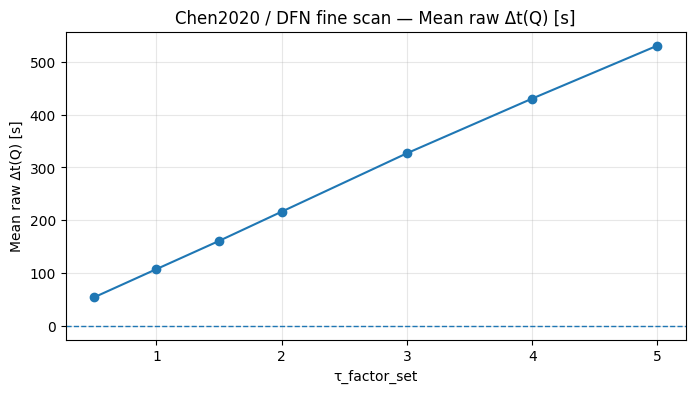

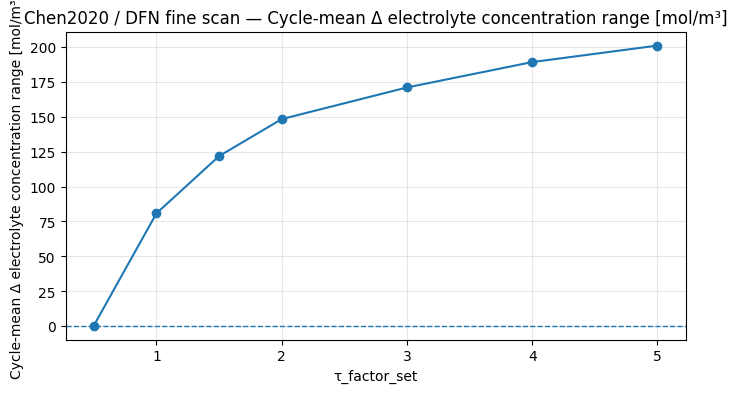

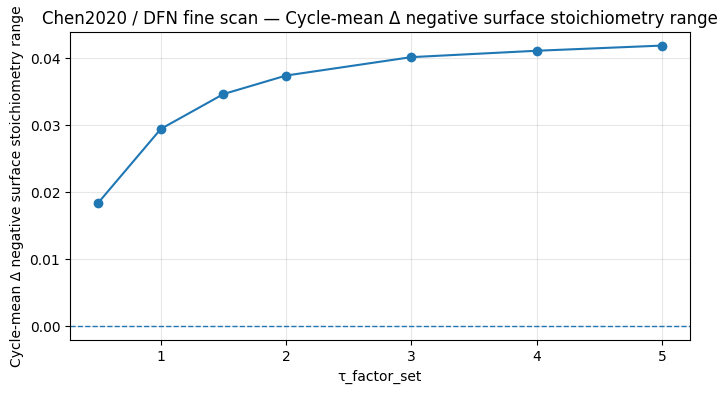

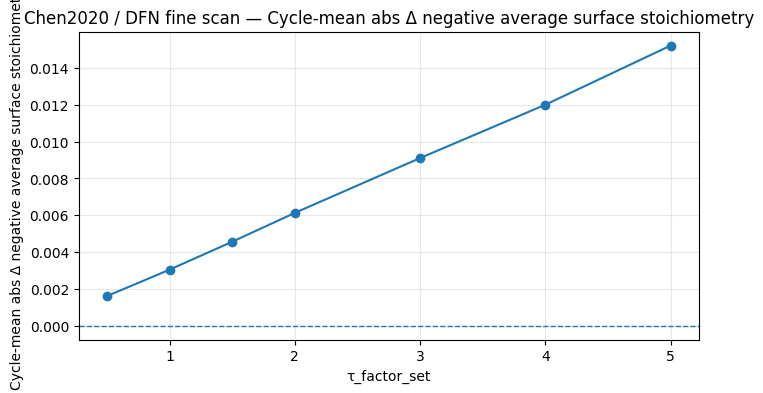

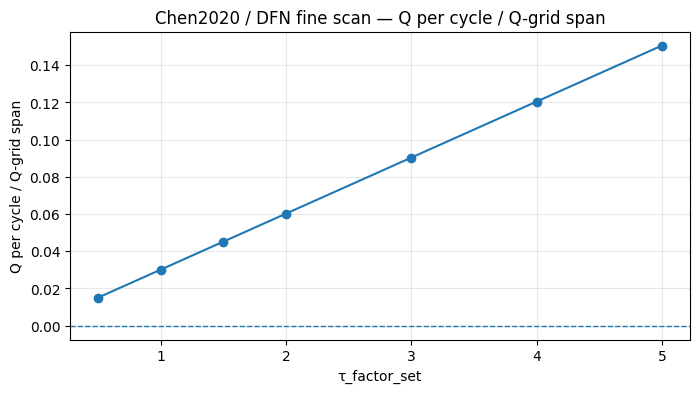

In [41]:
# Cell 34 — Plot fine-scan frequency-response trends（绘制精细频率响应趋势）

PLOT_VERDICT_COLS = [
    ("delta_t_raw_mean_s", "Mean raw Δt(Q) [s]"),
    ("delta_x_cycle_mean__elyte_c_range", "Cycle-mean Δ electrolyte concentration range [mol/m³]"),
    ("delta_x_cycle_mean__neg_surface_sto_range", "Cycle-mean Δ negative surface stoichiometry range"),
    ("delta_x_cycle_abs_mean__neg_avg_surface_sto", "Cycle-mean abs Δ negative average surface stoichiometry"),
    ("q_per_cycle_over_Qgrid_span", "Q per cycle / Q-grid span"),
]

plot_df = fine_integrated_verdict_df.sort_values("tau_factor_set").copy()

for col, ylabel in PLOT_VERDICT_COLS:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(plot_df["tau_factor_set"], plot_df[col], marker="o")
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("τ_factor_set")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Chen2020 / DFN fine scan — {ylabel}")
    ax.grid(True, alpha=0.3)
    plt.show()

In [42]:
# Cell 35 — Fine-scan response efficiency and saturation audit（精细扫描响应效率与饱和审计）

fine_window_score_df = fine_integrated_verdict_df.copy()

# Short aliases
fine_window_score_df["elyte_response"] = fine_window_score_df["delta_x_cycle_mean__elyte_c_range"]
fine_window_score_df["neg_gradient_response"] = fine_window_score_df["delta_x_cycle_mean__neg_surface_sto_range"]
fine_window_score_df["surface_shift_abs"] = fine_window_score_df["delta_x_cycle_abs_mean__neg_avg_surface_sto"]
fine_window_score_df["q_nonlocality"] = fine_window_score_df["q_per_cycle_over_Qgrid_span"]

def minmax_norm(s):
    s = pd.to_numeric(s, errors="coerce")
    lo, hi = np.nanmin(s), np.nanmax(s)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)

# Observability: can we see a cycle-mean microstate response?
fine_window_score_df["elyte_response_norm"] = minmax_norm(fine_window_score_df["elyte_response"])
fine_window_score_df["neg_gradient_response_norm"] = minmax_norm(fine_window_score_df["neg_gradient_response"])

fine_window_score_df["microstate_observability_score"] = (
    0.5 * fine_window_score_df["elyte_response_norm"]
    + 0.5 * fine_window_score_df["neg_gradient_response_norm"]
)

# Locality penalty: larger Q per cycle makes the cycle-window comparison less local in Q.
# Threshold is deliberately conservative.
Q_NONLOCALITY_SOFT_LIMIT = 0.12
fine_window_score_df["q_locality_score"] = (
    1.0 - fine_window_score_df["q_nonlocality"] / Q_NONLOCALITY_SOFT_LIMIT
).clip(lower=0.0, upper=1.0)

# Cycle-count adequacy: below ~8 cycles in the window is increasingly boundary-sensitive.
fine_window_score_df["cycle_count_score"] = (
    fine_window_score_df["cycle_count_span"] / 8.0
).clip(lower=0.0, upper=1.0)

# Balanced diagnostic score: high response, sufficient cycles, acceptable locality.
fine_window_score_df["balanced_window_score"] = (
    fine_window_score_df["microstate_observability_score"]
    * fine_window_score_df["q_locality_score"]
    * fine_window_score_df["cycle_count_score"]
    * fine_window_score_df["window_valid_fraction_mean"]
)

# Incremental response: detect saturation
fine_window_score_df = fine_window_score_df.sort_values("tau_factor_set").reset_index(drop=True)
fine_window_score_df["d_elyte_response_d_tau"] = fine_window_score_df["elyte_response"].diff() / fine_window_score_df["tau_factor_set"].diff()
fine_window_score_df["d_neg_gradient_d_tau"] = fine_window_score_df["neg_gradient_response"].diff() / fine_window_score_df["tau_factor_set"].diff()
fine_window_score_df["d_raw_dt_d_tau"] = fine_window_score_df["delta_t_raw_mean_s"].diff() / fine_window_score_df["tau_factor_set"].diff()

out = DATA_DIR / "day30_fine_scan_window_efficiency_saturation_audit.csv"
fine_window_score_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "condition",
    "tau_factor_set",
    "omega_tau_set",
    "delta_t_raw_mean_s",
    "elyte_response",
    "neg_gradient_response",
    "surface_shift_abs",
    "q_nonlocality",
    "cycle_count_span",
    "microstate_observability_score",
    "q_locality_score",
    "cycle_count_score",
    "balanced_window_score",
    "d_elyte_response_d_tau",
    "d_neg_gradient_d_tau",
    "integrated_frequency_response_class",
]

display(fine_window_score_df[cols])

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_window_efficiency_saturation_audit.csv


,condition,tau_factor_set,omega_tau_set,delta_t_raw_mean_s,elyte_response,neg_gradient_response,surface_shift_abs,q_nonlocality,cycle_count_span,microstate_observability_score,q_locality_score,cycle_count_score,balanced_window_score,d_elyte_response_d_tau,d_neg_gradient_d_tau,integrated_frequency_response_class
0,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,0.5,2.000000,53.400987,0.423622,0.018358,0.001604,0.015052,66.786992,0.000000,0.874563,1.000000,0.000000,NaN,NaN,transition_filtered_to_response
1,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,1.0,1.000000,107.087490,80.847004,0.029411,0.003041,0.030105,33.742306,0.435455,0.749127,1.000000,0.326211,160.846763,0.022106,candidate_microstate_response_window
2,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,1.5,0.666667,160.605097,121.855098,0.034623,0.004557,0.045157,22.044816,0.648466,0.623690,1.000000,0.404442,82.016188,0.010423,candidate_microstate_response_window
3,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,2.0,0.500000,216.038679,148.368507,0.037393,0.006127,0.060210,16.870001,0.773446,0.498253,1.000000,0.385372,53.026819,0.005540,candidate_microstate_response_window
4,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,3.0,0.333333,326.822701,171.038126,0.040146,0.009107,0.090314,11.022119,0.888478,0.247380,1.000000,0.217044,22.669619,0.002753,candidate_microstate_response_window
5,Chen2020_DFN_fine_DC03_AC07_4p0tauSet,4.0,0.250000,430.496924,189.229959,0.041099,0.012006,0.120419,8.092596,0.954081,0.000000,1.000000,0.000000,18.191833,0.000953,mixed_or_unresolved
6,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,5.0,0.200000,530.993396,201.048248,0.041873,0.015221,0.150524,6.208055,1.000000,0.000000,0.776007,0.000000,11.818289,0.000774,mixed_or_unresolved


In [43]:
# Cell 36 — Select candidate normalized-frequency window（选择候选归一化频率窗口）

# Conservative selection logic:
# - exclude too-fast filtered
# - exclude too-nonlocal points
# - require clear cycle-mean electrolyte + negative-surface gradient response

candidate_df = fine_window_score_df.copy()

candidate_df["passes_response_threshold"] = (
    (candidate_df["elyte_response"] > 80.0)
    & (candidate_df["neg_gradient_response"] > 0.025)
)

candidate_df["passes_locality_threshold"] = (
    candidate_df["q_nonlocality"] <= 0.10
)

candidate_df["passes_cycle_threshold"] = (
    candidate_df["cycle_count_span"] >= 8.0
)

candidate_df["candidate_window_flag"] = (
    candidate_df["passes_response_threshold"]
    & candidate_df["passes_locality_threshold"]
    & candidate_df["passes_cycle_threshold"]
)

candidate_window_df = candidate_df[
    candidate_df["candidate_window_flag"]
].copy()

out = DATA_DIR / "day30_fine_scan_candidate_window_selection.csv"
candidate_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    candidate_df[
        [
            "condition",
            "tau_factor_set",
            "omega_tau_set",
            "elyte_response",
            "neg_gradient_response",
            "q_nonlocality",
            "cycle_count_span",
            "passes_response_threshold",
            "passes_locality_threshold",
            "passes_cycle_threshold",
            "candidate_window_flag",
            "balanced_window_score",
        ]
    ].sort_values("tau_factor_set")
)

print("\n[SELECTED candidate window]")
display(
    candidate_window_df[
        [
            "condition",
            "tau_factor_set",
            "omega_tau_set",
            "balanced_window_score",
            "elyte_response",
            "neg_gradient_response",
            "q_nonlocality",
            "cycle_count_span",
        ]
    ].sort_values("tau_factor_set")
)

if not candidate_window_df.empty:
    print(
        "[VERDICT] Candidate tau_factor_set window:",
        f"{candidate_window_df['tau_factor_set'].min():.2f}",
        "to",
        f"{candidate_window_df['tau_factor_set'].max():.2f}",
    )
else:
    print("[VERDICT] No candidate window selected under current thresholds.")

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_fine_scan_candidate_window_selection.csv


,condition,tau_factor_set,omega_tau_set,elyte_response,neg_gradient_response,q_nonlocality,cycle_count_span,passes_response_threshold,passes_locality_threshold,passes_cycle_threshold,candidate_window_flag,balanced_window_score
0,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,0.5,2.000000,0.423622,0.018358,0.015052,66.786992,False,True,True,False,0.000000
1,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,1.0,1.000000,80.847004,0.029411,0.030105,33.742306,True,True,True,True,0.326211
2,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,1.5,0.666667,121.855098,0.034623,0.045157,22.044816,True,True,True,True,0.404442
3,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,2.0,0.500000,148.368507,0.037393,0.060210,16.870001,True,True,True,True,0.385372
4,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,3.0,0.333333,171.038126,0.040146,0.090314,11.022119,True,True,True,True,0.217044
5,Chen2020_DFN_fine_DC03_AC07_4p0tauSet,4.0,0.250000,189.229959,0.041099,0.120419,8.092596,True,False,True,False,0.000000
6,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,5.0,0.200000,201.048248,0.041873,0.150524,6.208055,True,False,False,False,0.000000



[SELECTED candidate window]


,condition,tau_factor_set,omega_tau_set,balanced_window_score,elyte_response,neg_gradient_response,q_nonlocality,cycle_count_span
1,Chen2020_DFN_fine_DC03_AC07_1p0tauSet,1.0,1.000000,0.326211,80.847004,0.029411,0.030105,33.742306
2,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,1.5,0.666667,0.404442,121.855098,0.034623,0.045157,22.044816
3,Chen2020_DFN_fine_DC03_AC07_2p0tauSet,2.0,0.500000,0.385372,148.368507,0.037393,0.060210,16.870001
4,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,3.0,0.333333,0.217044,171.038126,0.040146,0.090314,11.022119


[VERDICT] Candidate tau_factor_set window: 1.00 to 3.00


## Fine-scan interpretation

The Chen2020 / DFN fine scan identifies a normalized-frequency response window rather than a single optimal frequency.

The raw first-passage time gain increases monotonically with τ_factor_set, but this trend alone is not sufficient evidence for a beneficial microstate mechanism because the current-geometry contribution and voltage-boundary effects also increase with lower frequency.

The cycle-window audit shows that electrolyte concentration-gradient response and negative surface-stoichiometry-gradient response become clearly visible around 1τ_set and strengthen strongly between 1τ_set and 3τ_set. Beyond approximately 3τ_set, the responses continue to grow, but the comparison becomes increasingly nonlocal because the net charge advanced within one AC cycle occupies a larger fraction of the evaluated Q-window.

The cleanest candidate region for microstate observability in Chen2020 / DFN is therefore around 1.5–3τ_set. This region provides a measurable cycle-averaged microstate response while retaining enough cycles and acceptable Q-locality.

The result should not be interpreted as proof that DC–AC improves lithium intercalation. The dominant observed signature is not bulk-average lithiation acceleration, but electrolyte-gradient and particle-surface-gradient restructuring under dynamic excitation.

## Section C — Model-hierarchy audit for the normalized frequency window

The Chen2020 / DFN fine scan identified a candidate normalized-frequency window around 1–3τ_set, with the strongest balance near 1.5–2τ_set. This section tests whether the observed microstate response depends on model hierarchy.

The comparison uses Chen2020 only and evaluates:

- DFN
- SPMe
- SPM

Representative frequency points:

- 0.5τ_set: fast-side filtered control
- 1.5τ_set: balanced candidate window
- 3.0τ_set: upper candidate / strong response
- 5.0τ_set: slow-side nonlocal boundary

Interpretation logic:

- If DFN and SPMe show the response but SPM does not, electrolyte / transport effects are likely important.
- If only DFN shows the response, through-plane spatial gradients are likely central.
- If SPM also shows comparable response, solid-particle dynamics or OCV nonlinearity may be sufficient.
- Unsupported variables in simpler models are treated as not_applicable rather than failed.

In [44]:
# Cell 37 — Define Chen2020 model-hierarchy protocols（定义Chen2020模型层级协议）

HIERARCHY_PARAMETER_SET = "Chen2020"
HIERARCHY_MODEL_TYPES = ["DFN", "SPMe", "SPM"]
HIERARCHY_TAU_FACTORS = [0.5, 1.5, 3.0, 5.0]

HIERARCHY_TAU_REF_S = float(
    tau_ref_df.loc[
        tau_ref_df["parameter_set"] == HIERARCHY_PARAMETER_SET,
        "tau_ref_set_s"
    ].iloc[0]
)

hierarchy_rows = []

for model_type in HIERARCHY_MODEL_TYPES:
    hierarchy_rows.append({
        "parameter_set": HIERARCHY_PARAMETER_SET,
        "model_type": model_type,
        "condition": f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03",
        "base_condition": "DC03",
        "dc_c": DC_C,
        "ac_c": 0.0,
        "frequency_label": "DC",
        "tau_factor_set": np.nan,
        "tau_ref_set_s": HIERARCHY_TAU_REF_S,
        "f_Hz": np.nan,
        "period_s": np.nan,
        "omega_tau_set": np.nan,
        "kappa": 0.0,
    })
    
    for tau_factor in HIERARCHY_TAU_FACTORS:
        f_hz = 1.0 / (2.0 * np.pi * tau_factor * HIERARCHY_TAU_REF_S)
        period_s = 1.0 / f_hz
        label = label_from_tau_factor_set(tau_factor)
        
        hierarchy_rows.append({
            "parameter_set": HIERARCHY_PARAMETER_SET,
            "model_type": model_type,
            "condition": f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03_AC07_{label}",
            "base_condition": f"DC03_AC07_{label}",
            "dc_c": DC_C,
            "ac_c": AC_C,
            "frequency_label": label,
            "tau_factor_set": tau_factor,
            "tau_ref_set_s": HIERARCHY_TAU_REF_S,
            "f_Hz": f_hz,
            "period_s": period_s,
            "omega_tau_set": 1.0 / tau_factor,
            "kappa": AC_C / DC_C,
        })

hierarchy_protocol_df = pd.DataFrame(hierarchy_rows)

out = DATA_DIR / "day30_hierarchy_chen2020_protocol_table.csv"
hierarchy_protocol_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(hierarchy_protocol_df)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_chen2020_protocol_table.csv


,parameter_set,model_type,condition,base_condition,dc_c,ac_c,frequency_label,tau_factor_set,tau_ref_set_s,f_Hz,period_s,omega_tau_set,kappa
0,Chen2020,DFN,Chen2020_DFN_hier_DC03,DC03,0.3,0.0,DC,NaN,36.316532,NaN,NaN,NaN,0.000000
1,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,DC03_AC07_0p5tauSet,0.3,0.7,0p5tauSet,0.5,36.316532,0.008765,114.091751,2.000000,2.333333
2,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,DC03_AC07_1p5tauSet,0.3,0.7,1p5tauSet,1.5,36.316532,0.002922,342.275253,0.666667,2.333333
3,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_3p0tauSet,DC03_AC07_3p0tauSet,0.3,0.7,3p0tauSet,3.0,36.316532,0.001461,684.550505,0.333333,2.333333
4,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_5p0tauSet,DC03_AC07_5p0tauSet,0.3,0.7,5p0tauSet,5.0,36.316532,0.000876,1140.917509,0.200000,2.333333
5,Chen2020,SPMe,Chen2020_SPMe_hier_DC03,DC03,0.3,0.0,DC,NaN,36.316532,NaN,NaN,NaN,0.000000
6,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_0p5tauSet,DC03_AC07_0p5tauSet,0.3,0.7,0p5tauSet,0.5,36.316532,0.008765,114.091751,2.000000,2.333333
7,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_1p5tauSet,DC03_AC07_1p5tauSet,0.3,0.7,1p5tauSet,1.5,36.316532,0.002922,342.275253,0.666667,2.333333
8,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_3p0tauSet,DC03_AC07_3p0tauSet,0.3,0.7,3p0tauSet,3.0,36.316532,0.001461,684.550505,0.333333,2.333333
9,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,DC03_AC07_5p0tauSet,0.3,0.7,5p0tauSet,5.0,36.316532,0.000876,1140.917509,0.200000,2.333333


In [45]:
# Cell 38 — Run Chen2020 model-hierarchy simulations（运行Chen2020模型层级仿真）

hierarchy_solutions = {}
hierarchy_run_rows = []

def fine_scan_condition_for_tau(tau_factor):
    return f"Chen2020_DFN_fine_DC03_AC07_{label_from_tau_factor_set(tau_factor)}"

for _, row in hierarchy_protocol_df.iterrows():
    cond = row["condition"]
    model_type = row["model_type"]
    
    # Reuse DFN fine-scan results when possible
    if model_type == "DFN":
        if row["ac_c"] == 0:
            source_cond = "Chen2020_DFN_fine_DC03"
        else:
            source_cond = fine_scan_condition_for_tau(float(row["tau_factor_set"]))
        
        if source_cond in fine_scan_solutions:
            print(f"[REUSE] {cond} <- {source_cond}")
            hierarchy_solutions[cond] = fine_scan_solutions[source_cond]
            ts = hierarchy_solutions[cond]["ts"]
            
            hierarchy_run_rows.append({
                "parameter_set": HIERARCHY_PARAMETER_SET,
                "model_type": model_type,
                "condition": cond,
                "status": "ok_reused",
                "source_condition": source_cond,
                "termination": str(hierarchy_solutions[cond]["sol"].termination),
                "t_end_s": float(ts["t_s"].iloc[-1]),
                "t_end_min": float(ts["t_s"].iloc[-1] / 60),
                "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
                "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
                "I_charge_min_A": float(ts["I_charge_A"].min()),
                "I_charge_max_A": float(ts["I_charge_A"].max()),
                "tau_factor_set": row["tau_factor_set"],
                "f_Hz": row["f_Hz"],
                "period_s": row["period_s"],
                "error": "",
            })
            continue
    
    print(f"\n[RUN] {HIERARCHY_PARAMETER_SET} / {model_type} / {cond}")
    
    try:
        sim, sol, meta = run_simulation(
            parameter_set=HIERARCHY_PARAMETER_SET,
            model_type=model_type,
            protocol_row=row.to_dict(),
            initial_soc=0.05,
            max_time_s=24000,
            n_eval=5000,
        )
        ts = extract_solution_timeseries(sol)
        hierarchy_solutions[cond] = {
            "sim": sim,
            "sol": sol,
            "meta": meta,
            "ts": ts,
        }
        
        hierarchy_run_rows.append({
            "parameter_set": HIERARCHY_PARAMETER_SET,
            "model_type": model_type,
            "condition": cond,
            "status": "ok",
            "source_condition": "",
            "termination": str(sol.termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "error": "",
        })
        print("[OK]", cond, "| termination:", sol.termination)
    
    except Exception as e:
        hierarchy_run_rows.append({
            "parameter_set": HIERARCHY_PARAMETER_SET,
            "model_type": model_type,
            "condition": cond,
            "status": "failed",
            "source_condition": "",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "tau_factor_set": row["tau_factor_set"],
            "f_Hz": row["f_Hz"],
            "period_s": row["period_s"],
            "error": repr(e),
        })
        print("[FAILED]", cond, repr(e))

hierarchy_run_df = pd.DataFrame(hierarchy_run_rows)

out = DATA_DIR / "day30_hierarchy_chen2020_run_summary.csv"
hierarchy_run_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(hierarchy_run_df)

[REUSE] Chen2020_DFN_hier_DC03 <- Chen2020_DFN_fine_DC03
[REUSE] Chen2020_DFN_hier_DC03_AC07_0p5tauSet <- Chen2020_DFN_fine_DC03_AC07_0p5tauSet
[REUSE] Chen2020_DFN_hier_DC03_AC07_1p5tauSet <- Chen2020_DFN_fine_DC03_AC07_1p5tauSet
[REUSE] Chen2020_DFN_hier_DC03_AC07_3p0tauSet <- Chen2020_DFN_fine_DC03_AC07_3p0tauSet
[REUSE] Chen2020_DFN_hier_DC03_AC07_5p0tauSet <- Chen2020_DFN_fine_DC03_AC07_5p0tauSet

[RUN] Chen2020 / SPMe / Chen2020_SPMe_hier_DC03
[OK] Chen2020_SPMe_hier_DC03 | termination: event: Maximum voltage [V]

[RUN] Chen2020 / SPMe / Chen2020_SPMe_hier_DC03_AC07_0p5tauSet
[OK] Chen2020_SPMe_hier_DC03_AC07_0p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / SPMe / Chen2020_SPMe_hier_DC03_AC07_1p5tauSet
[OK] Chen2020_SPMe_hier_DC03_AC07_1p5tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / SPMe / Chen2020_SPMe_hier_DC03_AC07_3p0tauSet
[OK] Chen2020_SPMe_hier_DC03_AC07_3p0tauSet | termination: event: Maximum voltage [V]

[RUN] Chen2020 / SPMe / 

,parameter_set,model_type,condition,status,source_condition,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,tau_factor_set,f_Hz,period_s,error
0,Chen2020,DFN,Chen2020_DFN_hier_DC03,ok_reused,Chen2020_DFN_fine_DC03,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.5,NaN,NaN,NaN,
1,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,ok_reused,Chen2020_DFN_fine_DC03_AC07_0p5tauSet,event: Maximum voltage [V],8816.441612,146.940694,3.693538,4.2,-2.000000,5.0,0.5,0.008765,114.091751,
2,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,ok_reused,Chen2020_DFN_fine_DC03_AC07_1p5tauSet,event: Maximum voltage [V],8627.912611,143.798544,3.633942,4.2,-2.000000,5.0,1.5,0.002922,342.275253,
3,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_3p0tauSet,ok_reused,Chen2020_DFN_fine_DC03_AC07_3p0tauSet,event: Maximum voltage [V],8356.422363,139.273706,3.559599,4.2,-2.000000,5.0,3.0,0.001461,684.550505,
4,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_5p0tauSet,ok_reused,Chen2020_DFN_fine_DC03_AC07_5p0tauSet,event: Maximum voltage [V],8207.258608,136.787643,3.534928,4.2,-1.999999,5.0,5.0,0.000876,1140.917509,
5,Chen2020,SPMe,Chen2020_SPMe_hier_DC03,ok,,event: Maximum voltage [V],10788.186855,179.803114,4.495078,4.2,1.500000,1.5,NaN,NaN,NaN,
6,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_0p5tauSet,ok,,event: Maximum voltage [V],8814.190389,146.903173,3.690835,4.2,-2.000000,5.0,0.5,0.008765,114.091751,
7,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_1p5tauSet,ok,,event: Maximum voltage [V],8307.704232,138.461737,3.521801,4.2,-2.000000,5.0,1.5,0.002922,342.275253,
8,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_3p0tauSet,ok,,event: Maximum voltage [V],8349.702893,139.161715,3.550562,4.2,-2.000000,5.0,3.0,0.001461,684.550505,
9,Chen2020,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,ok,,event: Maximum voltage [V],8198.409098,136.640152,3.523249,4.2,-2.000000,5.0,5.0,0.000876,1140.917509,


In [46]:
# Cell 39 — Resolve microstate registry per model hierarchy（按模型层级解析微观变量注册表）

hierarchy_registry_rows = []

for model_type in HIERARCHY_MODEL_TYPES:
    # Use model-specific DC condition as representative
    rep_cond = f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03"
    rep_sim = hierarchy_solutions[rep_cond]["sim"]
    
    for spec in MICROSTATE_REGISTRY_SPEC:
        key = resolve_variable_key(
            rep_sim,
            candidates=spec.get("candidates", []),
            contains_all=spec.get("contains_all", []),
            verbose=False,
        )
        hierarchy_registry_rows.append({
            "parameter_set": HIERARCHY_PARAMETER_SET,
            "model_type": model_type,
            "feature_id": spec["feature_id"],
            "layer": spec["layer"],
            "reducer": spec["reducer"],
            "variable_key": key,
            "resolved": key is not None,
            "interpretation": spec["interpretation"],
        })

hierarchy_registry_df = pd.DataFrame(hierarchy_registry_rows)

out = DATA_DIR / "day30_hierarchy_microstate_registry.csv"
hierarchy_registry_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(hierarchy_registry_df)

print("\n[UNRESOLVED by model]")
display(
    hierarchy_registry_df[~hierarchy_registry_df["resolved"]]
    .sort_values(["model_type", "feature_id"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_microstate_registry.csv


,parameter_set,model_type,feature_id,layer,reducer,variable_key,resolved,interpretation
0,Chen2020,DFN,neg_avg_sto,negative_solid,mean,Average negative particle stoichiometry,True,Average negative solid lithiation state
1,Chen2020,DFN,neg_avg_surface_sto,negative_solid,mean,X-averaged negative particle surface stoichiom...,True,Average negative particle surface lithiation s...
2,Chen2020,DFN,neg_max_surface_sto,negative_solid,mean,Maximum negative particle surface stoichiometry,True,Maximum negative surface stoichiometry; satura...
3,Chen2020,DFN,neg_min_surface_sto,negative_solid,mean,Minimum negative particle surface stoichiometry,True,Minimum negative surface stoichiometry; spatia...
4,Chen2020,DFN,pos_avg_sto,positive_solid,mean,Average positive particle stoichiometry,True,Average positive solid delithiation state
5,Chen2020,DFN,pos_avg_surface_sto,positive_solid,mean,X-averaged positive particle surface stoichiom...,True,Average positive particle surface stoichiometry
6,Chen2020,DFN,elyte_c_mean,electrolyte,mean,X-averaged electrolyte concentration [mol.m-3],True,Mean electrolyte concentration
7,Chen2020,DFN,elyte_c_range,electrolyte,range,Electrolyte concentration [mol.m-3],True,Spatial electrolyte concentration gradient proxy
8,Chen2020,DFN,eta_n_mean,kinetics,mean,X-averaged negative electrode reaction overpot...,True,Negative electrode reaction overpotential
9,Chen2020,DFN,eta_p_mean,kinetics,mean,X-averaged positive electrode reaction overpot...,True,Positive electrode reaction overpotential



[UNRESOLVED by model]


,parameter_set,model_type,feature_id,layer,reducer,variable_key,resolved,interpretation


In [47]:
# Cell 40 — Extract microstate timeseries for model hierarchy（提取模型层级微观状态时间序列）

hierarchy_micro_ts_by_condition = {}
hierarchy_extraction_rows = []

for cond, obj in hierarchy_solutions.items():
    row = hierarchy_protocol_df.loc[hierarchy_protocol_df["condition"] == cond].iloc[0]
    model_type = row["model_type"]
    
    registry_model_df = hierarchy_registry_df[
        hierarchy_registry_df["model_type"] == model_type
    ].copy()
    
    print(f"[EXTRACT] {cond}")
    micro_ts, audit = extract_microstate_timeseries(
        obj["sol"],
        registry_model_df,
    )
    hierarchy_micro_ts_by_condition[cond] = micro_ts
    
    audit.insert(0, "condition", cond)
    audit.insert(0, "model_type", model_type)
    hierarchy_extraction_rows.append(audit)

hierarchy_extraction_audit_df = pd.concat(hierarchy_extraction_rows, ignore_index=True)

out = DATA_DIR / "day30_hierarchy_microstate_extraction_audit.csv"
hierarchy_extraction_audit_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(hierarchy_extraction_audit_df)

if (hierarchy_extraction_audit_df["status"] == "failed").any():
    print("[WARN] failed extractions:")
    display(hierarchy_extraction_audit_df[hierarchy_extraction_audit_df["status"] == "failed"])

[EXTRACT] Chen2020_DFN_hier_DC03
[EXTRACT] Chen2020_DFN_hier_DC03_AC07_0p5tauSet
[EXTRACT] Chen2020_DFN_hier_DC03_AC07_1p5tauSet
[EXTRACT] Chen2020_DFN_hier_DC03_AC07_3p0tauSet
[EXTRACT] Chen2020_DFN_hier_DC03_AC07_5p0tauSet
[EXTRACT] Chen2020_SPMe_hier_DC03
[EXTRACT] Chen2020_SPMe_hier_DC03_AC07_0p5tauSet
[EXTRACT] Chen2020_SPMe_hier_DC03_AC07_1p5tauSet
[EXTRACT] Chen2020_SPMe_hier_DC03_AC07_3p0tauSet
[EXTRACT] Chen2020_SPMe_hier_DC03_AC07_5p0tauSet
[EXTRACT] Chen2020_SPM_hier_DC03
[EXTRACT] Chen2020_SPM_hier_DC03_AC07_0p5tauSet
[EXTRACT] Chen2020_SPM_hier_DC03_AC07_1p5tauSet
[EXTRACT] Chen2020_SPM_hier_DC03_AC07_3p0tauSet
[EXTRACT] Chen2020_SPM_hier_DC03_AC07_5p0tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_microstate_extraction_audit.csv


,model_type,condition,feature_id,variable_key,status,shape,error
0,DFN,Chen2020_DFN_hier_DC03,neg_avg_sto,Average negative particle stoichiometry,ok,"(12159,)",
1,DFN,Chen2020_DFN_hier_DC03,neg_avg_surface_sto,X-averaged negative particle surface stoichiom...,ok,"(12159,)",
2,DFN,Chen2020_DFN_hier_DC03,neg_max_surface_sto,Maximum negative particle surface stoichiometry,ok,"(12159,)",
3,DFN,Chen2020_DFN_hier_DC03,neg_min_surface_sto,Minimum negative particle surface stoichiometry,ok,"(12159,)",
4,DFN,Chen2020_DFN_hier_DC03,pos_avg_sto,Average positive particle stoichiometry,ok,"(12159,)",
...,...,...,...,...,...,...,...
205,SPM,Chen2020_SPM_hier_DC03_AC07_5p0tauSet,eta_p_mean,X-averaged positive electrode reaction overpot...,ok,"(11763,)",
206,SPM,Chen2020_SPM_hier_DC03_AC07_5p0tauSet,j_n_rms,X-averaged negative electrode interfacial curr...,ok,"(11763,)",
207,SPM,Chen2020_SPM_hier_DC03_AC07_5p0tauSet,j_p_rms,X-averaged positive electrode interfacial curr...,ok,"(11763,)",
208,SPM,Chen2020_SPM_hier_DC03_AC07_5p0tauSet,cell_temperature_K,X-averaged cell temperature [K],ok,"(11763,)",


In [48]:
# Cell 41 — Equal-Q microstate deltas across model hierarchy（模型层级等Q微观状态差异）

hierarchy_equal_q_tables = {}
hierarchy_delta_records = []
hierarchy_q_grid_meta = []

for model_type in HIERARCHY_MODEL_TYPES:
    model_conditions = hierarchy_protocol_df[
        hierarchy_protocol_df["model_type"] == model_type
    ]["condition"].tolist()
    
    model_ts_map = {
        cond: hierarchy_micro_ts_by_condition[cond]
        for cond in model_conditions
    }
    
    q_grid_model, q_end_by_cond, q_hi_raw, q_hi = build_common_q_grid(
        model_ts_map,
        q_lo_Ah=0.2,
        q_hi_fraction=0.95,
        n_grid=80,
    )
    
    hierarchy_q_grid_meta.append({
        "model_type": model_type,
        "q_lo_Ah": float(q_grid_model[0]),
        "q_hi_Ah": float(q_grid_model[-1]),
        "q_hi_raw_Ah": float(q_hi_raw),
        "n_grid": len(q_grid_model),
        "q_end_by_condition_json": json.dumps(q_end_by_cond),
    })
    
    print(f"\n[MODEL] {model_type}")
    print(f"Q grid: {q_grid_model[0]:.6f} → {q_grid_model[-1]:.6f} Ah")
    
    # Extract equal-Q tables
    for cond, ts in model_ts_map.items():
        eq = extract_equal_q_features(ts, q_grid_model, feature_cols)
        eq.insert(0, "condition", cond)
        eq.insert(1, "model_type", model_type)
        hierarchy_equal_q_tables[cond] = eq
    
    dc_cond = f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03"
    dc_eq = hierarchy_equal_q_tables[dc_cond].set_index("Q_Ah")
    
    for cond in model_conditions:
        if cond == dc_cond:
            continue
        
        ac_eq = hierarchy_equal_q_tables[cond].set_index("Q_Ah")
        meta = hierarchy_protocol_df.loc[
            hierarchy_protocol_df["condition"] == cond
        ].iloc[0].to_dict()
        
        for q in q_grid_model:
            q = float(q)
            t_dc = float(dc_eq.loc[q, "t_q_s"])
            t_ac = float(ac_eq.loc[q, "t_q_s"])
            delta_t_raw_s = t_dc - t_ac
            
            for feat in feature_cols:
                if feat not in dc_eq.columns or feat not in ac_eq.columns:
                    continue
                
                x_dc = float(dc_eq.loc[q, feat])
                x_ac = float(ac_eq.loc[q, feat])
                
                feature_out = {
                    "j_n_rms": "j_n_mean_signed",
                    "j_p_rms": "j_p_mean_signed",
                }.get(feat, feat)
                
                hierarchy_delta_records.append({
                    "parameter_set": HIERARCHY_PARAMETER_SET,
                    "model_type": model_type,
                    "condition": cond,
                    "reference_condition": dc_cond,
                    "Q_Ah": q,
                    "feature_id": feature_out,
                    "x_DC": x_dc,
                    "x_DCAC": x_ac,
                    "delta_x": x_ac - x_dc if np.isfinite(x_ac) and np.isfinite(x_dc) else np.nan,
                    "t_DC_s": t_dc,
                    "t_DCAC_s": t_ac,
                    "delta_t_raw_s": delta_t_raw_s,
                    "tau_factor_set": meta["tau_factor_set"],
                    "omega_tau_set": meta["omega_tau_set"],
                    "f_Hz": meta["f_Hz"],
                    "period_s": meta["period_s"],
                })

hierarchy_q_grid_meta_df = pd.DataFrame(hierarchy_q_grid_meta)
hierarchy_delta_long_df = pd.DataFrame(hierarchy_delta_records)

out = DATA_DIR / "day30_hierarchy_q_grid_meta.csv"
hierarchy_q_grid_meta_df.to_csv(out, index=False)
print("[OK] saved:", out)
display(hierarchy_q_grid_meta_df)

out = DATA_DIR / "day30_hierarchy_equalQ_microstate_delta_long.csv"
hierarchy_delta_long_df.to_csv(out, index=False)
print("[OK] saved:", out)
display(hierarchy_delta_long_df.head(20))

hierarchy_delta_summary_df = (
    hierarchy_delta_long_df
    .groupby(["model_type", "condition", "feature_id", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        delta_x_mean=("delta_x", "mean"),
        delta_x_abs_mean=("delta_x", lambda x: np.nanmean(np.abs(x))),
        delta_x_max_abs=("delta_x", lambda x: np.nanmax(np.abs(x))),
        delta_x_std=("delta_x", "std"),
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
    )
)

out = DATA_DIR / "day30_hierarchy_equalQ_microstate_delta_summary.csv"
hierarchy_delta_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    hierarchy_delta_summary_df[
        hierarchy_delta_summary_df["feature_id"].isin(KEY_FEATURES)
    ].sort_values(["model_type", "tau_factor_set", "feature_id"])
)


[MODEL] DFN
Q grid: 0.200000 → 3.358182 Ah

[MODEL] SPMe
Q grid: 0.200000 → 3.345711 Ah

[MODEL] SPM
Q grid: 0.200000 → 3.847206 Ah
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_q_grid_meta.csv


,model_type,q_lo_Ah,q_hi_Ah,q_hi_raw_Ah,n_grid,q_end_by_condition_json
0,DFN,0.2,3.358182,3.534928,80,"{""Chen2020_DFN_hier_DC03"": 4.4928790028035, ""C..."
1,SPMe,0.2,3.345711,3.521801,80,"{""Chen2020_SPMe_hier_DC03"": 4.495077856415553,..."
2,SPM,0.2,3.847206,4.049691,80,"{""Chen2020_SPM_hier_DC03"": 4.564888887621224, ..."


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_equalQ_microstate_delta_long.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,feature_id,x_DC,x_DCAC,delta_x,t_DC_s,t_DCAC_s,delta_t_raw_s,tau_factor_set,omega_tau_set,f_Hz,period_s
0,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_avg_sto,0.104879,0.104852,-0.000027,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
1,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_avg_surface_sto,0.109828,0.114324,0.004496,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
2,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_max_surface_sto,0.112828,0.119845,0.007017,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
3,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_min_surface_sto,0.108233,0.111494,0.003261,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
4,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,pos_avg_sto,0.801565,0.801583,0.000018,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
5,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,pos_avg_surface_sto,0.782653,0.773105,-0.009548,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
6,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,elyte_c_mean,983.128507,966.005434,-17.123073,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
7,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,elyte_c_range,351.368776,730.467560,379.098784,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
8,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,eta_n_mean,-0.049882,-0.067364,-0.017482,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751
9,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,eta_p_mean,0.004378,0.005828,0.001450,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_equalQ_microstate_delta_summary.csv


,model_type,condition,feature_id,tau_factor_set,omega_tau_set,delta_x_mean,delta_x_abs_mean,delta_x_max_abs,delta_x_std,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s
1,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,elyte_c_mean,0.5,2.0,-12.244343,12.366123,19.250700,6.115249,53.400987,15.308827,84.364680
2,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,elyte_c_range,0.5,2.0,248.086648,253.619835,412.174480,140.877386,53.400987,15.308827,84.364680
3,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,eta_n_mean,0.5,2.0,-0.042208,0.042555,0.055485,0.013442,53.400987,15.308827,84.364680
4,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,eta_p_mean,0.5,2.0,0.006333,0.006388,0.009235,0.002466,53.400987,15.308827,84.364680
5,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,j_n_mean_signed,0.5,2.0,-0.799052,0.804736,1.041757,0.296572,53.400987,15.308827,84.364680
...,...,...,...,...,...,...,...,...,...,...,...,...
196,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,neg_max_surface_sto,5.0,0.2,0.009020,0.009073,0.011242,0.002841,538.748189,156.764788,844.678024
198,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,neg_surface_minus_avg_sto,5.0,0.2,0.009019,0.009072,0.011238,0.002840,538.748189,156.764788,844.678024
199,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,neg_surface_sto_range,5.0,0.2,0.000000,0.000000,0.000000,0.000000,538.748189,156.764788,844.678024
201,SPMe,Chen2020_SPMe_hier_DC03_AC07_5p0tauSet,pos_avg_surface_sto,5.0,0.2,-0.025918,0.025918,0.032813,0.006596,538.748189,156.764788,844.678024


In [49]:
# Cell 42 — Model-hierarchy cycle-window summary（模型层级周期窗口摘要）

hierarchy_cycle_records = []

for model_type in HIERARCHY_MODEL_TYPES:
    model_conditions = hierarchy_protocol_df[
        hierarchy_protocol_df["model_type"] == model_type
    ]["condition"].tolist()
    
    dc_cond = f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03"
    
    # Use model-specific Q values from equal-Q tables
    q_values = hierarchy_equal_q_tables[dc_cond]["Q_Ah"].to_numpy()
    
    for cond in model_conditions:
        if cond == dc_cond:
            continue
        
        meta = hierarchy_protocol_df.loc[
            hierarchy_protocol_df["condition"] == cond
        ].iloc[0].to_dict()
        
        period_s = float(meta["period_s"])
        f_hz = float(meta["f_Hz"])
        half_width_s = 0.5 * period_s
        
        ts_ac = hierarchy_micro_ts_by_condition[cond]
        ts_dc = hierarchy_micro_ts_by_condition[dc_cond]
        eq_ac = hierarchy_equal_q_tables[cond].set_index("Q_Ah")
        eq_dc = hierarchy_equal_q_tables[dc_cond].set_index("Q_Ah")
        
        print("[CYCLE WINDOW]", model_type, cond)
        
        for q in q_values:
            q = float(q)
            t_ac = float(eq_ac.loc[q, "t_q_s"])
            t_dc = float(eq_dc.loc[q, "t_q_s"])
            phi = (2.0 * np.pi * f_hz * t_ac) % (2.0 * np.pi)
            
            for feat in feature_cols:
                if feat not in ts_ac.columns or feat not in ts_dc.columns:
                    continue
                
                ac_win = time_window_average(
                    ts_ac["t_s"].to_numpy(),
                    ts_ac[feat].to_numpy(),
                    t_ac,
                    half_width_s,
                )
                dc_win = time_window_average(
                    ts_dc["t_s"].to_numpy(),
                    ts_dc[feat].to_numpy(),
                    t_dc,
                    half_width_s,
                )
                
                x_ac_inst = float(eq_ac.loc[q, feat])
                x_dc_inst = float(eq_dc.loc[q, feat])
                
                window_valid = (
                    ac_win["valid"]
                    and dc_win["valid"]
                    and ac_win["covered_s"] >= 0.8 * period_s
                    and dc_win["covered_s"] >= 0.8 * period_s
                )
                
                feature_out = {
                    "j_n_rms": "j_n_mean_signed",
                    "j_p_rms": "j_p_mean_signed",
                }.get(feat, feat)
                
                hierarchy_cycle_records.append({
                    "parameter_set": HIERARCHY_PARAMETER_SET,
                    "model_type": model_type,
                    "condition": cond,
                    "reference_condition": dc_cond,
                    "feature_id": feature_out,
                    "Q_Ah": q,
                    "tau_factor_set": meta["tau_factor_set"],
                    "omega_tau_set": meta["omega_tau_set"],
                    "period_s": period_s,
                    "phase_norm": phi / (2.0 * np.pi),
                    "cycle_count": f_hz * t_ac,
                    "delta_x_inst": x_ac_inst - x_dc_inst,
                    "x_DCAC_cycle_mean": ac_win["mean"],
                    "x_DC_window_mean": dc_win["mean"],
                    "delta_x_cycle_mean": ac_win["mean"] - dc_win["mean"],
                    "x_DCAC_cycle_amp": ac_win["max"] - ac_win["min"],
                    "window_valid": window_valid,
                })

hierarchy_cycle_window_delta_df = pd.DataFrame(hierarchy_cycle_records)

out = DATA_DIR / "day30_hierarchy_cycle_window_delta_long.csv"
hierarchy_cycle_window_delta_df.to_csv(out, index=False)
print("[OK] saved:", out)

hierarchy_cycle_summary_df = (
    hierarchy_cycle_window_delta_df
    .groupby(["model_type", "condition", "feature_id", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        n_Q=("Q_Ah", "count"),
        window_valid_fraction=("window_valid", "mean"),
        delta_x_inst_mean=("delta_x_inst", "mean"),
        delta_x_inst_abs_mean=("delta_x_inst", lambda x: np.nanmean(np.abs(x))),
        delta_x_cycle_mean=("delta_x_cycle_mean", "mean"),
        delta_x_cycle_abs_mean=("delta_x_cycle_mean", lambda x: np.nanmean(np.abs(x))),
        cycle_amp_mean=("x_DCAC_cycle_amp", "mean"),
        cycle_amp_max=("x_DCAC_cycle_amp", "max"),
        cycle_count_min=("cycle_count", "min"),
        cycle_count_max=("cycle_count", "max"),
    )
)

out = DATA_DIR / "day30_hierarchy_cycle_window_delta_summary.csv"
hierarchy_cycle_summary_df.to_csv(out, index=False)
print("[OK] saved:", out)

display(
    hierarchy_cycle_summary_df[
        hierarchy_cycle_summary_df["feature_id"].isin(KEY_FEATURES_FOR_CYCLE)
    ].sort_values(["model_type", "tau_factor_set", "feature_id"])
)

[CYCLE WINDOW] DFN Chen2020_DFN_hier_DC03_AC07_0p5tauSet
[CYCLE WINDOW] DFN Chen2020_DFN_hier_DC03_AC07_1p5tauSet
[CYCLE WINDOW] DFN Chen2020_DFN_hier_DC03_AC07_3p0tauSet
[CYCLE WINDOW] DFN Chen2020_DFN_hier_DC03_AC07_5p0tauSet
[CYCLE WINDOW] SPMe Chen2020_SPMe_hier_DC03_AC07_0p5tauSet
[CYCLE WINDOW] SPMe Chen2020_SPMe_hier_DC03_AC07_1p5tauSet
[CYCLE WINDOW] SPMe Chen2020_SPMe_hier_DC03_AC07_3p0tauSet
[CYCLE WINDOW] SPMe Chen2020_SPMe_hier_DC03_AC07_5p0tauSet
[CYCLE WINDOW] SPM Chen2020_SPM_hier_DC03_AC07_0p5tauSet
[CYCLE WINDOW] SPM Chen2020_SPM_hier_DC03_AC07_1p5tauSet
[CYCLE WINDOW] SPM Chen2020_SPM_hier_DC03_AC07_3p0tauSet
[CYCLE WINDOW] SPM Chen2020_SPM_hier_DC03_AC07_5p0tauSet
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_cycle_window_delta_long.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_cycle_window_delta_summary.csv


,model_type,condition,feature_id,tau_factor_set,omega_tau_set,n_Q,window_valid_fraction,delta_x_inst_mean,delta_x_inst_abs_mean,delta_x_cycle_mean,delta_x_cycle_abs_mean,cycle_amp_mean,cycle_amp_max,cycle_count_min,cycle_count_max
2,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,elyte_c_range,0.5,2.000000,80,1.0000,248.086648,253.619835,0.423622,3.945089,738.507297,777.619747,3.471482,70.258474
3,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,eta_n_mean,0.5,2.000000,80,1.0000,-0.042208,0.042555,0.011791,0.011791,0.133737,0.167366,3.471482,70.258474
8,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,neg_avg_surface_sto,0.5,2.000000,80,1.0000,0.004833,0.004833,-0.001140,0.001604,0.020796,0.021120,3.471482,70.258474
12,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,neg_surface_sto_range,0.5,2.000000,80,1.0000,0.020384,0.020384,0.018358,0.018358,0.008712,0.012937,3.471482,70.258474
14,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,pos_avg_surface_sto,0.5,2.000000,80,1.0000,-0.007452,0.007473,0.000973,0.001189,0.028089,0.028728,3.471482,70.258474
19,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,elyte_c_range,1.5,0.666667,80,1.0000,526.739812,526.739812,121.855098,121.855098,995.621914,1045.871167,1.182933,23.227749
20,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,eta_n_mean,1.5,0.666667,80,1.0000,-0.044933,0.045544,0.008164,0.008164,0.135495,0.168545,1.182933,23.227749
25,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,neg_avg_surface_sto,1.5,0.666667,80,1.0000,0.007560,0.007560,-0.002622,0.004557,0.043563,0.044236,1.182933,23.227749
29,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,neg_surface_sto_range,1.5,0.666667,80,1.0000,0.040528,0.040528,0.034623,0.034623,0.023402,0.036486,1.182933,23.227749
31,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,pos_avg_surface_sto,1.5,0.666667,80,1.0000,-0.014398,0.014398,0.001961,0.003131,0.055663,0.057561,1.182933,23.227749


In [50]:
# Cell 43 — Model-hierarchy mechanism-localization summary（模型层级机制定位摘要）

HIERARCHY_LOCALIZATION_FEATURES = [
    "elyte_c_range",
    "neg_surface_sto_range",
    "neg_avg_surface_sto",
    "pos_avg_surface_sto",
    "eta_n_mean",
]

hierarchy_local_pivot = (
    hierarchy_cycle_summary_df[
        hierarchy_cycle_summary_df["feature_id"].isin(HIERARCHY_LOCALIZATION_FEATURES)
    ]
    .pivot_table(
        index=["model_type", "tau_factor_set", "omega_tau_set"],
        columns="feature_id",
        values="delta_x_cycle_mean",
        aggfunc="first",
    )
    .reset_index()
)

# Attach raw Δt
hierarchy_dt = (
    hierarchy_delta_summary_df
    .groupby(["model_type", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_mean_s", "first"),
        delta_t_raw_min_s=("delta_t_raw_min_s", "first"),
        delta_t_raw_max_s=("delta_t_raw_max_s", "first"),
    )
)

hierarchy_localization_df = hierarchy_dt.merge(
    hierarchy_local_pivot,
    on=["model_type", "tau_factor_set", "omega_tau_set"],
    how="left",
)

# Feature support table
support_table = (
    hierarchy_registry_df
    .pivot_table(
        index="model_type",
        columns="feature_id",
        values="resolved",
        aggfunc="first",
    )
    .reset_index()
)

out = DATA_DIR / "day30_hierarchy_mechanism_localization_summary.csv"
hierarchy_localization_df.to_csv(out, index=False)
print("[OK] saved:", out)

out = DATA_DIR / "day30_hierarchy_feature_support_table.csv"
support_table.to_csv(out, index=False)
print("[OK] saved:", out)

print("\n[feature support]")
display(support_table)

print("\n[mechanism localization summary]")
display(
    hierarchy_localization_df.sort_values(["tau_factor_set", "model_type"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_mechanism_localization_summary.csv
[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_feature_support_table.csv

[feature support]


feature_id,model_type,cell_temperature_K,elyte_c_mean,elyte_c_range,eta_n_mean,eta_p_mean,j_n_rms,j_p_rms,neg_avg_sto,neg_avg_surface_sto,neg_max_surface_sto,neg_min_surface_sto,pos_avg_sto,pos_avg_surface_sto,total_heating_mean
0,DFN,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,SPM,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,SPMe,True,True,True,True,True,True,True,True,True,True,True,True,True,True



[mechanism localization summary]


,model_type,tau_factor_set,omega_tau_set,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,elyte_c_range,eta_n_mean,neg_avg_surface_sto,neg_surface_sto_range,pos_avg_surface_sto
0,DFN,0.5,2.000000,53.400987,15.308827,84.364680,0.423622,0.011791,-0.001140,0.018358,0.000973
4,SPM,0.5,2.000000,55.933818,15.265546,84.611106,0.000000,0.007622,-0.000630,0.000000,0.000255
8,SPMe,0.5,2.000000,53.967826,16.077842,84.606522,16.935049,0.009033,-0.000696,0.000000,0.000414
1,DFN,1.5,0.666667,160.605097,49.247715,254.194220,121.855098,0.008164,-0.002622,0.034623,0.001961
5,SPM,1.5,0.666667,158.520875,48.820360,254.074814,0.000000,0.006464,-0.001188,0.000000,0.000093
9,SPMe,1.5,0.666667,161.939398,49.809713,254.162000,153.288249,0.005903,-0.002188,0.000000,0.001287
2,DFN,3.0,0.333333,326.822701,98.331652,508.416799,171.038126,0.005199,-0.004906,0.040146,0.003009
6,SPM,3.0,0.333333,319.481676,94.427067,508.036462,0.000000,0.004454,-0.003297,0.000000,0.000885
10,SPMe,3.0,0.333333,322.988520,96.894462,508.383226,198.002740,0.004207,-0.004122,0.000000,0.002255
3,DFN,5.0,0.200000,530.993396,157.496116,844.878438,201.048248,0.002344,-0.006017,0.041873,0.002652


## Section D — Geometry-residual decomposition for the hierarchy audit

The model-hierarchy audit showed that raw Δt(Q) is similar across DFN, SPMe, and SPM, whereas electrolyte-gradient and negative-surface spatial responses are model-hierarchy dependent.

This section decomposes raw state-equivalent time gain into:

- Δt_raw(Q): model-observed first-passage gain
- Δt_geom(Q): prescribed-current geometry contribution
- Δt_resid(Q): residual beyond current geometry

This step is required before interpreting any microstate response as a non-geometric mechanism.

In [51]:
# Cell 44 — Analytic geometry first-passage utilities（解析电流几何first-passage工具）

from scipy.optimize import brentq

def q_geom_charge_Ah(t_s, i_dc_A, i_ac_A=0.0, f_Hz=None):
    """
    Charge-positive prescribed-current geometry.

    I_charge(t) = I_DC + I_AC sin(2π f t)

    Q_geom(t) = I_DC*t/3600 + I_AC/(2πf*3600) * (1 - cos(2πft))

    For DC-only:
    Q_geom(t) = I_DC*t/3600
    """
    t_s = np.asarray(t_s, dtype=float)

    if i_ac_A == 0 or f_Hz is None or pd.isna(f_Hz):
        return i_dc_A * t_s / 3600.0

    omega = 2.0 * np.pi * f_Hz
    return (
        i_dc_A * t_s / 3600.0
        + i_ac_A / (omega * 3600.0) * (1.0 - np.cos(omega * t_s))
    )


def first_passage_geom_time_s(q_target_Ah, i_dc_A, i_ac_A=0.0, f_Hz=None, t_max_s=None):
    """
    First-passage time for prescribed current geometry.
    Works for non-monotonic Q(t) when I_AC > I_DC by explicitly locating the first crossing.
    """
    if q_target_Ah < 0:
        return np.nan

    if i_ac_A == 0 or f_Hz is None or pd.isna(f_Hz):
        return q_target_Ah * 3600.0 / i_dc_A

    period_s = 1.0 / f_Hz

    if t_max_s is None:
        # Conservative upper bound: DC time plus several periods
        t_max_s = q_target_Ah * 3600.0 / max(i_dc_A, 1e-12) + 5.0 * period_s

    # Resolution: enough points per cycle, capped for runtime.
    dt_s = min(period_s / 300.0, 2.0)
    dt_s = max(dt_s, 0.05)

    t_grid = np.arange(0.0, t_max_s + dt_s, dt_s)
    q_grid_geom = q_geom_charge_Ah(t_grid, i_dc_A, i_ac_A, f_Hz)

    hit = np.where(q_grid_geom >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan

    idx = int(hit[0])
    if idx == 0:
        return float(t_grid[0])

    t0, t1 = float(t_grid[idx - 1]), float(t_grid[idx])

    def root_fun(t):
        return float(q_geom_charge_Ah(np.array([t]), i_dc_A, i_ac_A, f_Hz)[0] - q_target_Ah)

    try:
        return float(brentq(root_fun, t0, t1, maxiter=100))
    except ValueError:
        # Fallback linear interpolation
        q0 = q_grid_geom[idx - 1]
        q1 = q_grid_geom[idx]
        if q1 == q0:
            return t1
        frac = (q_target_Ah - q0) / (q1 - q0)
        return float(t0 + frac * (t1 - t0))


def compute_geom_delta_for_condition(q_values_Ah, i_dc_A, i_ac_A, f_Hz):
    records = []

    for q in q_values_Ah:
        q = float(q)

        t_dc_geom = first_passage_geom_time_s(
            q_target_Ah=q,
            i_dc_A=i_dc_A,
            i_ac_A=0.0,
            f_Hz=None,
        )

        t_dcac_geom = first_passage_geom_time_s(
            q_target_Ah=q,
            i_dc_A=i_dc_A,
            i_ac_A=i_ac_A,
            f_Hz=f_Hz,
        )

        records.append({
            "Q_Ah": q,
            "t_DC_geom_s": t_dc_geom,
            "t_DCAC_geom_s": t_dcac_geom,
            "delta_t_geom_s": t_dc_geom - t_dcac_geom,
        })

    return pd.DataFrame(records)

print("[OK] geometry first-passage utilities ready")

[OK] geometry first-passage utilities ready


In [52]:
# Cell 45 — Apply geometry-residual decomposition to hierarchy Δt(Q)（对模型层级Δt(Q)做几何-残差分解）

hierarchy_geom_records = []

for _, row in hierarchy_protocol_df.iterrows():
    cond = row["condition"]

    if row["ac_c"] == 0:
        continue

    model_type = row["model_type"]
    dc_cond = f"{HIERARCHY_PARAMETER_SET}_{model_type}_hier_DC03"

    if cond not in hierarchy_equal_q_tables:
        print("[WARN] missing equal-Q table:", cond)
        continue

    q_values = hierarchy_equal_q_tables[cond]["Q_Ah"].to_numpy()

    # Capacity-specific current amplitude from simulation metadata.
    i_dc_A = hierarchy_solutions[cond]["meta"]["i_dc_A"]
    i_ac_A = hierarchy_solutions[cond]["meta"]["i_ac_A"]
    f_hz = float(row["f_Hz"])

    geom_df = compute_geom_delta_for_condition(
        q_values_Ah=q_values,
        i_dc_A=i_dc_A,
        i_ac_A=i_ac_A,
        f_Hz=f_hz,
    )

    geom_df.insert(0, "parameter_set", HIERARCHY_PARAMETER_SET)
    geom_df.insert(1, "model_type", model_type)
    geom_df.insert(2, "condition", cond)
    geom_df.insert(3, "reference_condition", dc_cond)
    geom_df["tau_factor_set"] = row["tau_factor_set"]
    geom_df["omega_tau_set"] = row["omega_tau_set"]
    geom_df["f_Hz"] = f_hz
    geom_df["period_s"] = row["period_s"]

    hierarchy_geom_records.append(geom_df)

hierarchy_geom_df = pd.concat(hierarchy_geom_records, ignore_index=True)

out = DATA_DIR / "day30_hierarchy_geom_delta_curves.csv"
hierarchy_geom_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(hierarchy_geom_df.head(20))


# Merge geometry into hierarchy delta long table
hierarchy_delta_with_geom_df = hierarchy_delta_long_df.merge(
    hierarchy_geom_df[
        [
            "model_type",
            "condition",
            "Q_Ah",
            "t_DC_geom_s",
            "t_DCAC_geom_s",
            "delta_t_geom_s",
        ]
    ],
    on=["model_type", "condition", "Q_Ah"],
    how="left",
)

hierarchy_delta_with_geom_df["delta_t_resid_s"] = (
    hierarchy_delta_with_geom_df["delta_t_raw_s"]
    - hierarchy_delta_with_geom_df["delta_t_geom_s"]
)

out = DATA_DIR / "day30_hierarchy_delta_with_geom_resid_long.csv"
hierarchy_delta_with_geom_df.to_csv(out, index=False)

print("[OK] saved:", out)
display(hierarchy_delta_with_geom_df.head(20))

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_geom_delta_curves.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,t_DC_geom_s,t_DCAC_geom_s,delta_t_geom_s,tau_factor_set,omega_tau_set,f_Hz,period_s
0,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,480.000000,395.977641,84.022359,0.5,2.0,0.008765,114.091751
1,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.239977,575.944767,500.889575,75.055192,0.5,2.0,0.008765,114.091751
2,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.279954,671.889534,608.438472,63.451062,0.5,2.0,0.008765,114.091751
3,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.319931,767.834300,716.809324,51.024976,0.5,2.0,0.008765,114.091751
4,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.359908,863.779067,825.436743,38.342324,0.5,2.0,0.008765,114.091751
5,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.399885,959.723834,933.949257,25.774577,0.5,2.0,0.008765,114.091751
6,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.439862,1055.668601,971.030471,84.638130,0.5,2.0,0.008765,114.091751
7,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.479839,1151.613368,1073.544414,78.068954,0.5,2.0,0.008765,114.091751
8,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.519816,1247.558134,1180.654523,66.903611,0.5,2.0,0.008765,114.091751
9,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.559793,1343.502901,1288.866085,54.636816,0.5,2.0,0.008765,114.091751


[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_delta_with_geom_resid_long.csv


,parameter_set,model_type,condition,reference_condition,Q_Ah,feature_id,x_DC,x_DCAC,delta_x,t_DC_s,t_DCAC_s,delta_t_raw_s,tau_factor_set,omega_tau_set,f_Hz,period_s,t_DC_geom_s,t_DCAC_geom_s,delta_t_geom_s,delta_t_resid_s
0,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_avg_sto,0.104879,0.104852,-0.000027,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
1,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_avg_surface_sto,0.109828,0.114324,0.004496,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
2,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_max_surface_sto,0.112828,0.119845,0.007017,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
3,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,neg_min_surface_sto,0.108233,0.111494,0.003261,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
4,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,pos_avg_sto,0.801565,0.801583,0.000018,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
5,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,pos_avg_surface_sto,0.782653,0.773105,-0.009548,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
6,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,elyte_c_mean,983.128507,966.005434,-17.123073,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
7,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,elyte_c_range,351.368776,730.467560,379.098784,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
8,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,eta_n_mean,-0.049882,-0.067364,-0.017482,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846
9,Chen2020,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,Chen2020_DFN_hier_DC03,0.200000,eta_p_mean,0.004378,0.005828,0.001450,480.000000,396.067487,83.932513,0.5,2.0,0.008765,114.091751,480.000000,395.977641,84.022359,-0.089846


In [53]:
# Cell 46 — Geometry-residual summary for hierarchy audit（模型层级几何-残差摘要）

# Δt is repeated across feature rows, so summarize after dropping duplicates by model/condition/Q.
dt_unique_df = (
    hierarchy_delta_with_geom_df[
        [
            "parameter_set",
            "model_type",
            "condition",
            "reference_condition",
            "Q_Ah",
            "tau_factor_set",
            "omega_tau_set",
            "delta_t_raw_s",
            "delta_t_geom_s",
            "delta_t_resid_s",
        ]
    ]
    .drop_duplicates()
    .copy()
)

hierarchy_dt_resid_summary_df = (
    dt_unique_df
    .groupby(["model_type", "condition", "tau_factor_set", "omega_tau_set"], as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_geom_min_s=("delta_t_geom_s", "min"),
        delta_t_geom_max_s=("delta_t_geom_s", "max"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        delta_t_resid_min_s=("delta_t_resid_s", "min"),
        delta_t_resid_max_s=("delta_t_resid_s", "max"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
    )
)

hierarchy_dt_resid_summary_df["resid_over_raw_mean"] = (
    hierarchy_dt_resid_summary_df["delta_t_resid_mean_s"]
    / hierarchy_dt_resid_summary_df["delta_t_raw_mean_s"]
)

out = DATA_DIR / "day30_hierarchy_geom_resid_summary.csv"
hierarchy_dt_resid_summary_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    hierarchy_dt_resid_summary_df.sort_values(["tau_factor_set", "model_type"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_geom_resid_summary.csv


,model_type,condition,tau_factor_set,omega_tau_set,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_geom_min_s,delta_t_geom_max_s,delta_t_resid_mean_s,delta_t_resid_min_s,delta_t_resid_max_s,resid_abs_mean_s,resid_max_abs_s,resid_over_raw_mean
0,DFN,Chen2020_DFN_hier_DC03_AC07_0p5tauSet,0.5,2.000000,53.400987,15.308827,84.364680,54.451577,15.603492,84.659037,-1.050591,-66.598211,-0.047389,1.050591,66.598211,-0.019674
4,SPM,Chen2020_SPM_hier_DC03_AC07_0p5tauSet,0.5,2.000000,55.933818,15.265546,84.611106,56.827930,16.066200,84.729504,-0.894111,-67.329212,0.043513,0.902636,67.329212,-0.015985
8,SPMe,Chen2020_SPMe_hier_DC03_AC07_0p5tauSet,0.5,2.000000,53.967826,16.077842,84.606522,53.976159,16.076221,84.678474,-0.008333,-0.249524,0.015169,0.012911,0.249524,-0.000154
1,DFN,Chen2020_DFN_hier_DC03_AC07_1p5tauSet,1.5,0.666667,160.605097,49.247715,254.194220,160.621338,49.254990,254.214811,-0.016241,-0.105758,-0.001381,0.016241,0.105758,-0.000101
5,SPM,Chen2020_SPM_hier_DC03_AC07_1p5tauSet,1.5,0.666667,158.520875,48.820360,254.074814,158.529638,48.817467,254.106300,-0.008763,-0.060093,0.002894,0.008930,0.060093,-0.000055
9,SPMe,Chen2020_SPMe_hier_DC03_AC07_1p5tauSet,1.5,0.666667,161.939398,49.809713,254.162000,161.945207,49.808777,254.197871,-0.005808,-0.045484,0.003114,0.006081,0.045484,-0.000036
2,DFN,Chen2020_DFN_hier_DC03_AC07_3p0tauSet,3.0,0.333333,326.822701,98.331652,508.416799,326.827558,98.330925,508.431255,-0.004857,-0.044895,0.000727,0.004889,0.044895,-0.000015
6,SPM,Chen2020_SPM_hier_DC03_AC07_3p0tauSet,3.0,0.333333,319.481676,94.427067,508.036462,319.484003,94.425169,508.046749,-0.002327,-0.019890,0.001898,0.002655,0.019890,-0.000007
10,SPMe,Chen2020_SPMe_hier_DC03_AC07_3p0tauSet,3.0,0.333333,322.988520,96.894462,508.383226,322.990781,96.894533,508.390276,-0.002262,-0.013605,0.001992,0.002488,0.013605,-0.000007
3,DFN,Chen2020_DFN_hier_DC03_AC07_5p0tauSet,5.0,0.200000,530.993396,157.496116,844.878438,530.995352,157.496077,844.884204,-0.001956,-0.030352,0.000735,0.001996,0.030352,-0.000004


In [54]:
# Cell 47 — Merge Δt residual with mechanism-localization table（合并残差与机制定位表）

hierarchy_mechanism_with_resid_df = hierarchy_localization_df.merge(
    hierarchy_dt_resid_summary_df[
        [
            "model_type",
            "tau_factor_set",
            "omega_tau_set",
            "delta_t_geom_mean_s",
            "delta_t_resid_mean_s",
            "resid_abs_mean_s",
            "resid_max_abs_s",
            "resid_over_raw_mean",
        ]
    ],
    on=["model_type", "tau_factor_set", "omega_tau_set"],
    how="left",
)

def classify_resid_mechanism(row):
    resid_abs = row["resid_abs_mean_s"]
    raw = abs(row["delta_t_raw_mean_s"])

    if not np.isfinite(resid_abs) or not np.isfinite(raw):
        return "unresolved"

    if raw < 1:
        return "near_zero_raw"

    ratio = resid_abs / raw

    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_with_small_residual"
    return "residual_non_negligible"

hierarchy_mechanism_with_resid_df["dt_resid_class"] = hierarchy_mechanism_with_resid_df.apply(
    classify_resid_mechanism,
    axis=1,
)

out = DATA_DIR / "day30_hierarchy_mechanism_with_geom_resid.csv"
hierarchy_mechanism_with_resid_df.to_csv(out, index=False)

print("[OK] saved:", out)

cols = [
    "model_type",
    "tau_factor_set",
    "omega_tau_set",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "resid_abs_mean_s",
    "resid_over_raw_mean",
    "elyte_c_range",
    "neg_surface_sto_range",
    "neg_avg_surface_sto",
    "pos_avg_surface_sto",
    "dt_resid_class",
]

display(
    hierarchy_mechanism_with_resid_df[cols]
    .sort_values(["tau_factor_set", "model_type"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_hierarchy_mechanism_with_geom_resid.csv


,model_type,tau_factor_set,omega_tau_set,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_over_raw_mean,elyte_c_range,neg_surface_sto_range,neg_avg_surface_sto,pos_avg_surface_sto,dt_resid_class
0,DFN,0.5,2.000000,53.400987,54.451577,-1.050591,1.050591,-0.019674,0.423622,0.018358,-0.001140,0.000973,geometry_dominated
4,SPM,0.5,2.000000,55.933818,56.827930,-0.894111,0.902636,-0.015985,0.000000,0.000000,-0.000630,0.000255,geometry_dominated
8,SPMe,0.5,2.000000,53.967826,53.976159,-0.008333,0.012911,-0.000154,16.935049,0.000000,-0.000696,0.000414,geometry_dominated
1,DFN,1.5,0.666667,160.605097,160.621338,-0.016241,0.016241,-0.000101,121.855098,0.034623,-0.002622,0.001961,geometry_dominated
5,SPM,1.5,0.666667,158.520875,158.529638,-0.008763,0.008930,-0.000055,0.000000,0.000000,-0.001188,0.000093,geometry_dominated
9,SPMe,1.5,0.666667,161.939398,161.945207,-0.005808,0.006081,-0.000036,153.288249,0.000000,-0.002188,0.001287,geometry_dominated
2,DFN,3.0,0.333333,326.822701,326.827558,-0.004857,0.004889,-0.000015,171.038126,0.040146,-0.004906,0.003009,geometry_dominated
6,SPM,3.0,0.333333,319.481676,319.484003,-0.002327,0.002655,-0.000007,0.000000,0.000000,-0.003297,0.000885,geometry_dominated
10,SPMe,3.0,0.333333,322.988520,322.990781,-0.002262,0.002488,-0.000007,198.002740,0.000000,-0.004122,0.002255,geometry_dominated
3,DFN,5.0,0.200000,530.993396,530.995352,-0.001956,0.001996,-0.000004,201.048248,0.041873,-0.006017,0.002652,geometry_dominated


In [55]:
# Cell 48 — Final synthesis table for Notebook 30（Notebook30最终综合表）

final_synthesis_rows = []

for _, row in hierarchy_mechanism_with_resid_df.iterrows():
    model_type = row["model_type"]
    tau_factor = row["tau_factor_set"]
    
    raw = row["delta_t_raw_mean_s"]
    geom = row["delta_t_geom_mean_s"]
    resid = row["delta_t_resid_mean_s"]
    resid_abs = row["resid_abs_mean_s"]
    
    elyte = row.get("elyte_c_range", np.nan)
    neg_range = row.get("neg_surface_sto_range", np.nan)
    neg_surf = row.get("neg_avg_surface_sto", np.nan)
    
    # Mechanism-layer classification
    if abs(raw) > 30 and resid_abs / max(abs(raw), 1e-12) < 0.05:
        time_layer_class = "geometry-dominated raw timing gain"
    else:
        time_layer_class = "residual-non-negligible or unresolved"
    
    if model_type in ["DFN", "SPMe"] and np.isfinite(elyte) and elyte > 50:
        electrolyte_layer_class = "electrolyte-gradient response visible"
    elif model_type == "SPM":
        electrolyte_layer_class = "electrolyte-gradient not represented"
    else:
        electrolyte_layer_class = "weak electrolyte response"
    
    if model_type == "DFN" and np.isfinite(neg_range) and neg_range > 0.02:
        surface_spatial_class = "DFN-level negative-surface heterogeneity visible"
    elif model_type in ["SPMe", "SPM"]:
        surface_spatial_class = "negative-surface spatial range not represented"
    else:
        surface_spatial_class = "weak surface-spatial response"
    
    final_synthesis_rows.append({
        "parameter_set": HIERARCHY_PARAMETER_SET,
        "model_type": model_type,
        "tau_factor_set": tau_factor,
        "omega_tau_set": row["omega_tau_set"],
        "delta_t_raw_mean_s": raw,
        "delta_t_geom_mean_s": geom,
        "delta_t_resid_mean_s": resid,
        "resid_abs_mean_s": resid_abs,
        "resid_over_raw_mean": row["resid_over_raw_mean"],
        "elyte_c_range_cycle_mean": elyte,
        "neg_surface_sto_range_cycle_mean": neg_range,
        "neg_avg_surface_sto_cycle_mean": neg_surf,
        "time_layer_class": time_layer_class,
        "electrolyte_layer_class": electrolyte_layer_class,
        "surface_spatial_class": surface_spatial_class,
        "overall_interpretation": (
            "microstate response exists but timing gain is geometry-dominated"
            if time_layer_class == "geometry-dominated raw timing gain"
            else "requires further audit"
        ),
    })

notebook30_final_synthesis_df = pd.DataFrame(final_synthesis_rows)

out = DATA_DIR / "day30_notebook30_final_synthesis_table.csv"
notebook30_final_synthesis_df.to_csv(out, index=False)

print("[OK] saved:", out)

display(
    notebook30_final_synthesis_df.sort_values(["tau_factor_set", "model_type"])
)

[OK] saved: /Users/louislu/pybamm-dcac-superimposed/data/day30_notebook30_final_synthesis_table.csv


,parameter_set,model_type,tau_factor_set,omega_tau_set,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_over_raw_mean,elyte_c_range_cycle_mean,neg_surface_sto_range_cycle_mean,neg_avg_surface_sto_cycle_mean,time_layer_class,electrolyte_layer_class,surface_spatial_class,overall_interpretation
0,Chen2020,DFN,0.5,2.000000,53.400987,54.451577,-1.050591,1.050591,-0.019674,0.423622,0.018358,-0.001140,geometry-dominated raw timing gain,weak electrolyte response,weak surface-spatial response,microstate response exists but timing gain is ...
4,Chen2020,SPM,0.5,2.000000,55.933818,56.827930,-0.894111,0.902636,-0.015985,0.000000,0.000000,-0.000630,geometry-dominated raw timing gain,electrolyte-gradient not represented,negative-surface spatial range not represented,microstate response exists but timing gain is ...
8,Chen2020,SPMe,0.5,2.000000,53.967826,53.976159,-0.008333,0.012911,-0.000154,16.935049,0.000000,-0.000696,geometry-dominated raw timing gain,weak electrolyte response,negative-surface spatial range not represented,microstate response exists but timing gain is ...
1,Chen2020,DFN,1.5,0.666667,160.605097,160.621338,-0.016241,0.016241,-0.000101,121.855098,0.034623,-0.002622,geometry-dominated raw timing gain,electrolyte-gradient response visible,DFN-level negative-surface heterogeneity visible,microstate response exists but timing gain is ...
5,Chen2020,SPM,1.5,0.666667,158.520875,158.529638,-0.008763,0.008930,-0.000055,0.000000,0.000000,-0.001188,geometry-dominated raw timing gain,electrolyte-gradient not represented,negative-surface spatial range not represented,microstate response exists but timing gain is ...
9,Chen2020,SPMe,1.5,0.666667,161.939398,161.945207,-0.005808,0.006081,-0.000036,153.288249,0.000000,-0.002188,geometry-dominated raw timing gain,electrolyte-gradient response visible,negative-surface spatial range not represented,microstate response exists but timing gain is ...
2,Chen2020,DFN,3.0,0.333333,326.822701,326.827558,-0.004857,0.004889,-0.000015,171.038126,0.040146,-0.004906,geometry-dominated raw timing gain,electrolyte-gradient response visible,DFN-level negative-surface heterogeneity visible,microstate response exists but timing gain is ...
6,Chen2020,SPM,3.0,0.333333,319.481676,319.484003,-0.002327,0.002655,-0.000007,0.000000,0.000000,-0.003297,geometry-dominated raw timing gain,electrolyte-gradient not represented,negative-surface spatial range not represented,microstate response exists but timing gain is ...
10,Chen2020,SPMe,3.0,0.333333,322.988520,322.990781,-0.002262,0.002488,-0.000007,198.002740,0.000000,-0.004122,geometry-dominated raw timing gain,electrolyte-gradient response visible,negative-surface spatial range not represented,microstate response exists but timing gain is ...
3,Chen2020,DFN,5.0,0.200000,530.993396,530.995352,-0.001956,0.001996,-0.000004,201.048248,0.041873,-0.006017,geometry-dominated raw timing gain,electrolyte-gradient response visible,DFN-level negative-surface heterogeneity visible,microstate response exists but timing gain is ...


## Final closure — Notebook 30

Notebook 30 examined whether low-frequency DC–AC excitation produces persistent equal-Q microstate differences beyond prescribed-current geometry.

### Key findings

1. A normalized frequency-response window exists in Chen2020 / DFN.

   The clean candidate region lies around 1–3τ_set, with the strongest balanced response around 1.5–2τ_set. Frequencies below this range are filtered by slow transport and polarization states, while frequencies above this range become increasingly nonlocal and boundary-sensitive.

2. DC–AC excitation produces clear equal-Q microstate differences.

   In the candidate window, DC–AC changes electrolyte concentration gradients, particle-surface stoichiometry, and reaction-overpotential-related states at equal Q_net.

3. The model hierarchy separates the microstate channels.

   DFN and SPMe show electrolyte-gradient responses, while SPM does not. DFN additionally shows negative-electrode surface spatial heterogeneity, which is absent or degenerate in SPMe and SPM.

4. Raw Δt(Q) is geometry-dominated.

   Across DFN, SPMe, and SPM, Δt_raw(Q) is almost identical to Δt_geom(Q). The residual Δt_resid(Q) remains near zero across the tested hierarchy.

### Interpretation boundary

The observed DC–AC response must not be interpreted as proven non-geometric state-layer acceleration. The simulations show strong microstate restructuring under dynamic excitation, but this restructuring does not translate into measurable positive Δt_resid(Q) in the tested Chen2020 model hierarchy.

### Correct conclusion wording

Low-frequency DC–AC excitation acts as a microstate perturbation probe that reveals electrolyte-gradient and negative-surface-state sensitivity in a normalized frequency window. However, in the tested Chen2020 hierarchy, the state-equivalent first-passage time gain remains dominated by prescribed-current geometry rather than by a non-geometric electrochemical acceleration mechanism.

### Next step

The next step is to test whether this separation between geometry-dominated timing and model-dependent microstate restructuring transfers across parameter sets, especially Ecker2015 and ORegan2022, using set-rebased frequencies near the identified candidate window.